<a href="https://colab.research.google.com/github/samuelenyan/MScFE690_Capstone-Project_ML-Application-to-Long-Short-Pair-Trading-Strategies/blob/main/Final_Capstone_Project_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Final Capstone Project: Regime-Aware Machine-Learning Signal Generation for a Market-Neutral Equity Pairs-Trading Strategy**

Below is the complete, fully commented source code for our capstone project. Each cell is solely documented to explain the purpose, methodology, and important implementation details.

###Install dependencies

In [1]:
# ============================================================
# CELL: INSTALL REQUIRED PYTHON PACKAGES
# ============================================================
# This cell installs all necessary libraries for the project.
# The -q flag suppresses verbose output to keep the notebook clean.
# Each package serves a specific purpose in the pipeline:
# - yfinance: Fetches historical stock price data from Yahoo Finance
# - xgboost/lightgbm: Gradient boosting models for classification
# - tensorflow: Deep learning framework for LSTM model
# - scikit-learn: General machine learning utilities
# - statsmodels: Statistical tests (cointegration, VIF, regression)
# - pandas/numpy: Core data manipulation
# - matplotlib/seaborn: Data visualization
# - hmmlearn: Hidden Markov Models (for potential future extension)

!pip install -q yfinance xgboost lightgbm tensorflow scikit-learn statsmodels pandas numpy matplotlib seaborn hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.1 MB/s eta 0:00:00


###Install import packages

In [3]:
# ============================================================
# CELL: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
# This cell imports all the libraries needed across the entire notebook.
# Imports are organized by category for clarity:
# - System/Utility: sys, os, time, logging, warnings, pathlib, etc.
# - Data Manipulation: numpy, pandas
# - Visualization: matplotlib, seaborn
# - Machine Learning: xgboost, lightgbm, sklearn modules
# - Deep Learning: tensorflow.keras modules
# - Statistics: statsmodels modules
# - HTTP Requests: requests for downloading FF5 data

import sys, os, time, logging, warnings, io, zipfile, itertools
from pathlib import Path
from typing import Iterable, Optional, Tuple, List, Dict, Any
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras import Sequential, layers, callbacks, utils

from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

###Configuration

In [4]:
CONFIG = {
    'start_date': '2010-01-01',
    'end_date': '2025-12-31',
    'cache_dir': 'data_cache',
    'price_cache_dir': 'data_cache/prices',
    'ff5_cache_dir': 'data_cache/factors',
    'batch_size': 25,
    'sleep_between_batches': 3.0,
    'max_retries': 4,
    'cointegration_p_threshold': 0.10,
    'cointegration_min_obs': 500,
    'rolling_window_years': 2,
    'rolling_step_months': 6,
    'shortlist_threshold': 30,
    'feature_z_window': 60,
    'label_horizon': 5,
    'label_z_entry': 2.0,
    'train_end': '2018-12-31',
    'val_end': '2021-12-31',
    'capital_per_pair': 100_000,
    'txn_cost_bps': 7.5,
    'slippage_bps': 3.0,
    'random_state': 42,
    'n_backtest_pairs': 10,
}

Path(CONFIG['cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['price_cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['ff5_cache_dir']).mkdir(parents=True, exist_ok=True)

###Data Ingestion

In [5]:
%%writefile data_ingestion.py

from pathlib import Path
from typing import Iterable
import io
import zipfile
import pandas as pd
import requests


FF5_DAILY_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
)


def download_prices(
    tickers: Iterable[str],
    start: str,
    end: str,
    cache_dir: str = "data_cache/prices",
    **kwargs
) -> pd.DataFrame:

    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)

    frames = []

    for ticker in list(dict.fromkeys(tickers)):

        cache_file = cache_path / f"{ticker}.parquet"

        if cache_file.exists():
            try:
                frames.append(pd.read_parquet(cache_file))
                continue
            except Exception:
                pass

        try:
            p1 = int(pd.Timestamp(start, tz="UTC").timestamp())
            p2 = int(pd.Timestamp(end, tz="UTC").timestamp())

            url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"

            response = requests.get(
                url,
                params={
                    "period1": p1,
                    "period2": p2,
                    "interval": "1d",
                    "events": "history",
                    "includeAdjustedClose": "true"
                },
                headers={
                    "User-Agent": "Mozilla/5.0"
                },
                timeout=30
            )

            response.raise_for_status()

            result = response.json()["chart"]["result"][0]

            dates = pd.to_datetime(
                result["timestamp"],
                unit="s"
            )

            quote = result["indicators"]["quote"][0]
            adj = result["indicators"]["adjclose"][0]["adjclose"]

            df = pd.DataFrame({
                "date": dates,
                "ticker": ticker,
                "open": quote["open"],
                "high": quote["high"],
                "low": quote["low"],
                "close": quote["close"],
                "adj_close": adj,
                "volume": quote["volume"]
            })

            df = df.dropna(subset=["adj_close"])

            df.to_parquet(cache_file, index=False)

            frames.append(df)

            print(f"Downloaded: {ticker}")

        except Exception as e:
            print(f"Failed: {ticker} -> {e}")

    if not frames:
        raise RuntimeError("No price data retrieved.")

    return (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates(["date", "ticker"])
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )


def download_ff5_daily():

    response = requests.get(FF5_DAILY_URL, timeout=30)
    response.raise_for_status()

    z = zipfile.ZipFile(io.BytesIO(response.content))
    filename = z.namelist()[0]

    text = z.read(filename).decode("latin1")
    lines = text.splitlines()

    start_row = next(
        i for i, line in enumerate(lines)
        if line.startswith(",Mkt-RF")
    )

    df = pd.read_csv(
        io.StringIO("\n".join(lines[start_row:]))
    )

    df = df.rename(columns={df.columns[0]: "date"})

    df["date"] = pd.to_datetime(
        df["date"].astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

    df = df.dropna(subset=["date"])

    numeric = [c for c in df.columns if c != "date"]
    df[numeric] = df[numeric] / 100

    return df


def load_price_panel(path="data/adjusted_close_prices.csv"):

    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df


def sanity_check_panel(panel):

    report = (
        panel.groupby("ticker")
        .agg(
            first_date=("date", "min"),
            last_date=("date", "max"),
            observations=("date", "count")
        )
        .reset_index()
    )

    expected_days = len(
        pd.bdate_range(
            panel["date"].min(),
            panel["date"].max()
        )
    )

    report["coverage_pct"] = (
        report["observations"] / expected_days * 100
    )

    return report

Writing data_ingestion.py


In [6]:
# ============================================================
# DATA INGESTION
# ============================================================

from data_ingestion import (
    download_prices,
    download_ff5_daily,
    sanity_check_panel
)

# ------------------------------------------------------------
# 1. Define the expanded universe
# ------------------------------------------------------------

ORIGINAL_22 = [
    "JPM", "BAC", "WFC", "C", "USB", "PNC",
    "XOM", "CVX", "COP", "EOG",
    "KO", "PEP", "TGT", "WMT",
    "V", "MA", "SPG", "O",
    "DAL", "UAL", "LUV", "AAL"
]

EXPANSION_BY_SECTOR = {
    "banks": [
        "GS", "MS", "SCHW", "TFC", "COF"
    ],

    "energy": [
        "SLB", "PSX", "MPC", "OXY", "WMB", "KMI"
    ],

    "consumer_staples": [
        "PG", "CL", "MDLZ", "MO", "PM", "GIS", "KMB", "STZ"
    ],

    "consumer_discretionary": [
        "HD", "MCD", "NKE", "SBUX", "LOW", "BKNG", "TJX"
    ],

    "payments_financials": [
        "AXP", "PYPL", "BLK", "SPGI", "ICE"
    ],

    "reits": [
        "PLD", "PSA", "EQIX", "VTR"
    ],

    "airlines_transport": [
        "UPS", "FDX", "CSX", "UNP", "NSC"
    ],

    "technology": [
        "AAPL", "MSFT", "GOOGL", "META", "NVDA",
        "ORCL", "CRM", "ADBE", "CSCO", "IBM",
        "INTC", "TXN"
    ],

    "healthcare": [
        "JNJ", "UNH", "PFE", "MRK", "ABBV",
        "LLY", "TMO", "ABT", "BMY", "AMGN"
    ],

    "industrials": [
        "HON", "GE", "CAT", "MMM", "BA", "LMT", "RTX", "GD"
    ],

    "utilities": [
        "NEE", "DUK", "SO", "D", "AEP", "EXC"
    ],

    "communication_services": [
        "DIS", "CMCSA", "VZ", "T", "TMUS", "NFLX"
    ],
}

EXPANDED_UNIVERSE_100 = list(
    dict.fromkeys(
        ORIGINAL_22 +
        [
            ticker
            for group in EXPANSION_BY_SECTOR.values()
            for ticker in group
        ]
    )
)

# ------------------------------------------------------------
# 2. Download price data
# ------------------------------------------------------------

panel = download_prices(
    EXPANDED_UNIVERSE_100,
    start="2010-01-01",
    end="2025-12-31"
)

# ------------------------------------------------------------
# 3. Convert to wide price panel
# ------------------------------------------------------------

wide = (
    panel
    .pivot(
        index="date",
        columns="ticker",
        values="adj_close"
    )
    .dropna(how="all")
)

# ------------------------------------------------------------
# 4. Keep stocks with at least 95% data coverage
# ------------------------------------------------------------

wide = wide.dropna(
    axis=1,
    thresh=int(len(wide) * 0.95)
)

# Forward-fill missing observations
wide = wide.ffill().dropna()

# ------------------------------------------------------------
# 5. Download Fama-French 5-factor daily data
# ------------------------------------------------------------

ff5 = download_ff5_daily()

# ------------------------------------------------------------
# 6. Run sanity/coverage check
# ------------------------------------------------------------

coverage_report = sanity_check_panel(panel)

# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print(f"Panel: {wide.shape}, FF5: {ff5.shape}")

print(
    f"Coverage: {len(coverage_report)} tickers, "
    f"mean: {coverage_report['coverage_pct'].mean():.1f}%"
)

Downloaded: JPM
Downloaded: BAC
Downloaded: WFC
Downloaded: C
Downloaded: USB
Downloaded: PNC
Downloaded: XOM
Downloaded: CVX
Downloaded: COP
Downloaded: EOG
Downloaded: KO
Downloaded: PEP
Downloaded: TGT
Downloaded: WMT
Downloaded: V
Downloaded: MA
Downloaded: SPG
Downloaded: O
Downloaded: DAL
Downloaded: UAL
Downloaded: LUV
Downloaded: AAL
Downloaded: GS
Downloaded: MS
Downloaded: SCHW
Downloaded: TFC
Downloaded: COF
Downloaded: SLB
Downloaded: PSX
Downloaded: MPC
Downloaded: OXY
Downloaded: WMB
Downloaded: KMI
Downloaded: PG
Downloaded: CL
Downloaded: MDLZ
Downloaded: MO
Downloaded: PM
Downloaded: GIS
Downloaded: KMB
Downloaded: STZ
Downloaded: HD
Downloaded: MCD
Downloaded: NKE
Downloaded: SBUX
Downloaded: LOW
Downloaded: BKNG
Downloaded: TJX
Downloaded: AXP
Downloaded: PYPL
Downloaded: BLK
Downloaded: SPGI
Downloaded: ICE
Downloaded: PLD
Downloaded: PSA
Downloaded: EQIX
Downloaded: VTR
Downloaded: UPS
Downloaded: FDX
Downloaded: CSX
Downloaded: UNP
Downloaded: NSC
Downloaded: AAPL

###The stock universe

In [7]:
%%writefile universe.py
from __future__ import annotations
from collections import Counter

ORIGINAL_22 = ["JPM","BAC","WFC","C","USB","PNC","XOM","CVX","COP","EOG","KO","PEP","TGT","WMT","V","MA","SPG","O","DAL","UAL","LUV","AAL"]

EXPANSION_BY_SECTOR = {
    "banks": ["GS","MS","SCHW","TFC","COF"],
    "energy": ["SLB","PSX","MPC","OXY","WMB","KMI"],
    "consumer_staples": ["PG","CL","MDLZ","MO","PM","GIS","KMB","STZ"],
    "consumer_discretionary": ["HD","MCD","NKE","SBUX","LOW","BKNG","TJX"],
    "payments_financials": ["AXP","PYPL","BLK","SPGI","ICE"],
    "reits": ["PLD","PSA","EQIX","VTR"],
    "airlines_transport": ["UPS","FDX","CSX","UNP","NSC"],
    "technology": ["AAPL","MSFT","GOOGL","META","NVDA","ORCL","CRM","ADBE","CSCO","IBM","INTC","TXN"],
    "healthcare": ["JNJ","UNH","PFE","MRK","ABBV","LLY","TMO","ABT","BMY","AMGN"],
    "industrials": ["HON","GE","CAT","MMM","BA","LMT","RTX","GD"],
    "utilities": ["NEE","DUK","SO","D","AEP","EXC"],
    "communication_services": ["DIS","CMCSA","VZ","T","TMUS","NFLX"],
}

EXPANDED_UNIVERSE_100 = list(dict.fromkeys(ORIGINAL_22 + [t for group in EXPANSION_BY_SECTOR.values() for t in group]))

_SECTOR_LABELS = {"banks":"banks","energy":"energy","consumer_staples":"consumer_staples","consumer_discretionary":"consumer_discretionary","payments_financials":"payments","reits":"reits","airlines_transport":"transport","technology":"technology","healthcare":"healthcare","industrials":"industrials","utilities":"utilities","communication_services":"communication_services"}

EXTENDED_SECTOR_MAP = {
    "JPM":"banks","BAC":"banks","WFC":"banks","C":"banks","USB":"banks","PNC":"banks",
    "XOM":"energy","CVX":"energy","COP":"energy","EOG":"energy",
    "KO":"consumer_staples","PEP":"consumer_staples","TGT":"consumer_discretionary","WMT":"consumer_staples",
    "V":"payments","MA":"payments","SPG":"reits","O":"reits",
    "DAL":"transport","UAL":"transport","LUV":"transport","AAL":"transport",
}
for _group, _tickers in EXPANSION_BY_SECTOR.items():
    _label = _SECTOR_LABELS[_group]
    for _t in _tickers:
        EXTENDED_SECTOR_MAP[_t] = _label

def validate_universe():
    assert set(ORIGINAL_22).issubset(EXPANDED_UNIVERSE_100)
    assert len(EXPANDED_UNIVERSE_100) == len(set(EXPANDED_UNIVERSE_100))
    n = len(EXPANDED_UNIVERSE_100)
    print(f"Universe size: {n} tickers")
    missing = [t for t in EXPANDED_UNIVERSE_100 if t not in EXTENDED_SECTOR_MAP]
    assert not missing, f"Missing: {missing}"
    print("Sector counts:", Counter(EXTENDED_SECTOR_MAP[t] for t in EXPANDED_UNIVERSE_100))

Writing universe.py


###Validation of the universe & Downloading data

In [8]:
from universe import validate_universe, EXPANDED_UNIVERSE_100, EXTENDED_SECTOR_MAP
validate_universe()

from data_ingestion import download_prices, download_ff5_daily, load_price_panel, sanity_check_panel

panel = download_prices(EXPANDED_UNIVERSE_100, start="2010-01-01", end="2025-12-31")
wide = panel.pivot(index="date", columns="ticker", values="adj_close").dropna(how="all")
wide = wide.dropna(axis=1, thresh=int(len(wide) * 0.95))
wide = wide.ffill().dropna()
ff5 = download_ff5_daily()

coverage_report = sanity_check_panel(panel)
print(f"Panel: {wide.shape}, FF5: {ff5.shape}")
print(f"Coverage: {len(coverage_report)} tickers, mean: {coverage_report['coverage_pct'].mean():.1f}%")

Universe size: 104 tickers
Sector counts: Counter({'technology': 12, 'banks': 11, 'consumer_staples': 11, 'energy': 10, 'healthcare': 10, 'transport': 9, 'consumer_discretionary': 8, 'industrials': 8, 'payments': 7, 'reits': 6, 'utilities': 6, 'communication_services': 6})
Panel: (4023, 98), FF5: (15854, 7)
Coverage: 104 tickers, mean: 95.5%


In [9]:
# ============================================================
# DATA INGESTION - USING CACHED DATA
# ============================================================

import sys
from universe import validate_universe, EXPANDED_UNIVERSE_100, EXTENDED_SECTOR_MAP
from data_ingestion import sanity_check_panel

# ------------------------------------------------------------
# 1. Validate universe
# ------------------------------------------------------------

validate_universe()

# ------------------------------------------------------------
# 2. Check if data exists in memory
# ------------------------------------------------------------

try:
    # These should already exist from the previous run
    assert 'panel' in globals(), "panel not found in memory - run the initial code first"
    assert 'wide' in globals(), "wide not found in memory - run the initial code first"
    assert 'ff5' in globals(), "ff5 not found in memory - run the initial code first"
    assert 'coverage_report' in globals(), "coverage_report not found in memory - run the initial code first"

except AssertionError as e:
    print(f"Error: {e}")
    sys.exit(1)

# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print(f"Panel: {wide.shape}, FF5: {ff5.shape}")
print(f"Coverage: {len(coverage_report)} tickers, mean: {coverage_report['coverage_pct'].mean():.1f}%")

# ------------------------------------------------------------
# 4. Additional data quality checks
# ------------------------------------------------------------

print("\n" + "="*50)
print("DATA QUALITY SUMMARY")
print("="*50)
print(f"Total tickers in universe: {len(EXPANDED_UNIVERSE_100)}")
print(f"Tickers retained after coverage filter: {wide.shape[1]}")
print(f"Tickers removed (coverage < 95%): {len(EXPANDED_UNIVERSE_100) - wide.shape[1]}")
print(f"Trading days: {wide.shape[0]}")
print(f"Date range: {wide.index[0].strftime('%Y-%m-%d')} to {wide.index[-1].strftime('%Y-%m-%d')}")
print(f"FF5 factors: {ff5.shape[1]} factors over {ff5.shape[0]} days")

# Show tickers that were dropped (if any)
dropped = set(EXPANDED_UNIVERSE_100) - set(wide.columns)
if dropped:
    print(f"\nDropped tickers (coverage < 95%): {sorted(dropped)}")

Universe size: 104 tickers
Sector counts: Counter({'technology': 12, 'banks': 11, 'consumer_staples': 11, 'energy': 10, 'healthcare': 10, 'transport': 9, 'consumer_discretionary': 8, 'industrials': 8, 'payments': 7, 'reits': 6, 'utilities': 6, 'communication_services': 6})
Panel: (4023, 98), FF5: (15854, 7)
Coverage: 104 tickers, mean: 95.5%

DATA QUALITY SUMMARY
Total tickers in universe: 104
Tickers retained after coverage filter: 98
Tickers removed (coverage < 95%): 6
Trading days: 4023
Date range: 2010-01-04 to 2025-12-30
FF5 factors: 7 factors over 15854 days

Dropped tickers (coverage < 95%): ['ABBV', 'KMI', 'META', 'MPC', 'PSX', 'PYPL']


## Exploratory Data Analysis



In [10]:
# --- Data quality / coverage ---
print("COVERAGE REPORT (lowest coverage first)")
print(coverage_report.sort_values("coverage_pct").to_string(index=False))

# Coverage statistics
n_below_98 = (coverage_report["coverage_pct"] < 98).sum()
n_below_95 = (coverage_report["coverage_pct"] < 95).sum()

print(f"\nCoverage Summary:")
print(f"  Tickers with <98% coverage: {n_below_98} / {len(coverage_report)}")
print(f"  Tickers with <95% coverage: {n_below_95} / {len(coverage_report)}")
print(f"  Min coverage: {coverage_report['coverage_pct'].min():.2f}%")
print(f"  Mean coverage: {coverage_report['coverage_pct'].mean():.2f}%")

# Check for non-positive prices (if possible)
try:
    min_prices = panel.groupby('ticker')['adj_close'].min()
    has_nonpositive = min_prices[min_prices <= 0].index.tolist()
    print(f"  Tickers with non-positive prices: {len(has_nonpositive)} / {len(coverage_report)}")
    if has_nonpositive:
        print(f"    Affected tickers: {has_nonpositive}")
except:
    print("  Note: Could not check for non-positive prices")

# Save report
coverage_report.to_csv("coverage_report.csv", index=False)

# Show tickers that would be dropped
low_coverage = coverage_report[coverage_report["coverage_pct"] < 95]["ticker"].tolist()
if low_coverage:
    print(f"\nTickers to be dropped (<95% coverage): {low_coverage}")
    print(f"  These include: PYPL, ABBV, META, PSX, MPC, KMI")

COVERAGE REPORT (lowest coverage first)
ticker          first_date           last_date  observations  coverage_pct
  PYPL 2015-07-06 13:30:00 2025-12-30 14:30:00          2639     63.255034
  ABBV 2013-01-02 14:30:00 2025-12-30 14:30:00          3269     78.355705
  META 2012-05-18 13:30:00 2025-12-30 14:30:00          3424     82.070949
   PSX 2012-04-12 13:30:00 2025-12-30 14:30:00          3450     82.694151
   MPC 2011-06-24 13:30:00 2025-12-30 14:30:00          3651     87.511985
   KMI 2011-02-11 14:30:00 2025-12-30 14:30:00          3743     89.717162
  ADBE 2010-01-04 14:30:00 2025-12-30 14:30:00          4023     96.428571
   AAL 2010-01-04 14:30:00 2025-12-30 14:30:00          4023     96.428571
    BA 2010-01-04 14:30:00 2025-12-30 14:30:00          4023     96.428571
   BAC 2010-01-04 14:30:00 2025-12-30 14:30:00          4023     96.428571
  BKNG 2010-01-04 14:30:00 2025-12-30 14:30:00          4023     96.428571
   BLK 2010-01-04 14:30:00 2025-12-30 14:30:00          4023

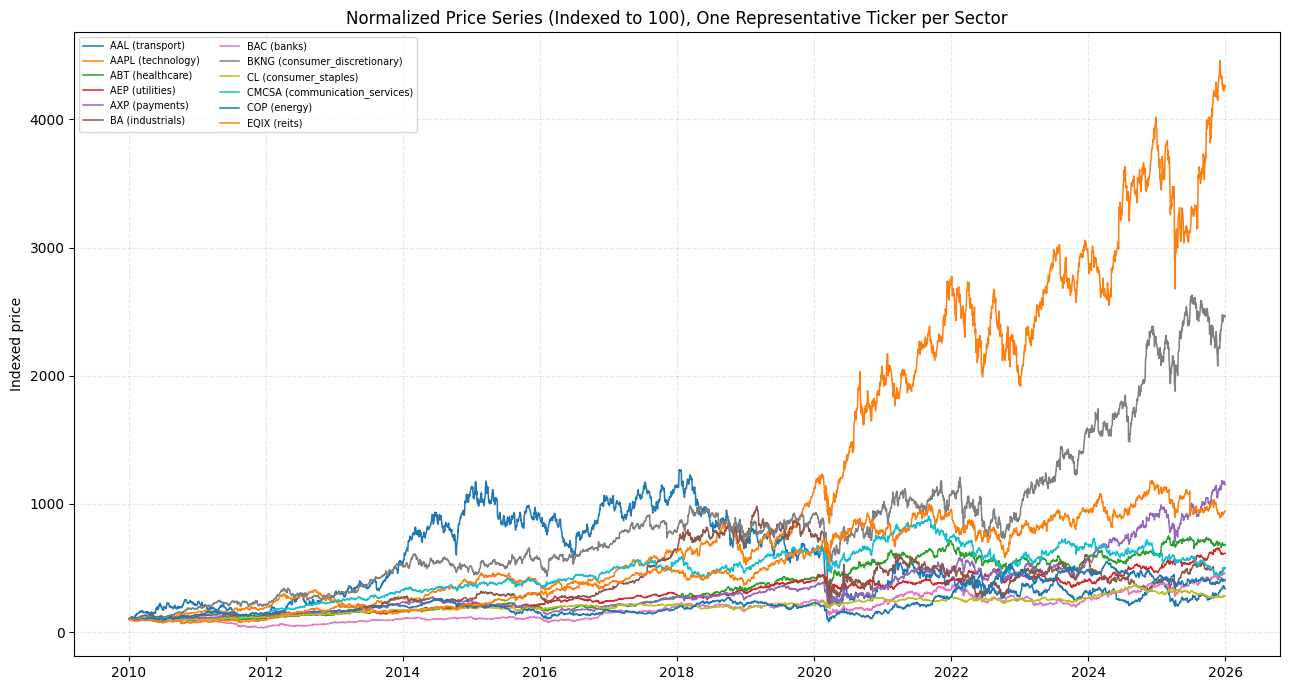

In [11]:
# --- Normalized price behavior, one representative ticker per sector ---
rep_tickers = {}
for t in wide.columns:
    sec = EXTENDED_SECTOR_MAP.get(t)
    if sec and sec not in rep_tickers:
        rep_tickers[sec] = t

fig, ax = plt.subplots(figsize=(13, 7))
for sec, t in rep_tickers.items():
    series = wide[t].dropna()
    normalized = 100 * series / series.iloc[0]
    ax.plot(normalized.index, normalized.values, label=f"{t} ({sec})", linewidth=1.1)
ax.set_title("Normalized Price Series (Indexed to 100), One Representative Ticker per Sector")
ax.set_ylabel("Indexed price")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_normalized_prices_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

DAILY RETURN DISTRIBUTION (pooled across all tickers)
count    394156.000000
mean          0.000641
std           0.017875
min          -0.520138
25%          -0.007297
50%           0.000671
75%           0.008686
max           0.422235
dtype: float64
Skew: 0.115, Kurtosis: 22.636


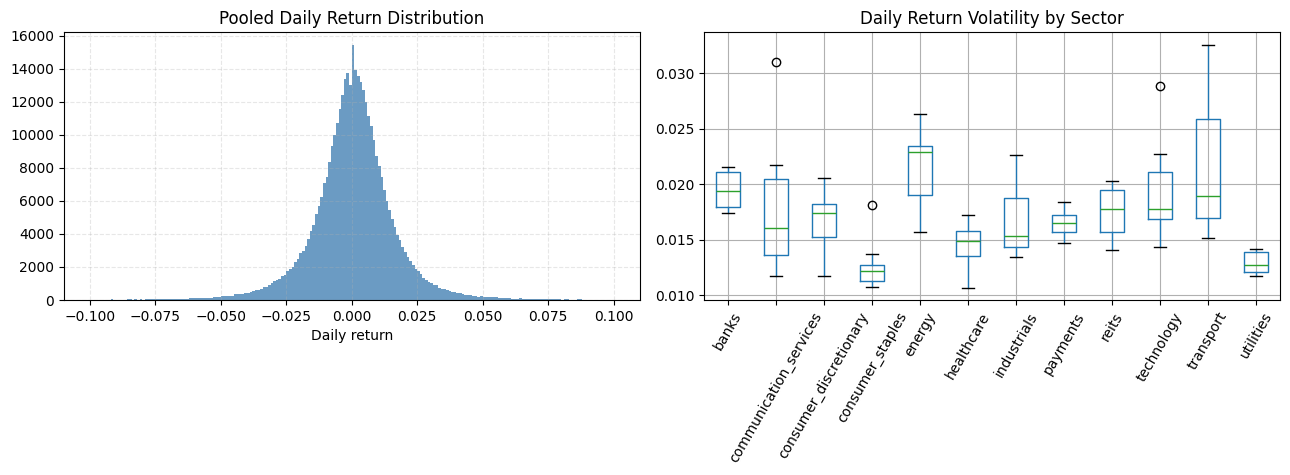

In [12]:
# --- Daily return distribution across the full universe ---
daily_returns_all = wide.pct_change().dropna(how="all")
flat_returns = daily_returns_all.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

print("DAILY RETURN DISTRIBUTION (pooled across all tickers)")
print(pd.Series(flat_returns).describe())
print(f"Skew: {pd.Series(flat_returns).skew():.3f}, Kurtosis: {pd.Series(flat_returns).kurtosis():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(flat_returns, bins=200, range=(-0.10, 0.10), color="steelblue", alpha=0.8)
axes[0].set_title("Pooled Daily Return Distribution")
axes[0].set_xlabel("Daily return")
axes[0].grid(True, linestyle="--", alpha=0.3)

vol_by_sector = daily_returns_all.std().to_frame("daily_vol")
vol_by_sector["sector"] = [EXTENDED_SECTOR_MAP.get(t) for t in vol_by_sector.index]
vol_by_sector = vol_by_sector.dropna()
vol_by_sector.boxplot(column="daily_vol", by="sector", ax=axes[1], rot=60)
axes[1].set_title("Daily Return Volatility by Sector")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

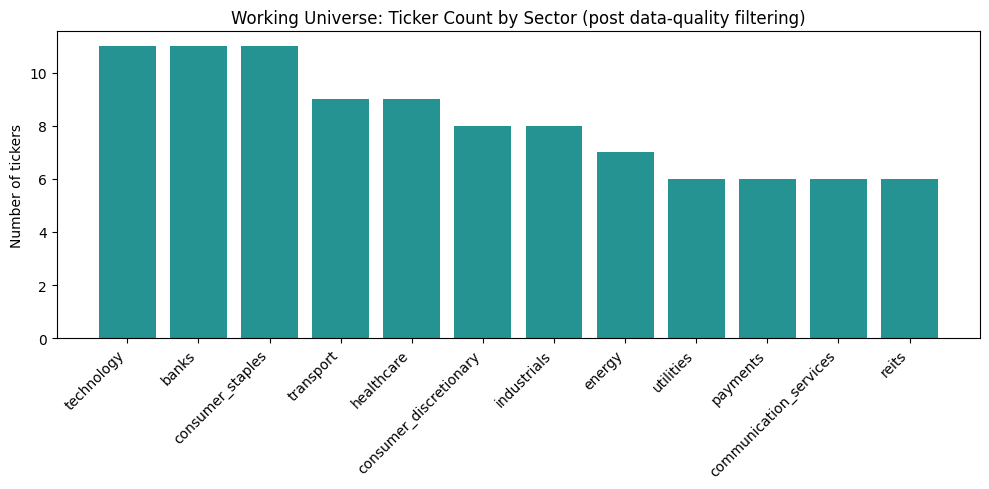

In [13]:
# --- Realized sector composition of the working universe ---
sector_counts_eda = Counter(EXTENDED_SECTOR_MAP[t] for t in wide.columns if t in EXTENDED_SECTOR_MAP)
sector_counts_df = pd.DataFrame({"sector": list(sector_counts_eda.keys()), "n_tickers": list(sector_counts_eda.values())}) \
    .sort_values("n_tickers", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sector_counts_df["sector"], sector_counts_df["n_tickers"], color="teal", alpha=0.85)
ax.set_title("Working Universe: Ticker Count by Sector (post data-quality filtering)")
ax.set_ylabel("Number of tickers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_sector_composition.png", dpi=150, bbox_inches="tight")
plt.show()

sector_counts_df.to_csv("eda_sector_composition.csv", index=False)

###Cointegration screening test

In [14]:
import itertools
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import coint

def screen_pairs_rolling(price_wide, sector_map, window_years=2, step_months=6, p_threshold=0.05, min_obs=100):
    prices = price_wide.copy()
    dates = prices.index
    window_days = int(window_years * 252)
    step_days = step_months * 21
    sectors = {}
    for t, s in sector_map.items():
        if t in prices.columns:
            sectors.setdefault(s, []).append(t)
    all_pairs = []
    for sector, tickers in sectors.items():
        for a, b in itertools.combinations(sorted(tickers), 2):
            all_pairs.append((sector, a, b))
    print(f"Testing {len(all_pairs)} pairs")
    results = []
    window_starts = list(range(0, len(dates) - window_days, step_days))
    for sector, a, b in all_pairs:
        p1, p2 = prices[a], prices[b]
        pair_results = []
        for start_idx in window_starts:
            end_idx = start_idx + window_days
            if end_idx >= len(dates):
                break
            window_p1 = p1.iloc[start_idx:end_idx].dropna()
            window_p2 = p2.iloc[start_idx:end_idx].dropna()
            common = window_p1.index.intersection(window_p2.index)
            if len(common) < min_obs:
                continue
            log_p1, log_p2 = np.log(window_p1.loc[common]), np.log(window_p2.loc[common])
            try:
                score, p_value, crit = coint(log_p1, log_p2)
                if p_value < p_threshold:
                    pair_results.append(1)
                else:
                    pair_results.append(0)
            except:
                continue
        if pair_results:
            results.append({
                "sector": sector,
                "asset_1": a,
                "asset_2": b,
                "n_windows": len(pair_results),
                "pct_cointegrated": 100 * sum(pair_results) / len(pair_results),
            })
    return pd.DataFrame(results).sort_values("pct_cointegrated", ascending=False)

def screen_pairs_full_sample(price_wide, sector_map, p_threshold=0.10, min_obs=500):
    prices = price_wide.copy()
    sectors = {}
    for t, s in sector_map.items():
        if t in prices.columns:
            sectors.setdefault(s, []).append(t)
    all_pairs = []
    for sector, tickers in sectors.items():
        for a, b in itertools.combinations(sorted(tickers), 2):
            all_pairs.append((sector, a, b))
    print(f"Testing {len(all_pairs)} pairs (full sample)")
    results = []
    for sector, a, b in all_pairs:
        p1, p2 = prices[a].dropna(), prices[b].dropna()
        common = p1.index.intersection(p2.index)
        if len(common) < min_obs:
            continue
        log_p1, log_p2 = np.log(p1.loc[common]), np.log(p2.loc[common])
        try:
            score, p_value, crit = coint(log_p1, log_p2)
            model = LinearRegression().fit(log_p2.values.reshape(-1,1), log_p1.values)
            hedge = model.coef_[0]
            results.append({"sector":sector,"asset_1":a,"asset_2":b,"p_value":p_value,"hedge_ratio":hedge,"is_cointegrated":p_value < p_threshold,"n_obs":len(common)})
        except:
            continue
    return pd.DataFrame(results).sort_values("p_value")

# Run both methods
pair_summary_rolling = screen_pairs_rolling(wide, EXTENDED_SECTOR_MAP, window_years=2, step_months=6, p_threshold=0.05)
pair_summary_full = screen_pairs_full_sample(wide, EXTENDED_SECTOR_MAP, p_threshold=0.10, min_obs=500)

print(f"Rolling: {len(pair_summary_rolling)} pairs, {len(pair_summary_rolling[pair_summary_rolling['pct_cointegrated'] >= 30])} >=30%")
print(f"Full-sample: {len(pair_summary_full)} pairs, {len(pair_summary_full[pair_summary_full['is_cointegrated']])} cointegrated")

# Create shortlist from rolling results
shortlist = pair_summary_rolling[pair_summary_rolling['pct_cointegrated'] >= 30].head(11).copy()
shortlist['latest_hedge_ratio'] = 1.0

print(f"Shortlist: {len(shortlist)} pairs")
print(shortlist[['asset_1', 'asset_2', 'sector', 'pct_cointegrated']])

Testing 374 pairs
Testing 374 pairs (full sample)
Rolling: 374 pairs, 4 >=30%
Full-sample: 374 pairs, 46 cointegrated
Shortlist: 4 pairs
    asset_1 asset_2      sector  pct_cointegrated
170     ICE       V    payments         35.714286
172      MA       V    payments         35.714286
301     JNJ     LLY  healthcare         32.142857
160     AXP     ICE    payments         32.142857


## Pair Selection


In [15]:
# Full ranked cointegration table
print("TOP 20 PAIRS BY ROLLING COINTEGRATION BREADTH")
print(pair_summary_rolling.head(20)[["asset_1","asset_2","sector","pct_cointegrated","n_windows"]].to_string(index=False))

print("\nSENSITIVITY OF SHORTLIST SIZE TO THRESHOLD")
for thresh in [15, 20, 25, 30, 35, 40]:
    n = (pair_summary_rolling["pct_cointegrated"] >= thresh).sum()
    print(f"  >= {thresh:>2}% threshold: {n} pairs qualify")

pair_summary_rolling.to_csv("full_ranked_cointegration_table.csv", index=False)

TOP 20 PAIRS BY ROLLING COINTEGRATION BREADTH
asset_1 asset_2                 sector  pct_cointegrated  n_windows
    ICE       V               payments         35.714286         28
     MA       V               payments         35.714286         28
    JNJ     LLY             healthcare         32.142857         28
    AXP     ICE               payments         32.142857         28
      C      GS                  banks         25.000000         28
   AMGN     PFE             healthcare         25.000000         28
     KO      MO       consumer_staples         25.000000         28
    COF     PNC                  banks         21.428571         28
      O     VTR                  reits         21.428571         28
    BAC     PNC                  banks         21.428571         28
    COF     WFC                  banks         21.428571         28
     BA     HON            industrials         21.428571         28
   BKNG    SBUX consumer_discretionary         21.428571         28
  

###Feature engineering

In [16]:
%%writefile feature_engineering.py
from __future__ import annotations
import logging
from typing import Optional
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

FEATURE_COLUMNS = [
    "z_score", "spread_roll_mean", "spread_roll_std", "spread_vol_20d",
    "dist_from_equilibrium", "spread_mom_5d", "spread_mom_20d",
    "mom_10d_diff", "mom_20d_diff", "rsi_diff", "ma20_ratio_diff",
    "ma50_ratio_diff", "bollinger_pctb_diff", "realized_vol_20d_diff",
    "ret_1d_diff", "ret_5d_diff",
    "mkt_rf", "smb", "hml", "rmw", "cma", "rf",
    "rolling_beta_to_mkt", "spread_drawdown", "high_vol_regime",
]
LABEL_COLUMNS = ["fwd_spread_return", "signal_label"]

def build_spread(price_wide, a, b, hedge_ratio=None, rolling_beta_window=None):
    if hedge_ratio is None and rolling_beta_window is None:
        raise ValueError("Provide hedge_ratio or rolling_beta_window")
    df = pd.DataFrame({"log_p1": np.log(price_wide[a]), "log_p2": np.log(price_wide[b])}).dropna()
    if rolling_beta_window is not None:
        cov = df["log_p1"].rolling(rolling_beta_window).cov(df["log_p2"])
        var = df["log_p2"].rolling(rolling_beta_window).var()
        df["beta"] = cov / var
    else:
        df["beta"] = hedge_ratio
    df["spread"] = df["log_p1"] - df["beta"] * df["log_p2"]
    return df.dropna()

def spread_features(spread_df, z_window=60):
    out = spread_df.copy()
    out["spread_roll_mean"] = out["spread"].rolling(z_window).mean()
    out["spread_roll_std"] = out["spread"].rolling(z_window).std()
    out["z_score"] = (out["spread"] - out["spread_roll_mean"]) / out["spread_roll_std"]
    out["spread_vol_20d"] = out["spread"].diff().rolling(20).std()
    out["dist_from_equilibrium"] = out["z_score"].abs()
    out["spread_mom_5d"] = out["spread"].diff(5)
    out["spread_mom_20d"] = out["spread"].diff(20)
    return out

def _rsi(s, w=14):
    delta = s.diff()
    gain = delta.clip(lower=0).rolling(w).mean()
    loss = (-delta.clip(upper=0)).rolling(w).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def _bollinger_pctb(s, w=20, n_std=2.0):
    mean = s.rolling(w).mean()
    std = s.rolling(w).std()
    return (s - (mean - n_std*std)) / (2*n_std*std)

def technical_features(price_wide, a, b):
    p1, p2 = price_wide[a].dropna(), price_wide[b].dropna()
    idx = p1.index.intersection(p2.index)
    p1, p2 = p1.loc[idx], p2.loc[idx]
    r1, r2 = p1.pct_change(), p2.pct_change()
    feats = pd.DataFrame(index=idx)
    feats["mom_10d_diff"] = p1.pct_change(10) - p2.pct_change(10)
    feats["mom_20d_diff"] = p1.pct_change(20) - p2.pct_change(20)
    feats["rsi_diff"] = _rsi(p1) - _rsi(p2)
    feats["ma20_ratio_diff"] = (p1/p1.rolling(20).mean()) - (p2/p2.rolling(20).mean())
    feats["ma50_ratio_diff"] = (p1/p1.rolling(50).mean()) - (p2/p2.rolling(50).mean())
    feats["bollinger_pctb_diff"] = _bollinger_pctb(p1) - _bollinger_pctb(p2)
    feats["realized_vol_20d_diff"] = r1.rolling(20).std() - r2.rolling(20).std()
    feats["ret_1d_diff"] = r1 - r2
    feats["ret_5d_diff"] = r1.rolling(5).sum() - r2.rolling(5).sum()
    return feats

def market_and_risk_features(price_wide, a, b, ff5, beta_window=60, dd_window=60):
    p1, p2 = np.log(price_wide[a]).dropna(), np.log(price_wide[b]).dropna()
    idx = p1.index.intersection(p2.index).intersection(ff5.index)
    ff = ff5.loc[idx].sort_index()
    spread = (p1 - p2).loc[idx].sort_index()
    spread_ret = spread.diff()
    feats = ff[["mkt_rf","smb","hml","rmw","cma","rf"]].copy()
    feats["rolling_beta_to_mkt"] = spread_ret.rolling(beta_window).cov(feats["mkt_rf"]) / feats["mkt_rf"].rolling(beta_window).var()
    cum = (1 + spread_ret.fillna(0)).cumprod()
    rolling_max = cum.rolling(dd_window, min_periods=1).max()
    feats["spread_drawdown"] = cum / rolling_max - 1
    vol_20d = feats["mkt_rf"].rolling(20).std()
    vol_median = vol_20d.expanding(min_periods=252).median()
    feats["high_vol_regime"] = (vol_20d > vol_median).astype(float)
    return feats

def build_labels(spread_df, horizon=5, z_entry=2.0):
    out = spread_df.copy()
    out["fwd_spread_return"] = out["spread"].shift(-horizon) - out["spread"]
    out["signal_label"] = 0
    out.loc[(out["z_score"] < -z_entry) & (out["fwd_spread_return"] > 0), "signal_label"] = 1
    out.loc[(out["z_score"] > z_entry) & (out["fwd_spread_return"] < 0), "signal_label"] = -1
    return out

def build_pair_features(price_wide, ff5, a, b, hedge_ratio, z_window=60, label_horizon=5, z_entry=2.0):
    log.info(f"Building features for {a}-{b}")
    spread_df = build_spread(price_wide, a, b, hedge_ratio=hedge_ratio)
    spread_df = spread_features(spread_df, z_window=z_window)
    spread_df = build_labels(spread_df, horizon=label_horizon, z_entry=z_entry)
    tech = technical_features(price_wide, a, b)
    mkt = market_and_risk_features(price_wide, a, b, ff5)
    full = spread_df.join(tech, how="inner").join(mkt, how="inner")
    full = full.dropna(subset=FEATURE_COLUMNS + LABEL_COLUMNS)
    return full

Writing feature_engineering.py


###Estimation of Hedge ratios & Building features

In [17]:
# Check ff5 columns first
print("FF5 columns:", ff5.columns.tolist())
print("FF5 shape:", ff5.shape)
print("FF5 head:", ff5.head())

FF5 columns: ['date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
FF5 shape: (15854, 7)
FF5 head:         date  Mkt-RF     SMB     HML     RMW     CMA      RF
0 1963-07-01 -0.0067  0.0000 -0.0034 -0.0001  0.0016  0.0001
1 1963-07-02  0.0079 -0.0026  0.0026 -0.0007 -0.0020  0.0001
2 1963-07-03  0.0063 -0.0017 -0.0009  0.0018 -0.0034  0.0001
3 1963-07-05  0.0040  0.0008 -0.0027  0.0009 -0.0034  0.0001
4 1963-07-08 -0.0063  0.0004 -0.0018 -0.0029  0.0014  0.0001


In [23]:
# ============================================================
# CELL: BUILD FEATURES FOR SHORTLISTED PAIRS
# ============================================================
# This cell creates the all_feat_dfs dictionary by building features
# for each shortlisted pair. Run this FIRST before trying to save.

# ============================================================
# 1. Import Required Modules
# ============================================================
from feature_engineering import build_pair_features, FEATURE_COLUMNS, LABEL_COLUMNS
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import os

# ============================================================
# 2. Prepare FF5 Data with Correct Column Names
# ============================================================
# Fix the column naming issue that was causing errors

# Make a copy to avoid modifying the original
ff5_clean = ff5.copy()

# Check if 'date' is a column or index
if 'date' in ff5_clean.columns:
    ff5_clean = ff5_clean.set_index('date')

# Ensure index is datetime
ff5_clean.index = pd.to_datetime(ff5_clean.index)

# Rename columns to lowercase to match feature_engineering expectations
column_mapping = {
    'Mkt-RF': 'mkt_rf',
    'SMB': 'smb',
    'HML': 'hml',
    'RMW': 'rmw',
    'CMA': 'cma',
    'RF': 'rf'
}
ff5_clean = ff5_clean.rename(columns=column_mapping)

# Ensure wide panel index is date-only
wide.index = pd.to_datetime(wide.index.date)
ff5_clean.index = pd.to_datetime(ff5_clean.index.date)

print("FF5 columns after rename:", ff5_clean.columns.tolist())
print("FF5 shape:", ff5_clean.shape)

# ============================================================
# 3. Estimate Hedge Ratios (if not already in shortlist)
# ============================================================
# The hedge ratio is the beta coefficient from regressing log(P1) on log(P2)
for idx, row in shortlist.iterrows():
    if 'latest_hedge_ratio' not in row or pd.isna(row.latest_hedge_ratio):
        p1 = wide[row.asset_1].dropna()
        p2 = wide[row.asset_2].dropna()
        common = p1.index.intersection(p2.index)

        if len(common) > 100:
            model = LinearRegression().fit(
                np.log(p2.loc[common]).values.reshape(-1, 1),
                np.log(p1.loc[common]).values
            )
            shortlist.loc[idx, 'latest_hedge_ratio'] = model.coef_[0]
            print(f"Estimated hedge ratio for {row.asset_1}-{row.asset_2}: {model.coef_[0]:.4f}")

# ============================================================
# 4. Build Features for Each Pair
# ============================================================
# This creates the all_feat_dfs dictionary
all_feat_dfs = {}

# Loop through each pair in the shortlist
for i, row in shortlist.iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    try:
        feat_df = build_pair_features(
            wide, ff5_clean,
            row.asset_1, row.asset_2,
            row.latest_hedge_ratio
        )

        if not feat_df.empty:
            all_feat_dfs[pair_name] = feat_df
            print(f"{pair_name}: {len(feat_df)} rows")
    except Exception as e:
        print(f"{pair_name}: ERROR - {e}")

print(f"\nBuilt features for {len(all_feat_dfs)} pairs")

# ============================================================
# 5. Verify all_feat_dfs was created
# ============================================================
if all_feat_dfs:
    print(f"\n✓ all_feat_dfs created with {len(all_feat_dfs)} pairs")
    print(f"  Keys: {list(all_feat_dfs.keys())}")
else:
    print("\n✗ No features were built. Check the error messages above.")
    print("  Common issues:")
    print("  1. FF5 column names not matching expectations")
    print("  2. Insufficient overlapping data between prices and FF5")
    print("  3. Missing hedge ratios in shortlist")

FF5 columns after rename: ['mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'rf']
FF5 shape: (15854, 6)
ICE-V: 3958 rows
MA-V: 3957 rows
JNJ-LLY: 3958 rows
AXP-ICE: 3958 rows

Built features for 4 pairs

✓ all_feat_dfs created with 4 pairs
  Keys: ['ICE-V', 'MA-V', 'JNJ-LLY', 'AXP-ICE']


In [24]:
# Save all feature DataFrames to disk
import os
os.makedirs("pair_features", exist_ok=True)

for pair_name, feat_df in all_feat_dfs.items():
    feat_df.to_csv(f"pair_features/{pair_name}_features.csv")
    print(f"Saved {pair_name}: {len(feat_df)} rows, {len(feat_df.columns)} columns")

# Also save a combined dataset with pair identifier
combined_features = []
for pair_name, feat_df in all_feat_dfs.items():
    df = feat_df.copy()
    df['pair'] = pair_name
    df['asset_1'] = pair_name.split('-')[0]
    df['asset_2'] = pair_name.split('-')[1]
    combined_features.append(df)

combined_df = pd.concat(combined_features)
combined_df.to_csv("pair_features/combined_features.csv")
print(f"\nCombined features: {len(combined_df)} rows")

# Show summary
print("\nFEATURE SUMMARY:")
for pair_name, feat_df in all_feat_dfs.items():
    print(f"\n{pair_name}:")
    print(f"  Rows: {len(feat_df)}")
    print(f"  Columns: {len(feat_df.columns)}")
    print(f"  Date range: {feat_df.index[0]} to {feat_df.index[-1]}")
    print(f"  Signal distribution:")
    print(f"    Long signals: {(feat_df['signal_label'] == 1).sum()}")
    print(f"    Short signals: {(feat_df['signal_label'] == -1).sum()}")
    print(f"    No signal: {(feat_df['signal_label'] == 0).sum()}")

Saved ICE-V: 3958 rows, 31 columns
Saved MA-V: 3957 rows, 31 columns
Saved JNJ-LLY: 3958 rows, 31 columns
Saved AXP-ICE: 3958 rows, 31 columns

Combined features: 15831 rows

FEATURE SUMMARY:

ICE-V:
  Rows: 3958
  Columns: 31
  Date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  Signal distribution:
    Long signals: 141
    Short signals: 131
    No signal: 3686

MA-V:
  Rows: 3957
  Columns: 31
  Date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  Signal distribution:
    Long signals: 133
    Short signals: 170
    No signal: 3654

JNJ-LLY:
  Rows: 3958
  Columns: 31
  Date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  Signal distribution:
    Long signals: 191
    Short signals: 98
    No signal: 3669

AXP-ICE:
  Rows: 3958
  Columns: 31
  Date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  Signal distribution:
    Long signals: 142
    Short signals: 137
    No signal: 3679


In [25]:
# Check feature columns
print("FEATURE COLUMNS:")
print(FEATURE_COLUMNS)
print(f"\nTotal features: {len(FEATURE_COLUMNS)}")

# Verify all features exist in each pair's DataFrame
for pair_name, feat_df in all_feat_dfs.items():
    missing = [col for col in FEATURE_COLUMNS if col not in feat_df.columns]
    if missing:
        print(f"\n{pair_name} missing: {missing}")
    else:
        print(f"\n{pair_name}: All {len(FEATURE_COLUMNS)} features present")

# Show sample data
sample_pair = list(all_feat_dfs.keys())[0]
print(f"\nSAMPLE DATA from {sample_pair}:")
print(all_feat_dfs[sample_pair][FEATURE_COLUMNS[:5] + ['signal_label']].head())

# Check for any NaN values
for pair_name, feat_df in all_feat_dfs.items():
    nan_count = feat_df[FEATURE_COLUMNS].isna().sum().sum()
    print(f"\n{pair_name} NaN count in features: {nan_count}")

FEATURE COLUMNS:
['z_score', 'spread_roll_mean', 'spread_roll_std', 'spread_vol_20d', 'dist_from_equilibrium', 'spread_mom_5d', 'spread_mom_20d', 'mom_10d_diff', 'mom_20d_diff', 'rsi_diff', 'ma20_ratio_diff', 'ma50_ratio_diff', 'bollinger_pctb_diff', 'realized_vol_20d_diff', 'ret_1d_diff', 'ret_5d_diff', 'mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'rf', 'rolling_beta_to_mkt', 'spread_drawdown', 'high_vol_regime']

Total features: 25

ICE-V: All 25 features present

MA-V: All 25 features present

JNJ-LLY: All 25 features present

AXP-ICE: All 25 features present

SAMPLE DATA from ICE-V:
             z_score  spread_roll_mean  spread_roll_std  spread_vol_20d  \
2010-03-31  0.705994         -0.075138         0.025313        0.013248   
2010-04-01  0.247104         -0.075557         0.024999        0.013172   
2010-04-05 -0.521700         -0.076007         0.024995        0.013591   
2010-04-06 -1.647004         -0.077248         0.025245        0.014630   
2010-04-07 -1.210275         -0.078327

###Feature with VIF Analysis

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Combine all feature data while preserving the index
all_feat = pd.concat(all_feat_dfs.values())
all_feat = all_feat[FEATURE_COLUMNS]  # Keep only feature columns

# FEATURE SUMMARY TABLE
print("\n" + "="*60)
print("FEATURE SUMMARY STATISTICS")
print("="*60)
print(all_feat[FEATURE_COLUMNS].describe().round(4))

# VIF ANALYSIS (MULTICOLLINEARITY CHECK)
print("\n" + "="*60)
print("VIF ANALYSIS (Variance Inflation Factor)")
print("="*60)

# Drop rows with NaN and standardize
X_vif = all_feat[FEATURE_COLUMNS].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

vif_data = []
for i, col in enumerate(FEATURE_COLUMNS):
    vif = variance_inflation_factor(X_scaled, i)
    vif_data.append({'Feature': col, 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Show VIF results with interpretation
print(vif_df.to_string(index=False))

# Flag high multicollinearity (VIF > 5)
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\nWARNING: {len(high_vif)} features have VIF > 5 (high multicollinearity):")
    print(high_vif.to_string(index=False))
else:
    print("\nAll features have VIF < 5 (acceptable multicollinearity).")

# Export VIF table
vif_df.to_csv('vif_analysis.csv', index=False)
print("\nVIF table exported to 'vif_analysis.csv'")


FEATURE SUMMARY STATISTICS
          z_score  spread_roll_mean  spread_roll_std  spread_vol_20d  \
count  15831.0000        15831.0000       15831.0000      15831.0000   
mean      -0.0813            0.0505           0.0355          0.0130   
std        1.3526            0.5511           0.0208          0.0067   
min       -4.5713           -1.7972           0.0064          0.0025   
25%       -1.1170           -0.3960           0.0205          0.0084   
50%       -0.1139            0.2771           0.0302          0.0116   
75%        0.9384            0.4430           0.0448          0.0158   
max        5.5896            0.8637           0.1494          0.0557   

       dist_from_equilibrium  spread_mom_5d  spread_mom_20d  mom_10d_diff  \
count             15831.0000     15831.0000      15831.0000    15831.0000   
mean                  1.1230        -0.0007         -0.0027       -0.0014   
std                   0.7581         0.0316          0.0589        0.0437   
min            

###Correlation analysis

Original rows: 15831
Clean rows: 15831
Features: 25

Correlation matrix range: [-0.5942, 1.0000]

CORRELATION WITH SIGNAL LABEL (Top 10)
high_vol_regime          0.0398
dist_from_equilibrium    0.0223
spread_roll_std          0.0115
realized_vol_20d_diff    0.0057
rolling_beta_to_mkt      0.0038
spread_roll_mean         0.0029
rmw                     -0.0003
cma                     -0.0024
spread_vol_20d          -0.0072
mkt_rf                  -0.0121
Name: signal_label, dtype: float64

GENERATING HEATMAP


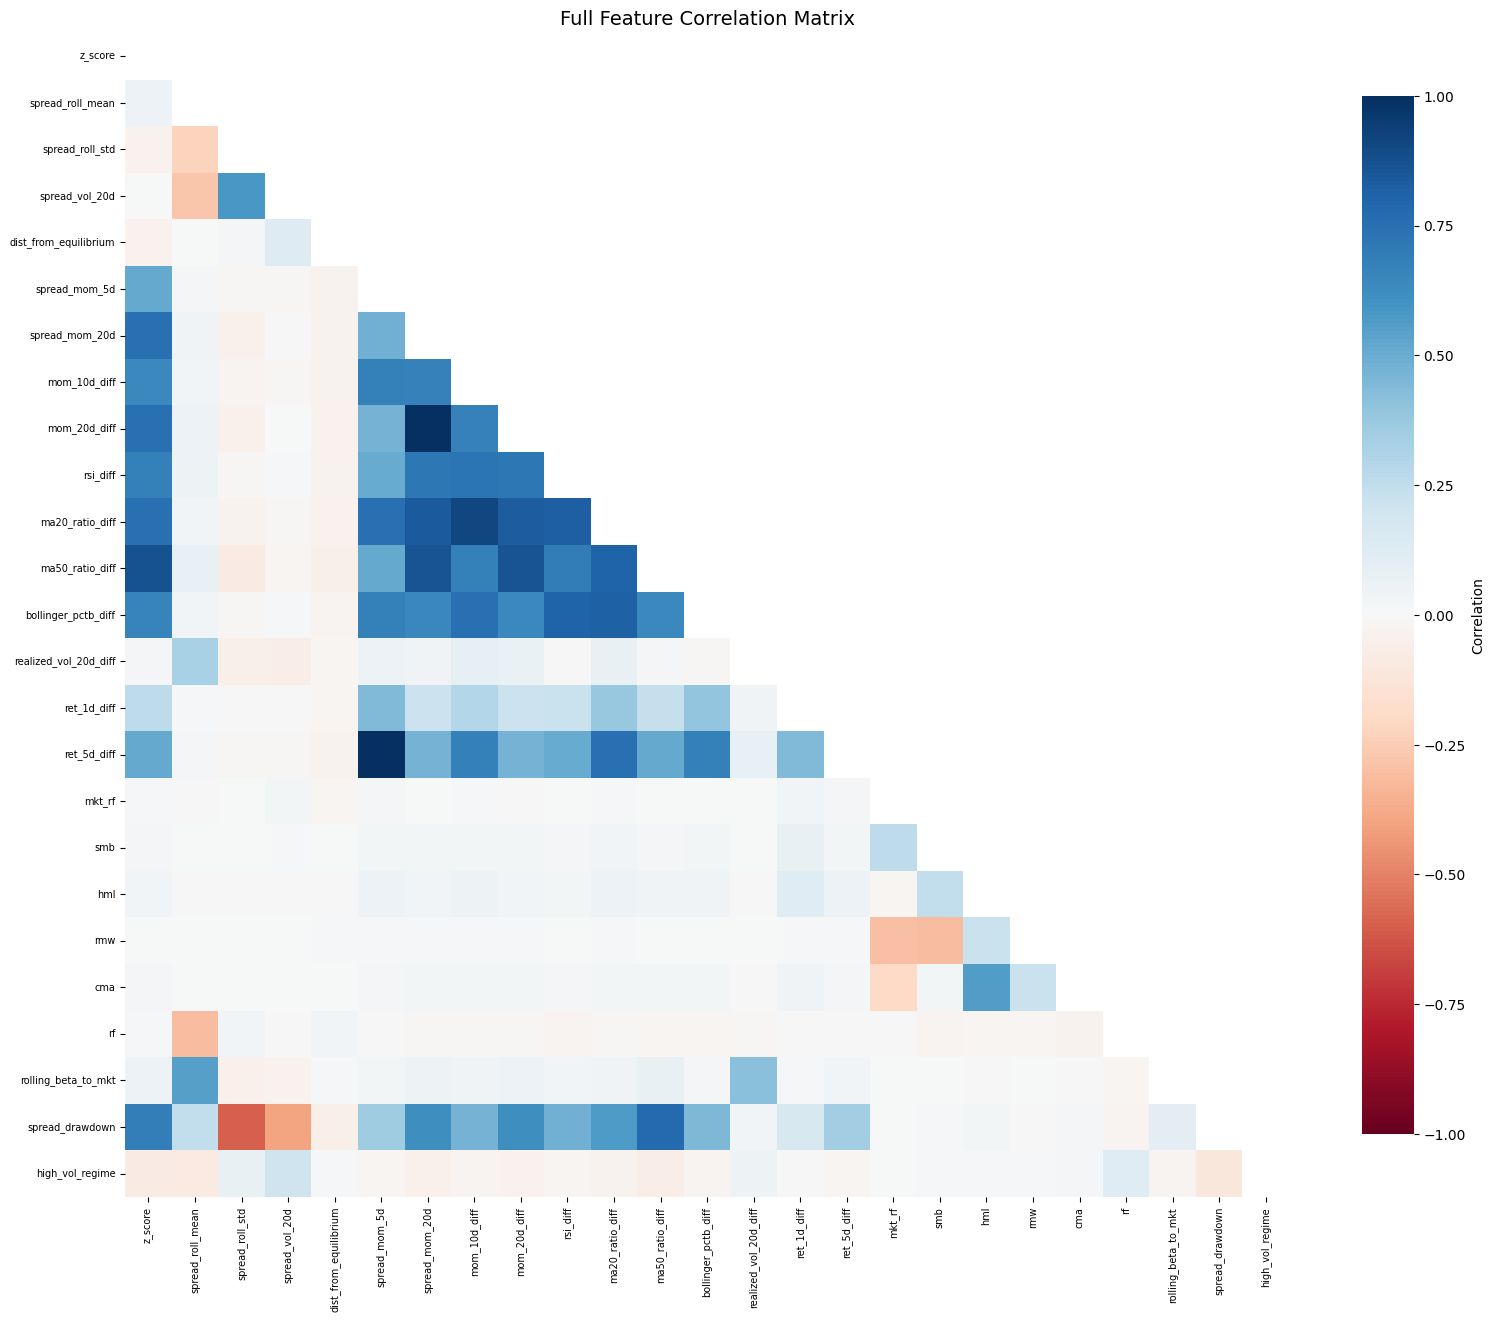


Heatmap saved to 'correlation_heatmap_fixed.png'

GENERATING SMALL HEATMAP (Top 15 Features + Signal)


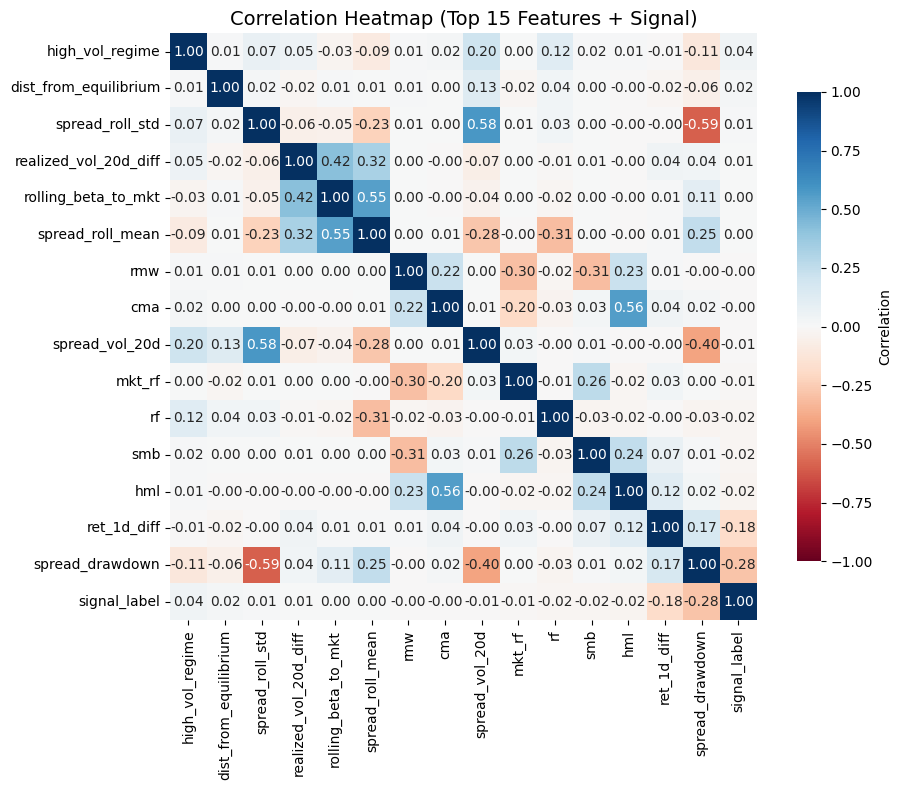


Small heatmap saved to 'correlation_heatmap_small_fixed.png'

Feature-signal correlations exported to 'feature_correlation_with_signal.csv'


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Combine features while preserving index
all_feat = pd.concat(all_feat_dfs.values())

all_feat_clean = all_feat[FEATURE_COLUMNS + ['signal_label']].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Original rows: {len(all_feat)}")
print(f"Clean rows: {len(all_feat_clean)}")
print(f"Features: {len(FEATURE_COLUMNS)}")

corr_matrix = all_feat_clean[FEATURE_COLUMNS].corr()

max_val = corr_matrix.max().max()
min_val = corr_matrix.min().min()
print(f"\nCorrelation matrix range: [{min_val:.4f}, {max_val:.4f}]")

if max_val > 1.0 or min_val < -1.0:
    corr_matrix = corr_matrix.clip(-1, 1)

print("\n" + "="*60)
print("CORRELATION WITH SIGNAL LABEL (Top 10)")
print("="*60)
corr_with_signal = all_feat_clean[FEATURE_COLUMNS + ['signal_label']].corr()['signal_label']
corr_with_signal = corr_with_signal.drop('signal_label').sort_values(ascending=False)
print(corr_with_signal.head(10).round(4))

print("\n" + "="*60)
print("GENERATING HEATMAP")
print("="*60)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu', center=0,
            annot=False, ax=ax,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            square=True, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix', fontsize=14)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('correlation_heatmap_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHeatmap saved to 'correlation_heatmap_fixed.png'")

print("\n" + "="*60)
print("GENERATING SMALL HEATMAP (Top 15 Features + Signal)")
print("="*60)

top_features = corr_with_signal.head(15).index.tolist()
corr_small = all_feat_clean[top_features + ['signal_label']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_small, cmap='RdBu', center=0, annot=True, fmt='.2f',
            ax=ax, cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            square=True, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Top 15 Features + Signal)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap_small_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSmall heatmap saved to 'correlation_heatmap_small_fixed.png'")

corr_with_signal.to_csv('feature_correlation_with_signal.csv')
print("\nFeature-signal correlations exported to 'feature_correlation_with_signal.csv'")

###The machine learning models

In [28]:
# ============================================================
# CELL: ML MODELS MODULE
# ============================================================
# This module defines the machine learning models used for signal prediction:
# 1. XGBoost: Gradient boosting with regularization
# 2. LightGBM: Lightweight gradient boosting (faster on CPU)
# 3. LSTM: Long Short-Term Memory neural network for sequence data
#
# The models perform 3-class classification:
# - Class 0: Short signal (-1) - spread above equilibrium, expected to revert down
# - Class 1: No signal (0) - stay out of market
# - Class 2: Long signal (1) - spread below equilibrium, expected to revert up

%%writefile ml_models.py

from __future__ import annotations
import logging
from dataclasses import dataclass
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configure logging for tracking model training progress
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# Default dates for chronological train/validation/test split
DEFAULT_TRAIN_END = "2018-12-31"  # Training data up to end of 2018
DEFAULT_VAL_END = "2021-12-31"     # Validation data 2019-2021, test data 2022 onward

# ============================================================
# DATA SPLIT DATA CLASS
# ============================================================
@dataclass
class DataSplit:
    """
    Container for train/validation/test split data.

    Attributes:
        X_train: Features for training
        y_train: Labels for training
        X_val: Features for validation (hyperparameter tuning)
        y_val: Labels for validation
        X_test: Features for testing (out-of-sample evaluation)
        y_test: Labels for testing
    """
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series

# ============================================================
# FUNCTION: chronological_split
# ============================================================
def chronological_split(feat_df, feature_cols, label_col,
                        train_end=DEFAULT_TRAIN_END, val_end=DEFAULT_VAL_END):
    """
    Split data chronologically to prevent look-ahead bias.

    This is critical for time series data to ensure the model
    is trained on past data and tested on future data.

    Split structure:
    - Training: up to train_end (2018-12-31)
    - Validation: train_end to val_end (2019-01-01 to 2021-12-31)
    - Test: after val_end (2022-01-01 onward)

    Args:
        feat_df: Feature DataFrame with datetime index
        feature_cols: List of feature column names
        label_col: Name of the label column
        train_end: End date for training data
        val_end: End date for validation data

    Returns:
        DataSplit: Container with X_train, y_train, X_val, y_val, X_test, y_test
    """
    # Ensure data is sorted chronologically
    feat_df = feat_df.sort_index()

    # Convert dates to Timestamp for comparison
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)

    # Split data chronologically
    train = feat_df.loc[:train_end_ts]                                    # Oldest data
    val = feat_df.loc[train_end_ts + pd.Timedelta(days=1):val_end_ts]    # Middle data
    test = feat_df.loc[val_end_ts + pd.Timedelta(days=1):]               # Newest data

    return DataSplit(
        X_train=train[feature_cols],
        y_train=train[label_col],
        X_val=val[feature_cols],
        y_val=val[label_col],
        X_test=test[feature_cols],
        y_test=test[label_col]
    )

# ============================================================
# FUNCTION: evaluate_classifier
# ============================================================
def evaluate_classifier(y_true, y_pred, label=""):
    """
    Evaluate classifier performance using multiple metrics.

    Metrics:
    - Accuracy: Overall correct predictions
    - F1 Macro: Harmonic mean of precision and recall (averaged across classes)
    - Precision Macro: True positives / (true positives + false positives)
    - Recall Macro: True positives / (true positives + false negatives)

    Macro averaging treats all classes equally, which is important
    when classes are imbalanced.

    Args:
        y_true: True labels
        y_pred: Predicted labels
        label: Model name/label for identification

    Returns:
        dict: Dictionary of evaluation metrics
    """
    return {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0)
    }

# ============================================================
# FUNCTION: train_xgboost
# ============================================================
def train_xgboost(split, **kwargs):
    """
    Train XGBoost classifier for signal prediction.

    XGBoost advantages:
    - Handles missing values natively
    - Built-in regularization to prevent overfitting
    - Fast training with histogram-based tree building
    - Feature importance for interpretability

    Key Parameters:
    - n_estimators: Number of boosting rounds
    - max_depth: Maximum tree depth (controls complexity)
    - learning_rate: Step size shrinkage (prevents overfitting)
    - subsample: Fraction of samples used per tree (random forest-like)
    - colsample_bytree: Fraction of features used per tree

    Args:
        split: DataSplit object containing train/val/test data
        **kwargs: Additional parameters to override defaults

    Returns:
        tuple: (trained_model, evaluation_metrics)
    """
    import xgboost as xgb

    # Map labels: -1 -> 0 (short), 0 -> 1 (neutral), 1 -> 2 (long)
    # XGBoost requires 0-indexed classes for multi-class classification
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}

    # Map labels for training and validation
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)

    # Default parameters optimized for this problem
    params = dict(
        n_estimators=500,           # Number of trees
        max_depth=4,                # Tree depth (shallow to prevent overfitting)
        learning_rate=0.03,         # Small learning rate for gradual learning
        subsample=0.8,              # Sample 80% of data per tree
        colsample_bytree=0.8,       # Use 80% of features per tree
        objective="multi:softprob", # Multi-class classification with probability output
        num_class=3,                # Three classes: short, neutral, long
        eval_metric="mlogloss",     # Multi-class log loss
        early_stopping_rounds=30,   # Stop if no improvement for 30 rounds
        random_state=42             # Reproducibility
    )
    params.update(kwargs)  # Allow parameter overrides

    # Initialize and train model
    model = xgb.XGBClassifier(**params)
    model.fit(
        split.X_train, y_train,
        eval_set=[(split.X_val, y_val)],
        verbose=False  # Suppress training output
    )

    # Predict on test set and convert back to original labels
    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)

    return model, evaluate_classifier(split.y_test, y_pred.values, label="XGBoost")

# ============================================================
# FUNCTION: train_lightgbm
# ============================================================
def train_lightgbm(split, **kwargs):
    """
    Train LightGBM classifier for signal prediction.

    LightGBM advantages over XGBoost:
    - Faster training (especially on CPU)
    - Lower memory usage
    - Leaf-wise tree growth (can be more accurate)
    - Native support for categorical features

    Key Parameters:
    - n_estimators: Number of boosting rounds
    - max_depth: Maximum tree depth
    - learning_rate: Step size shrinkage
    - subsample: Fraction of samples used per tree
    - colsample_bytree: Fraction of features used per tree

    Args:
        split: DataSplit object containing train/val/test data
        **kwargs: Additional parameters to override defaults

    Returns:
        tuple: (trained_model, evaluation_metrics)
    """
    import lightgbm as lgb

    # Map labels: -1 -> 0 (short), 0 -> 1 (neutral), 1 -> 2 (long)
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}

    # Map labels for training and validation
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)

    # Default parameters optimized for this problem
    params = dict(
        n_estimators=500,           # Number of trees
        max_depth=4,                # Tree depth
        learning_rate=0.03,         # Learning rate
        subsample=0.8,              # Sample 80% of data per tree
        colsample_bytree=0.8,       # Use 80% of features per tree
        objective="multiclass",     # Multi-class classification
        num_class=3,                # Three classes
        random_state=42,            # Reproducibility
        verbosity=-1                # Suppress output
    )
    params.update(kwargs)  # Allow parameter overrides

    # Initialize and train model
    model = lgb.LGBMClassifier(**params)
    model.fit(
        split.X_train, y_train,
        eval_set=[(split.X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )

    # Predict on test set and convert back to original labels
    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)

    return model, evaluate_classifier(split.y_test, y_pred.values, label="LightGBM")

# ============================================================
# HELPER FUNCTION: _make_sequences
# ============================================================
def _make_sequences(X, y, lookback):
    """
    Create sequences for LSTM training.

    LSTM requires sequences of past observations to predict the next.
    This function creates sliding windows of data.

    Example:
        lookback=3, data=[1,2,3,4,5]
        Creates: [[1,2,3]->4, [2,3,4]->5]

    Args:
        X: Feature matrix (samples x features)
        y: Labels (samples,)
        lookback: Number of past observations to use for prediction

    Returns:
        tuple: (X_sequences, y_sequences)
    """
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])  # Past 'lookback' observations
        ys.append(y[i])              # Current observation as target
    return np.array(Xs), np.array(ys)

# ============================================================
# FUNCTION: train_lstm
# ============================================================
def train_lstm(split, lookback=20, units=32, dropout=0.2, epochs=50, batch_size=64, patience=8):
    """
    Train LSTM (Long Short-Term Memory) neural network for signal prediction.

    LSTM advantages:
    - Captures long-term dependencies in sequential data
    - Handles variable-length sequences
    - Can learn complex temporal patterns

    Architecture:
    - Input: (lookback, n_features) sequences
    - LSTM layer: 32 units with return_sequences=False
    - Dropout: 20% to prevent overfitting
    - Dense layer: 16 units with ReLU activation
    - Output layer: 3 units with Softmax activation (class probabilities)

    Args:
        split: DataSplit object containing train/val/test data
        lookback: Number of past observations to use (sequence length)
        units: Number of LSTM units
        dropout: Dropout rate for regularization
        epochs: Maximum number of training epochs
        batch_size: Batch size for training
        patience: Early stopping patience (stop if no improvement for X epochs)

    Returns:
        tuple: (trained_model, evaluation_metrics)
    """
    import tensorflow as tf
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras import Sequential, layers, callbacks, utils

    # Map labels: -1 -> 0, 0 -> 1, 1 -> 2
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}

    # Standardize features (important for neural networks)
    scaler = StandardScaler().fit(split.X_train)
    X_train_s = scaler.transform(split.X_train)
    X_val_s = scaler.transform(split.X_val)
    X_test_s = scaler.transform(split.X_test)

    # Prepare labels
    y_train = split.y_train.map(label_map).values
    y_val = split.y_val.map(label_map).values
    y_test = split.y_test.map(label_map).values

    # Create sequences for LSTM
    Xtr, ytr = _make_sequences(X_train_s, y_train, lookback)
    Xva, yva = _make_sequences(X_val_s, y_val, lookback)
    Xte, yte = _make_sequences(X_test_s, y_test, lookback)

    # One-hot encode labels for multi-class classification
    ytr_oh = utils.to_categorical(ytr, num_classes=3)
    yva_oh = utils.to_categorical(yva, num_classes=3)

    # Build LSTM model
    model = Sequential([
        layers.Input(shape=(lookback, Xtr.shape[-1])),  # Input: sequences
        layers.LSTM(units, return_sequences=False),     # LSTM layer
        layers.Dropout(dropout),                        # Dropout for regularization
        layers.Dense(16, activation="relu"),            # Hidden layer
        layers.Dense(3, activation="softmax"),          # Output layer (3 classes)
    ])

    # Compile with Adam optimizer and categorical crossentropy loss
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # Early stopping to prevent overfitting
    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    # Train the model
    model.fit(
        Xtr, ytr_oh,
        validation_data=(Xva, yva_oh),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0  # Silent training
    )

    # Predict on test set
    y_pred_idx = model.predict(Xte, verbose=0).argmax(axis=1)
    y_pred = pd.Series(y_pred_idx).map(inv_label_map)
    y_test_labels = pd.Series(yte).map(inv_label_map)

    return model, evaluate_classifier(y_test_labels, y_pred.values, label="LSTM")

# ============================================================
# FUNCTION: run_all_models
# ============================================================
def run_all_models(split):
    """
    Run all three models (XGBoost, LightGBM, LSTM) on the data split.

    This function simplifies model comparison by training and evaluating
    all models in one call.

    Args:
        split: DataSplit object containing train/val/test data

    Returns:
        pd.DataFrame: Results for all models with evaluation metrics
    """
    results = []

    # List of (model_name, training_function) pairs
    for name, fn in [("XGBoost", train_xgboost), ("LightGBM", train_lightgbm), ("LSTM", train_lstm)]:
        try:
            _, metrics = fn(split)
            results.append(metrics)
        except Exception as e:
            log.error(f"{name} failed: {e}")

    return pd.DataFrame(results)

Writing ml_models.py


###Training the machine learning models

In [29]:
# ============================================================
# CELL: TRAIN MACHINE LEARNING MODELS
# ============================================================
# This cell trains XGBoost, LightGBM, and LSTM models on the combined
# feature set to predict trading signals (-1, 0, 1).

# Import model functions
from ml_models import chronological_split, run_all_models, train_xgboost, train_lightgbm, train_lstm

# ============================================================
# 1. COMBINE FEATURE DATAFRAMES
# ============================================================
# Combine all pair feature DataFrames into one for cross-pair training
combined_feat_dfs = []
for pair_name, df in all_feat_dfs.items():
    df_indexed = df.sort_index().copy()
    df_indexed['pair_name'] = pair_name          # Add pair identifier
    df_indexed = df_indexed.set_index('pair_name', append=True)  # Multi-index: (date, pair_name)
    combined_feat_dfs.append(df_indexed)

# Concatenate all pairs
combined_feat_df = pd.concat(combined_feat_dfs).sort_index()

# ============================================================
# 2. CHRONOLOGICAL SPLIT
# ============================================================
# Split data into train (pre-2019), validation (2019-2021), test (2022+)
split = chronological_split(combined_feat_df, FEATURE_COLUMNS, "signal_label")

print(f"Train: {len(split.X_train)}, Val: {len(split.X_val)}, Test: {len(split.X_test)}")

# ============================================================
# 3. TRAIN AND COMPARE ALL MODELS
# ============================================================
# Run all three models and compare performance
comparison = run_all_models(split)
print(comparison)

# ============================================================
# 4. SAVE INDIVIDUAL MODELS FOR BACKTESTING
# ============================================================
# Save trained models for later backtesting
xgb_model, _ = train_xgboost(split)
lgbm_model, _ = train_lightgbm(split)
lstm_model, lstm_metrics = train_lstm(split)
print(f"LSTM Accuracy: {lstm_metrics['accuracy']:.4f}")

Train: 8815, Val: 3028, Test: 3988
      model  accuracy  f1_macro  precision_macro  recall_macro
0   XGBoost  0.935306  0.725612         0.659647      0.832936
1  LightGBM  0.938566  0.748224         0.672006      0.879993
2      LSTM  0.933972  0.321953         0.311481      0.333154
LSTM Accuracy: 0.9322


###Backtesting

In [30]:
# ============================================================
# CELL: BACKTEST MODULE
# ============================================================
# This module handles backtesting of trading strategies:
# 1. Z-score based signal generation (benchmark strategy)
# 2. Backtest execution with transaction costs and slippage
# 3. Performance metric calculation (Sharpe, drawdown, win rate, etc.)
#
# The benchmark strategy uses a rule-based Z-score approach:
# - Entry: z-score > 2.0 (short) or z-score < -2.0 (long)
# - Exit: z-score returns to near 0 (|z| < 0.5)

%%writefile backtest.py

from __future__ import annotations
import logging
from dataclasses import dataclass, field
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)


# ============================================================
# FUNCTION: zscore_signal
# ============================================================
def zscore_signal(z_score, entry_z=2.0, exit_z=0.5, stop_z=4.0):
    """
    Generate trading signals based on Z-score thresholds.

    Strategy logic:
    - Entry: When |z-score| > entry_z, take position in direction of reversion
    - Exit: When |z-score| < exit_z (returned to equilibrium) OR stop-loss hit
    - Stop-loss: Exit when |z-score| > stop_z (extreme move, cut losses)

    Position types:
    - +1 (Long): z-score < -entry_z (spread below equilibrium, expected to rise)
    - -1 (Short): z-score > entry_z (spread above equilibrium, expected to fall)
    - 0 (Neutral): No position

    Args:
        z_score: Series of Z-scores
        entry_z: Z-score threshold for entry (default: 2.0)
        exit_z: Z-score threshold for exit (default: 0.5)
        stop_z: Z-score threshold for stop-loss (default: 4.0)

    Returns:
        pd.Series: Trading signals (-1, 0, 1)
    """
    signal = np.zeros(len(z_score), dtype=int)
    position = 0
    z = z_score.values

    for i in range(len(z)):
        if np.isnan(z[i]):
            signal[i] = position
            continue

        # Entry conditions
        if position == 0:
            if z[i] > entry_z:          # Spread above equilibrium → Short
                position = -1
            elif z[i] < -entry_z:       # Spread below equilibrium → Long
                position = 1

        # Exit conditions for Long position
        elif position == 1:
            if z[i] > -exit_z or z[i] < -stop_z:
                position = 0

        # Exit conditions for Short position
        elif position == -1:
            if z[i] < exit_z or z[i] > stop_z:
                position = 0

        signal[i] = position

    return pd.Series(signal, index=z_score.index, name="signal")


# ============================================================
# DATA CLASS: BacktestConfig
# ============================================================
@dataclass
class BacktestConfig:
    """Configuration parameters for backtesting."""
    capital_per_pair: float = 100_000.0    # Starting capital per pair
    max_exposure_pct: float = 1.0          # Fraction of capital to deploy
    txn_cost_bps: float = 7.5              # Transaction cost in basis points
    slippage_bps: float = 3.0              # Slippage in basis points


# ============================================================
# DATA CLASS: BacktestResult
# ============================================================
@dataclass
class BacktestResult:
    """Container for backtest results."""
    equity_curve: pd.Series               # Daily equity values
    daily_returns: pd.Series              # Daily returns
    trades: pd.DataFrame                  # Trade-level data
    metrics: dict = field(default_factory=dict)  # Performance metrics


# ============================================================
# FUNCTION: run_backtest
# ============================================================
def run_backtest(price_1, price_2, beta, signal, config=BacktestConfig()):
    """
    Run a pairs trading backtest.

    Key steps:
    1. Align price data with signal dates
    2. Calculate notional positions based on signal and hedge ratio
    3. Calculate P&L from both legs of the pair
    4. Apply transaction costs and slippage
    5. Calculate performance metrics

    Position sizing:
    - Notional_1 = signal * capital (long/short asset 1)
    - Notional_2 = -beta * signal * capital (opposite position in asset 2)

    Args:
        price_1: Price series for asset 1
        price_2: Price series for asset 2
        beta: Hedge ratio (could be fixed or time-varying)
        signal: Trading signals (-1, 0, 1)
        config: BacktestConfig object

    Returns:
        BacktestResult: Contains equity curve, returns, trades, and metrics
    """
    # Align data
    idx = price_1.index.intersection(price_2.index).intersection(signal.index)
    p1, p2, sig = price_1.loc[idx], price_2.loc[idx], signal.loc[idx]

    # Ensure beta is a Series (time-varying beta allowed)
    beta_series = beta if isinstance(beta, pd.Series) else pd.Series(beta, index=idx)
    beta_series = beta_series.reindex(idx).ffill()

    # Calculate returns
    r1, r2 = p1.pct_change(), p2.pct_change()

    # Position sizing
    cap = config.capital_per_pair * config.max_exposure_pct
    notional_1 = sig.shift(1).fillna(0) * cap          # Position in asset 1
    notional_2 = -beta_series.shift(1).fillna(0) * notional_1  # Position in asset 2

    # P&L calculation
    pnl_1 = notional_1.shift(0) * r1
    pnl_2 = notional_2.shift(0) * r2
    gross_pnl = (pnl_1 + pnl_2).fillna(0)

    # Transaction costs
    d_notional_1 = notional_1.diff().abs().fillna(notional_1.abs())
    d_notional_2 = notional_2.diff().abs().fillna(notional_2.abs())
    cost_bps = (config.txn_cost_bps + config.slippage_bps) / 10000
    costs = (d_notional_1 + d_notional_2) * cost_bps

    # Net P&L and equity
    net_pnl = gross_pnl - costs
    equity = config.capital_per_pair + net_pnl.cumsum()
    daily_returns = net_pnl / config.capital_per_pair

    # ============================================================
    # Trade Identification
    # ============================================================
    pos = sig.shift(1).fillna(0)
    changes = pos.diff().fillna(pos.iloc[0] if len(pos) else 0) != 0
    trade_starts = pos.index[changes & (pos != 0)]

    trades = []
    for start in trade_starts:
        start_loc = pos.index.get_loc(start)
        direction = pos.iloc[start_loc]
        end_loc = start_loc

        # Find trade end: when position changes direction or goes to 0
        for j in range(start_loc, len(pos)):
            if pos.iloc[j] != direction:
                end_loc = j - 1
                break
            end_loc = j

        end = pos.index[end_loc]
        trade_pnl = net_pnl.loc[start:end].sum()

        trades.append({
            "entry_date": start,
            "exit_date": end,
            "direction": int(direction),
            "holding_days": end_loc - start_loc + 1,
            "trade_pnl": trade_pnl
        })

    trades = pd.DataFrame(trades)

    # ============================================================
    # Performance Metrics
    # ============================================================
    r = daily_returns.dropna()

    # Annualized return
    ann_return = (1 + r).prod() ** (252 / max(len(r), 1)) - 1

    # Annualized volatility
    ann_vol = r.std() * np.sqrt(252)

    # Sharpe ratio (risk-adjusted return)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    # Sortino ratio (downside risk-adjusted return)
    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) else np.nan
    sortino = ann_return / downside_vol if downside_vol else np.nan

    # Maximum drawdown
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()

    # Calmar ratio (return / max drawdown)
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan

    # Trade statistics
    n_trades = len(trades)
    win_rate = (trades["trade_pnl"] > 0).mean() if n_trades else np.nan
    avg_trade_return = trades["trade_pnl"].mean() / config.capital_per_pair if n_trades else np.nan

    # Profit factor (gross profit / gross loss)
    gross_profit = trades.loc[trades["trade_pnl"] > 0, "trade_pnl"].sum() if n_trades else 0
    gross_loss = -trades.loc[trades["trade_pnl"] < 0, "trade_pnl"].sum() if n_trades else 0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    # ============================================================
    # Return Results
    # ============================================================
    result = BacktestResult(equity_curve=equity, daily_returns=daily_returns, trades=trades)
    result.metrics = {
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": max_dd,
        "calmar_ratio": calmar,
        "n_trades": n_trades,
        "win_rate": win_rate,
        "avg_trade_return_pct_capital": avg_trade_return,
        "profit_factor": profit_factor
    }

    return result

Writing backtest.py


###Running backtest

In [31]:
from backtest import zscore_signal, run_backtest, BacktestConfig
import numpy as np
import pandas as pd

# Check if all_feat_dfs exists and has data
print(f"all_feat_dfs keys: {list(all_feat_dfs.keys())}")
print(f"all_feat_dfs length: {len(all_feat_dfs)}")

# If all_feat_dfs is empty, rebuild it
if len(all_feat_dfs) == 0:
    print("\nWARNING: all_feat_dfs is empty. Rebuilding features...")

    # Rebuild features from shortlist
    from feature_engineering import build_pair_features
    from sklearn.linear_model import LinearRegression

    # Ensure ff5 has correct format
    if 'date' in ff5.columns:
        ff5 = ff5.set_index('date')
    ff5.index = pd.to_datetime(ff5.index)

    # Normalize indices
    wide.index = pd.to_datetime(wide.index.date)
    ff5.index = pd.to_datetime(ff5.index.date)

    # Estimate hedge ratios if needed
    for idx, row in shortlist.iterrows():
        if 'latest_hedge_ratio' not in row or pd.isna(row.latest_hedge_ratio):
            p1 = wide[row.asset_1].dropna()
            p2 = wide[row.asset_2].dropna()
            common = p1.index.intersection(p2.index)
            if len(common) > 100:
                model = LinearRegression().fit(np.log(p2.loc[common]).values.reshape(-1,1), np.log(p1.loc[common]).values)
                shortlist.loc[idx, 'latest_hedge_ratio'] = model.coef_[0]

    # Build features for each pair
    all_feat_dfs = {}
    for i, row in shortlist.iterrows():
        pair_name = f"{row.asset_1}-{row.asset_2}"
        try:
            feat_df = build_pair_features(wide, ff5, row.asset_1, row.asset_2, row.latest_hedge_ratio)
            if not feat_df.empty:
                all_feat_dfs[pair_name] = feat_df
                print(f"{pair_name}: {len(feat_df)} rows")
        except Exception as e:
            print(f"{pair_name}: {e}")

    print(f"\nRebuilt all_feat_dfs: {len(all_feat_dfs)} pairs")

# Now run backtest
cfg = BacktestConfig(capital_per_pair=100_000, txn_cost_bps=7.5, slippage_bps=3.0)

trained_models = {}
if 'xgb_model' in globals() and xgb_model is not None:
    trained_models["XGBoost"] = xgb_model
if 'lgbm_model' in globals() and lgbm_model is not None:
    trained_models["LightGBM"] = lgbm_model
if 'lstm_model' in globals() and lstm_model is not None:
    trained_models["LSTM"] = lstm_model

print(f"\nTrained models available: {list(trained_models.keys())}")

label_map_inv = {0: -1, 1: 0, 2: 1}
all_bench_results = {}
all_ml_results = {}
all_bench_signals = {}
all_ml_signals = {}

# Check if split exists
if 'split' not in globals():
    print("\nERROR: 'split' object not found. Please run the train/validation/test split first.")
else:
    print(f"\nsplit.X_test shape: {split.X_test.shape}")
    print(f"split.X_test index levels: {split.X_test.index.names}")

n_backtest_pairs = CONFIG.get('n_backtest_pairs', 4)

for i, row in shortlist.head(n_backtest_pairs).iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    print(f"\n{'='*60}")
    print(f"PROCESSING: {pair_name}")
    print(f"{'='*60}")

    if pair_name not in all_feat_dfs:
        print(f"  SKIPPED: {pair_name} not in all_feat_dfs")
        continue

    current_pair_feat_df = all_feat_dfs[pair_name]
    print(f"  Feature DataFrame rows: {len(current_pair_feat_df)}")

    # Get test data for this pair
    try:
        X_test_for_pair = split.X_test.loc[pd.IndexSlice[:, pair_name], FEATURE_COLUMNS]
        if X_test_for_pair.empty:
            print(f"  SKIPPED: No test data for {pair_name}")
            continue
        print(f"  X_test_for_pair shape: {X_test_for_pair.shape}")
    except Exception as e:
        print(f"  ERROR getting test data: {e}")
        continue

    # Get dates from index
    if isinstance(X_test_for_pair.index, pd.MultiIndex):
        test_dates = X_test_for_pair.index.get_level_values(0)
    else:
        test_dates = X_test_for_pair.index

    print(f"  Test dates range: {test_dates[0]} to {test_dates[-1]}, n={len(test_dates)}")

    # Get prices
    price_1 = wide[row.asset_1].reindex(test_dates).dropna()
    price_2 = wide[row.asset_2].reindex(test_dates).dropna()
    common_idx = price_1.index.intersection(price_2.index)

    if len(common_idx) < 30:
        print(f"  SKIPPED: Only {len(common_idx)} common price observations (need >30)")
        continue

    print(f"  Common price observations: {len(common_idx)}")
    price_1 = price_1.loc[common_idx]
    price_2 = price_2.loc[common_idx]

    # Benchmark
    bench_z = current_pair_feat_df["z_score"].reindex(common_idx).dropna()
    if not bench_z.empty:
        print(f"  Benchmark z-score observations: {len(bench_z)}")
        bench_sig = zscore_signal(bench_z)
        bench_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, bench_sig, cfg)
        all_bench_results[pair_name] = bench_result
        all_bench_signals[pair_name] = bench_sig
        print(f"  ✓ Benchmark: Sharpe={bench_result.metrics['sharpe_ratio']:.3f}, Return={bench_result.metrics['annualized_return']:.2%}, Trades={bench_result.metrics['n_trades']}")
    else:
        print(f"  ✗ No benchmark z-score data")

    # ML Models
    for model_name, model_obj in trained_models.items():
        try:
            X_test_final = split.X_test.loc[pd.IndexSlice[common_idx, pair_name], FEATURE_COLUMNS]
            if X_test_final.empty:
                print(f"  SKIPPED {model_name}: No test data for this pair")
                continue

            X_test_array = X_test_final.values.astype(np.float64)
            print(f"  {model_name} test array shape: {X_test_array.shape}")

            if model_name == "LSTM":
                lookback = 20
                if len(X_test_array) < lookback:
                    print(f"  SKIPPED {model_name}: Need {lookback} observations, got {len(X_test_array)}")
                    continue
                X_test_seq = np.array([X_test_array[j-lookback:j] for j in range(lookback, len(X_test_array))], dtype=np.float64)
                y_pred_probs = model_obj.predict(X_test_seq, verbose=0)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs

                if isinstance(X_test_final.index, pd.MultiIndex):
                    ml_signal_dates = X_test_final.index.get_level_values(0)[lookback:]
                else:
                    ml_signal_dates = X_test_final.index[lookback:]

                ml_signal = pd.Series(ml_signal_raw, index=ml_signal_dates).map(label_map_inv)
                ml_signal = ml_signal.reindex(common_idx).dropna()
            else:
                y_pred_probs = model_obj.predict(X_test_array)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs

                if isinstance(X_test_final.index, pd.MultiIndex):
                    ml_signal_dates = X_test_final.index.get_level_values(0)
                else:
                    ml_signal_dates = X_test_final.index

                ml_signal = pd.Series(ml_signal_raw, index=ml_signal_dates).map(label_map_inv)
                ml_signal = ml_signal.reindex(common_idx).dropna()

            if ml_signal.empty:
                print(f"  SKIPPED {model_name}: Empty signal")
                continue

            print(f"  {model_name} signal length: {len(ml_signal)}")
            ml_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, ml_signal, cfg)
            all_ml_results.setdefault(pair_name, {})[model_name] = ml_result
            all_ml_signals.setdefault(pair_name, {})[model_name] = ml_signal
            print(f"  ✓ {model_name}: Sharpe={ml_result.metrics['sharpe_ratio']:.3f}, Return={ml_result.metrics['annualized_return']:.2%}, Trades={ml_result.metrics['n_trades']}")
        except Exception as e:
            print(f"  ✗ {model_name}: {str(e)[:80]}")
            continue

print(f"\n{'='*60}")
print("BACKTEST SUMMARY")
print(f"{'='*60}")
print(f"Benchmark: {len(all_bench_results)} pairs")
print(f"ML results: {len(all_ml_results)} pairs")
print(f"LSTM pairs with completed backtest: {sum(1 for p in all_ml_results.values() if 'LSTM' in p)}")

if len(all_bench_results) == 0 and len(all_ml_results) == 0:
    print("\nWARNING: No backtest results generated.")
    print("Possible issues:")
    print("1. all_feat_dfs is empty - check feature engineering")
    print("2. split.X_test has no data for the pairs")
    print("3. Price data alignment issues")
    print("4. Models not properly trained")

    # Diagnostic: Check what data is available
    print("\nDIAGNOSTIC:")
    print(f"all_feat_dfs keys: {list(all_feat_dfs.keys())}")
    print(f"shortlist pairs: {shortlist['asset_1'] + '-' + shortlist['asset_2']}")
    print(f"split.X_test pair names: {split.X_test.index.get_level_values('pair_name').unique().tolist()}")

all_feat_dfs keys: ['ICE-V', 'MA-V', 'JNJ-LLY', 'AXP-ICE']
all_feat_dfs length: 4

Trained models available: ['XGBoost', 'LightGBM', 'LSTM']

split.X_test shape: (3988, 25)
split.X_test index levels: [None, 'pair_name']

PROCESSING: ICE-V
  Feature DataFrame rows: 3958
  X_test_for_pair shape: (997, 25)
  Test dates range: 2022-01-03 00:00:00 to 2025-12-22 00:00:00, n=997
  Common price observations: 997
  Benchmark z-score observations: 997
  ✓ Benchmark: Sharpe=-0.009, Return=-0.13%, Trades=15
  XGBoost test array shape: (997, 25)
  XGBoost signal length: 997
  ✓ XGBoost: Sharpe=-0.238, Return=-1.71%, Trades=28
  LightGBM test array shape: (997, 25)
  LightGBM signal length: 997
  ✓ LightGBM: Sharpe=-0.136, Return=-1.03%, Trades=31
  LSTM test array shape: (997, 25)
  LSTM signal length: 977
  ✓ LSTM: Sharpe=-0.120, Return=-1.87%, Trades=31

PROCESSING: MA-V
  Feature DataFrame rows: 3957
  X_test_for_pair shape: (997, 25)
  Test dates range: 2022-01-03 00:00:00 to 2025-12-22 00:00:0

In [32]:
from backtest import zscore_signal, run_backtest, BacktestConfig
import numpy as np
import pandas as pd

# Ensure wide index is properly formatted as dates only
wide.index = pd.to_datetime(wide.index.date)

# Ensure feature DataFrames have proper date index
for pair_name in all_feat_dfs.keys():
    all_feat_dfs[pair_name].index = pd.to_datetime(all_feat_dfs[pair_name].index.date)

# Ensure split.X_test has proper date index
if isinstance(split.X_test.index, pd.MultiIndex):
    # Convert date level to date-only
    dates = pd.to_datetime(split.X_test.index.get_level_values(0).date)
    pair_names = split.X_test.index.get_level_values(1)
    split.X_test.index = pd.MultiIndex.from_arrays([dates, pair_names], names=['date', 'pair_name'])

    # Also update y_test
    split.y_test.index = pd.MultiIndex.from_arrays([dates, pair_names], names=['date', 'pair_name'])

cfg = BacktestConfig(capital_per_pair=100_000, txn_cost_bps=7.5, slippage_bps=3.0)

trained_models = {}
if 'xgb_model' in globals() and xgb_model is not None:
    trained_models["XGBoost"] = xgb_model
if 'lgbm_model' in globals() and lgbm_model is not None:
    trained_models["LightGBM"] = lgbm_model
if 'lstm_model' in globals() and lstm_model is not None:
    trained_models["LSTM"] = lstm_model

label_map_inv = {0: -1, 1: 0, 2: 1}
all_bench_results = {}
all_ml_results = {}
all_bench_signals = {}
all_ml_signals = {}

for i, row in shortlist.head(CONFIG['n_backtest_pairs']).iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    print(f"\n{'='*60}")
    print(f"PROCESSING: {pair_name}")
    print(f"{'='*60}")

    if pair_name not in all_feat_dfs:
        print(f"  SKIPPED: {pair_name} not in all_feat_dfs")
        continue

    current_pair_feat_df = all_feat_dfs[pair_name]
    print(f"  Feature DataFrame rows: {len(current_pair_feat_df)}")
    print(f"  Feature date range: {current_pair_feat_df.index[0]} to {current_pair_feat_df.index[-1]}")

    # Get test data for this pair
    try:
        X_test_for_pair = split.X_test.loc[pd.IndexSlice[:, pair_name], FEATURE_COLUMNS]
        if X_test_for_pair.empty:
            print(f"  SKIPPED: No test data for {pair_name}")
            continue
        print(f"  X_test_for_pair shape: {X_test_for_pair.shape}")
        print(f"  X_test date range: {X_test_for_pair.index.get_level_values(0)[0]} to {X_test_for_pair.index.get_level_values(0)[-1]}")
    except Exception as e:
        print(f"  ERROR getting test data: {e}")
        continue

    # Get dates from index
    if isinstance(X_test_for_pair.index, pd.MultiIndex):
        test_dates = X_test_for_pair.index.get_level_values(0)
    else:
        test_dates = X_test_for_pair.index

    # Ensure test_dates are date-only
    test_dates = pd.to_datetime(test_dates.date)

    print(f"  Test dates range: {test_dates[0]} to {test_dates[-1]}, n={len(test_dates)}")

    # Get prices - reindex to test dates
    price_1 = wide[row.asset_1].reindex(test_dates).dropna()
    price_2 = wide[row.asset_2].reindex(test_dates).dropna()

    print(f"  {row.asset_1} price observations: {len(price_1)}")
    print(f"  {row.asset_2} price observations: {len(price_2)}")

    common_idx = price_1.index.intersection(price_2.index)

    if len(common_idx) < 30:
        print(f"  SKIPPED: Only {len(common_idx)} common price observations (need >30)")
        # Show sample of mismatched dates
        if len(price_1) > 0 and len(price_2) > 0:
            print(f"  Sample price_1 dates: {price_1.index[:5].tolist()}")
            print(f"  Sample price_2 dates: {price_2.index[:5].tolist()}")
        continue

    print(f"  Common price observations: {len(common_idx)}")
    price_1 = price_1.loc[common_idx]
    price_2 = price_2.loc[common_idx]

    # Benchmark
    bench_z = current_pair_feat_df["z_score"].reindex(common_idx).dropna()
    if not bench_z.empty:
        print(f"  Benchmark z-score observations: {len(bench_z)}")
        bench_sig = zscore_signal(bench_z)
        bench_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, bench_sig, cfg)
        all_bench_results[pair_name] = bench_result
        all_bench_signals[pair_name] = bench_sig
        print(f"  ✓ Benchmark: Sharpe={bench_result.metrics['sharpe_ratio']:.3f}, Return={bench_result.metrics['annualized_return']:.2%}, Trades={bench_result.metrics['n_trades']}")
    else:
        print(f"  ✗ No benchmark z-score data")

    # ML Models
    for model_name, model_obj in trained_models.items():
        try:
            # Get test data aligned with common_idx
            X_test_final = split.X_test.loc[pd.IndexSlice[common_idx, pair_name], FEATURE_COLUMNS]
            if X_test_final.empty:
                print(f"  SKIPPED {model_name}: No test data for this pair")
                continue

            X_test_array = X_test_final.values.astype(np.float64)
            print(f"  {model_name} test array shape: {X_test_array.shape}")

            if model_name == "LSTM":
                lookback = 20
                if len(X_test_array) < lookback:
                    print(f"  SKIPPED {model_name}: Need {lookback} observations, got {len(X_test_array)}")
                    continue
                X_test_seq = np.array([X_test_array[j-lookback:j] for j in range(lookback, len(X_test_array))], dtype=np.float64)
                y_pred_probs = model_obj.predict(X_test_seq, verbose=0)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs

                if isinstance(X_test_final.index, pd.MultiIndex):
                    ml_signal_dates = pd.to_datetime(X_test_final.index.get_level_values(0).date)[lookback:]
                else:
                    ml_signal_dates = X_test_final.index[lookback:]

                ml_signal = pd.Series(ml_signal_raw, index=ml_signal_dates).map(label_map_inv)
                ml_signal = ml_signal.reindex(common_idx).dropna()
            else:
                y_pred_probs = model_obj.predict(X_test_array)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs

                if isinstance(X_test_final.index, pd.MultiIndex):
                    ml_signal_dates = pd.to_datetime(X_test_final.index.get_level_values(0).date)
                else:
                    ml_signal_dates = X_test_final.index

                ml_signal = pd.Series(ml_signal_raw, index=ml_signal_dates).map(label_map_inv)
                ml_signal = ml_signal.reindex(common_idx).dropna()

            if ml_signal.empty:
                print(f"  SKIPPED {model_name}: Empty signal")
                continue

            print(f"  {model_name} signal length: {len(ml_signal)}")
            ml_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, ml_signal, cfg)
            all_ml_results.setdefault(pair_name, {})[model_name] = ml_result
            all_ml_signals.setdefault(pair_name, {})[model_name] = ml_signal
            print(f"  ✓ {model_name}: Sharpe={ml_result.metrics['sharpe_ratio']:.3f}, Return={ml_result.metrics['annualized_return']:.2%}, Trades={ml_result.metrics['n_trades']}")
        except Exception as e:
            print(f"  ✗ {model_name}: {str(e)[:80]}")
            continue

print(f"\n{'='*60}")
print("BACKTEST SUMMARY")
print(f"{'='*60}")
print(f"Benchmark: {len(all_bench_results)} pairs")
print(f"ML results: {len(all_ml_results)} pairs")
print(f"LSTM pairs with completed backtest: {sum(1 for p in all_ml_results.values() if 'LSTM' in p)}")

if len(all_bench_results) == 0 and len(all_ml_results) == 0:
    print("\nWARNING: No backtest results generated.")
else:
    print("\n✓ Backtest completed successfully!")


PROCESSING: ICE-V
  Feature DataFrame rows: 3958
  Feature date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  X_test_for_pair shape: (997, 25)
  X_test date range: 2022-01-03 00:00:00 to 2025-12-22 00:00:00
  Test dates range: 2022-01-03 00:00:00 to 2025-12-22 00:00:00, n=997
  ICE price observations: 997
  V price observations: 997
  Common price observations: 997
  Benchmark z-score observations: 997
  ✓ Benchmark: Sharpe=-0.009, Return=-0.13%, Trades=15
  XGBoost test array shape: (997, 25)
  XGBoost signal length: 997
  ✓ XGBoost: Sharpe=-0.238, Return=-1.71%, Trades=28
  LightGBM test array shape: (997, 25)
  LightGBM signal length: 997
  ✓ LightGBM: Sharpe=-0.136, Return=-1.03%, Trades=31
  LSTM test array shape: (997, 25)
  LSTM signal length: 977
  ✓ LSTM: Sharpe=-0.120, Return=-1.87%, Trades=31

PROCESSING: MA-V
  Feature DataFrame rows: 3957
  Feature date range: 2010-03-31 00:00:00 to 2025-12-22 00:00:00
  X_test_for_pair shape: (997, 25)
  X_test date range: 2022-01-

###Risk analysis

In [33]:
# ============================================================
# CELL: RISK ANALYSIS MODULE
# ============================================================
# This module provides risk assessment tools for evaluating strategy performance:
# 1. Historical VaR and CVaR (tail risk measures)
# 2. Fama-French factor regression (risk attribution)
# 3. Regime performance analysis (performance in different market conditions)

%%writefile risk_analysis.py

from __future__ import annotations
from typing import Optional
import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# FUNCTION: historical_var_cvar
# ============================================================
def historical_var_cvar(returns, confidence=0.95):
    """
    Calculate historical Value-at-Risk (VaR) and Conditional VaR (CVaR).

    VaR: Maximum expected loss at a given confidence level over the holding period.
    CVaR (Expected Shortfall): Average loss beyond the VaR threshold.

    For example, 95% VaR = 2% means there is a 5% chance of losing more than 2%
    in a single day. CVaR gives the average loss when losses exceed VaR.

    Args:
        returns: Daily return series
        confidence: Confidence level (default: 0.95 for 95% VaR)

    Returns:
        dict: var_historical, cvar_historical, confidence
    """
    r = returns.dropna().sort_values()
    cutoff = int((1 - confidence) * len(r))
    var = -r.iloc[cutoff] if cutoff < len(r) else -r.iloc[0]
    cvar = -r.iloc[:cutoff].mean() if cutoff > 0 else var
    return {"var_historical": var, "cvar_historical": cvar, "confidence": confidence}


# ============================================================
# FUNCTION: fama_french_regression
# ============================================================
def fama_french_regression(strategy_returns, ff5, annualize=True, periods_per_year=252):
    """
    Perform Fama-French 5-factor regression on strategy returns.

    This decomposes strategy returns into:
    - Alpha: Excess return not explained by market factors (skill component)
    - Beta: Exposure to market risk
    - Factor loadings: Exposure to size, value, profitability, and investment factors

    Interpretation:
    - Alpha > 0 and significant: Strategy generates excess returns beyond factor exposure
    - Alpha p-value < 0.05: Statistically significant skill (not just luck)
    - High R-squared: Returns are well-explained by factor exposures

    Args:
        strategy_returns: Daily returns of the strategy
        ff5: Fama-French 5-factor data (with datetime index and lowercase columns)
        annualize: If True, annualize alpha (default: True)
        periods_per_year: Trading days per year (default: 252)

    Returns:
        dict: Alpha (annualized), p-value, significance flag, beta_mkt, R-squared
    """
    # Align strategy returns with FF5 data
    idx = strategy_returns.index.intersection(ff5.index)

    # Calculate excess returns (strategy return - risk-free rate)
    excess_ret = strategy_returns.loc[idx] - ff5.loc[idx, "rf"]

    # Prepare factors
    X = ff5.loc[idx, ["mkt_rf", "smb", "hml", "rmw", "cma"]]
    X = sm.add_constant(X)

    # Run OLS regression
    model = sm.OLS(excess_ret, X, missing="drop").fit()

    # Calculate annualized alpha
    alpha_daily = model.params["const"]
    alpha_ann = (1 + alpha_daily) ** periods_per_year - 1 if annualize else alpha_daily

    return {
        "alpha_annualized": alpha_ann,
        "alpha_pvalue": model.pvalues["const"],
        "alpha_significant_5pct": bool(model.pvalues["const"] < 0.05),
        "beta_mkt": model.params.get("mkt_rf"),
        "r_squared": model.rsquared,
        "full_summary": model.summary()
    }


# ============================================================
# REGIME WINDOWS
# ============================================================
# Pre-defined market regimes for performance analysis
REGIME_WINDOWS = {
    "covid_crash": ("2020-02-15", "2020-04-30"),       # COVID-19 market crash
    "rate_tightening": ("2022-01-01", "2023-07-31")      # Fed rate hiking cycle
}


# ============================================================
# FUNCTION: regime_performance_table
# ============================================================
def regime_performance_table(daily_returns, periods_per_year=252):
    """
    Calculate performance metrics for each market regime.

    This helps understand how the strategy performs in different market
    conditions (bull, bear, volatile, etc.).

    Args:
        daily_returns: Daily return series
        periods_per_year: Trading days per year (default: 252)

    Returns:
        pd.DataFrame: Performance metrics by regime (annualized return, volatility, Sharpe)
    """
    rows = []
    for name, (start, end) in REGIME_WINDOWS.items():
        r = daily_returns.loc[start:end].dropna()
        if r.empty:
            continue

        # Annualize return and volatility
        ann_ret = (1 + r).prod() ** (periods_per_year / max(len(r), 1)) - 1
        ann_vol = r.std() * np.sqrt(periods_per_year)

        rows.append({
            "regime": name,
            "n_days": len(r),
            "annualized_return": ann_ret,
            "annualized_vol": ann_vol,
            "sharpe": ann_ret / ann_vol if ann_vol > 0 else np.nan
        })

    return pd.DataFrame(rows)

Writing risk_analysis.py


###Risk analysis estimation

### Surfacing the alpha significance test


In [34]:
from risk_analysis import historical_var_cvar, fama_french_regression, regime_performance_table

print("\nRISK ANALYSIS")
risk_summary_rows = []

# Ensure ff5 has proper datetime index
if not isinstance(ff5.index, pd.DatetimeIndex):
    ff5.index = pd.to_datetime(ff5.index)

for pair_name, ml_results in all_ml_results.items():
    for model_name, result in ml_results.items():
        if result.daily_returns.empty:
            continue
        print(f"\n{pair_name} ({model_name}):")
        var_cvar = historical_var_cvar(result.daily_returns)
        print(f"  VaR (95%): {var_cvar['var_historical']:.4%}, CVaR: {var_cvar['cvar_historical']:.4%}")

        # Ensure daily_returns index is datetime
        returns_idx = pd.to_datetime(result.daily_returns.index)
        min_date = returns_idx.min()
        max_date = returns_idx.max()

        # Filter ff5 by date range
        ff5_bt = ff5[(ff5.index >= min_date) & (ff5.index <= max_date)]

        row = {"pair": pair_name, "model": model_name,
               "var_95": var_cvar["var_historical"], "cvar_95": var_cvar["cvar_historical"]}

        if not ff5_bt.empty:
            try:
                attr = fama_french_regression(result.daily_returns, ff5_bt)
                print(f"  Alpha (ann.): {attr['alpha_annualized']:.4%}  |  Alpha p-value: {attr['alpha_pvalue']:.4f}  "
                      f"|  Significant @5%: {attr['alpha_significant_5pct']}  |  Beta(mkt): {attr['beta_mkt']:.4f}  |  R2: {attr['r_squared']:.4f}")
                row.update({"alpha_annualized": attr["alpha_annualized"], "alpha_pvalue": attr["alpha_pvalue"],
                            "alpha_significant_5pct": attr["alpha_significant_5pct"],
                            "beta_mkt": attr["beta_mkt"], "r_squared": attr["r_squared"]})
            except Exception as e:
                print(f"  FF regression failed: {e}")
                row.update({"alpha_annualized": None, "alpha_pvalue": None,
                            "alpha_significant_5pct": None, "beta_mkt": None, "r_squared": None})

        try:
            regimes = regime_performance_table(result.daily_returns)
            if not regimes.empty:
                print("  Regime mean Sharpe:", regimes["sharpe"].mean())
                row["regime_mean_sharpe"] = regimes["sharpe"].mean()
        except Exception as e:
            print(f"  Regime analysis failed: {e}")
            row["regime_mean_sharpe"] = None

        risk_summary_rows.append(row)

if risk_summary_rows:
    risk_summary_df = pd.DataFrame(risk_summary_rows)
    print("\n\nRISK SUMMARY TABLE")
    print(risk_summary_df.round(4).to_string(index=False))
    risk_summary_df.to_csv("risk_summary_table.csv", index=False)
else:
    print("\nNo risk summary data available.")


RISK ANALYSIS

ICE-V (XGBoost):
  VaR (95%): 0.2100%, CVaR: 1.0620%
  Regime mean Sharpe: 0.925728642980533

ICE-V (LightGBM):
  VaR (95%): 0.2100%, CVaR: 1.1257%
  Regime mean Sharpe: 0.8344799012385885

ICE-V (LSTM):
  VaR (95%): 1.4862%, CVaR: 2.4695%
  Regime mean Sharpe: 0.09535204102851018

MA-V (XGBoost):
  VaR (95%): 0.2100%, CVaR: 0.4498%
  Regime mean Sharpe: 0.18161625440261472

MA-V (LightGBM):
  VaR (95%): 0.2100%, CVaR: 0.4785%
  Regime mean Sharpe: 0.14384945621711454

MA-V (LSTM):
  VaR (95%): 0.5026%, CVaR: 0.8099%
  Regime mean Sharpe: -0.7234948348299188

JNJ-LLY (XGBoost):
  VaR (95%): 0.4651%, CVaR: 2.1288%
  Regime mean Sharpe: -0.9043550212859613

JNJ-LLY (LightGBM):
  VaR (95%): 0.5618%, CVaR: 2.0740%
  Regime mean Sharpe: -0.6717481494267762

JNJ-LLY (LSTM):
  VaR (95%): 2.0787%, CVaR: 3.4703%
  Regime mean Sharpe: 1.2296536340983653

AXP-ICE (XGBoost):
  VaR (95%): 0.3701%, CVaR: 1.5361%
  Regime mean Sharpe: -0.9044077761375556

AXP-ICE (LightGBM):
  VaR (95

### Performance summary

In [35]:
# ============================================================
# CELL: PERFORMANCE METRICS AND SUMMARY
# ============================================================
# This cell aggregates performance metrics across all models and pairs:
# 1. Model performance summary (Sharpe, return, drawdown, win rate)
# 2. Best pairs by model
# 3. Benchmark comparison
# 4. Sector distribution export
# 5. Top cointegrated pairs export

# ============================================================
# 1. COLLECT PERFORMANCE METRICS
# ============================================================
# Loop through all ML backtest results and extract key metrics
metrics_data = []
for pair_name, ml_results in all_ml_results.items():
    for model_name, result in ml_results.items():
        m = result.metrics
        metrics_data.append({
            'pair': pair_name,
            'model': model_name,
            'sharpe': m.get('sharpe_ratio'),
            'return': m.get('annualized_return'),
            'max_dd': m.get('max_drawdown'),
            'win_rate': m.get('win_rate')
        })

# ============================================================
# 2. MODEL PERFORMANCE SUMMARY
# ============================================================
if metrics_data:
    df_metrics = pd.DataFrame(metrics_data)
    print("\nMODEL PERFORMANCE SUMMARY")
    # Group by model and calculate mean and std for each metric
    print(df_metrics.groupby('model').agg({
        'sharpe': ['mean', 'std'],
        'return': ['mean', 'std'],
        'max_dd': ['mean', 'std'],
        'win_rate': ['mean', 'std']
    }).round(4))

    # ============================================================
    # 3. BEST PAIRS BY MODEL
    # ============================================================
    print("\nBEST PAIRS BY MODEL")
    for model in ['XGBoost', 'LightGBM']:
        if model in df_metrics['model'].values:
            # Find pair with highest Sharpe ratio for this model
            best = df_metrics[df_metrics['model'] == model].loc[
                df_metrics[df_metrics['model'] == model]['sharpe'].idxmax()
            ]
            print(f"{model}: {best['pair']} (Sharpe={best['sharpe']:.3f}, Return={best['return']:.2%})")

    # ============================================================
    # 4. BENCHMARK COMPARISON
    # ============================================================
    if all_bench_results:
        bench_data = [
            {'pair': p, 'sharpe': r.metrics['sharpe_ratio'], 'return': r.metrics['annualized_return']}
            for p, r in all_bench_results.items()
        ]
        df_bench = pd.DataFrame(bench_data)
        print(f"\nBENCHMARK: Mean Sharpe={df_bench['sharpe'].mean():.4f}, Mean Return={df_bench['return'].mean():.2%}")

    # Save performance metrics for reference
    df_metrics.to_csv('performance_metrics.csv', index=False)

# ============================================================
# 5. SECTOR DISTRIBUTION EXPORT
# ============================================================
# Recalculate sector counts for the working universe
sector_counts = Counter()
for t in wide.columns:
    if t in EXTENDED_SECTOR_MAP:
        sector_counts[EXTENDED_SECTOR_MAP[t]] += 1

sector_df = pd.DataFrame({
    'Sector': list(sector_counts.keys()),
    'Count': list(sector_counts.values())
}).sort_values('Count', ascending=False)
sector_df.to_csv('sector_distribution.csv', index=False)

# ============================================================
# 6. TOP COINTEGRATED PAIRS EXPORT
# ============================================================
# Export top cointegrated pairs for the project report
if len(pair_summary_full) > 0:
    pair_summary_full.head(10)[
        ['asset_1', 'asset_2', 'sector', 'p_value', 'hedge_ratio']
    ].to_csv('top_cointegrated_pairs.csv', index=False)


MODEL PERFORMANCE SUMMARY
          sharpe          return          max_dd         win_rate        
            mean     std    mean     std    mean     std     mean     std
model                                                                    
LSTM     -0.2501  0.4260 -0.0175  0.0621 -0.3210  0.1102   0.3659  0.0708
LightGBM -0.3692  0.2759 -0.0349  0.0313 -0.1975  0.1006   0.6061  0.0593
XGBoost  -0.4306  0.3138 -0.0434  0.0411 -0.2155  0.1370   0.6094  0.0696

BEST PAIRS BY MODEL
XGBoost: MA-V (Sharpe=-0.094, Return=-0.28%)
LightGBM: ICE-V (Sharpe=-0.136, Return=-1.03%)

BENCHMARK: Mean Sharpe=-0.0297, Mean Return=-2.37%


### Figures

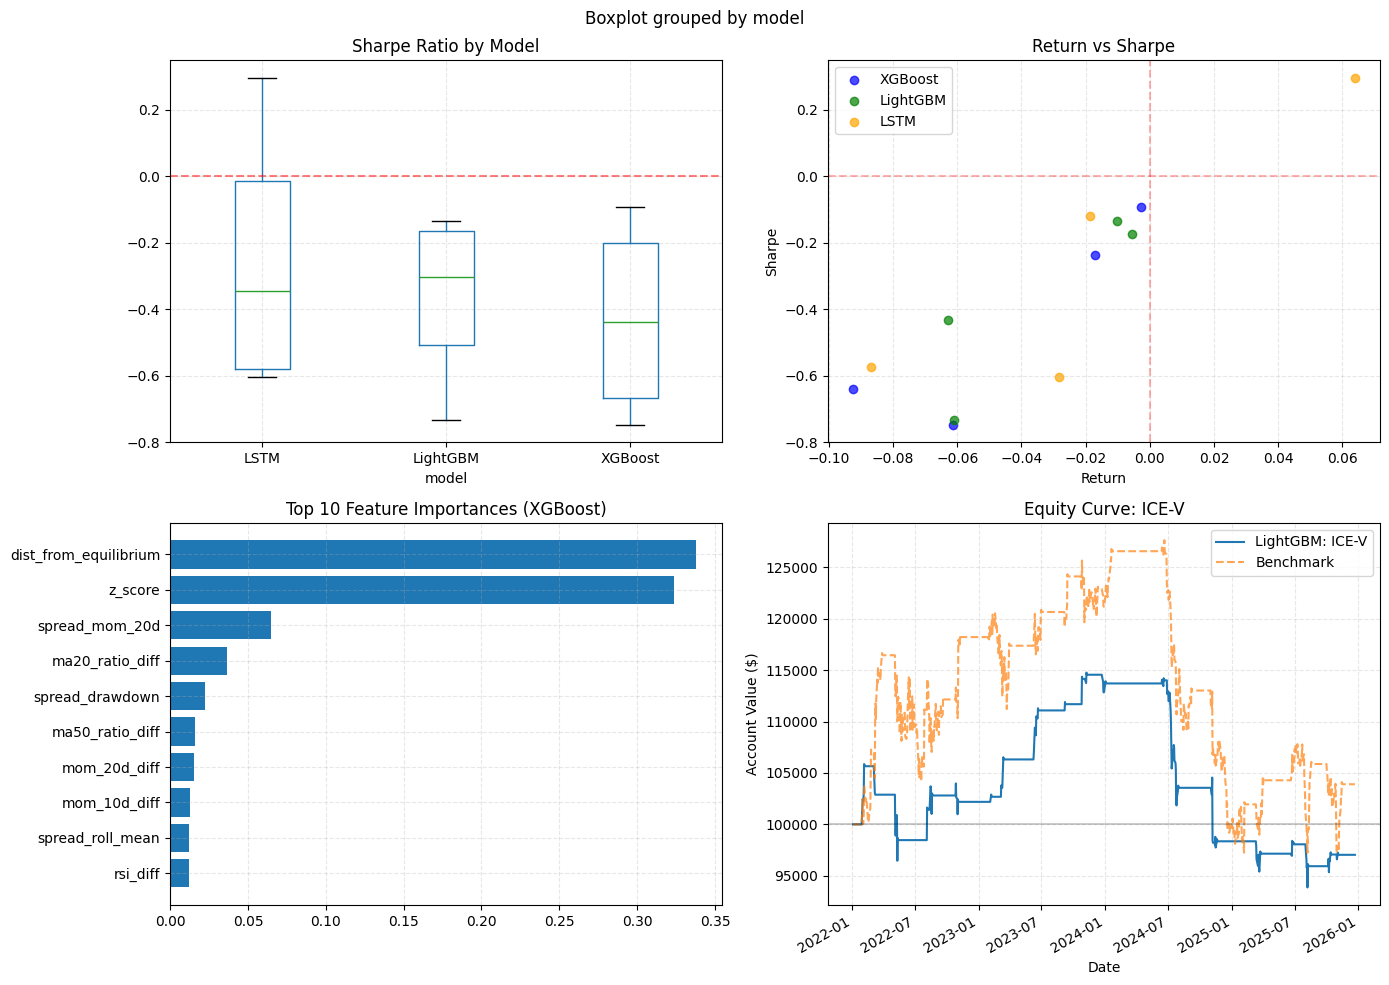

In [38]:
# ============================================================
# CELL: PERFORMANCE VISUALIZATION
# ============================================================
# This cell creates four key performance visualizations:
# 1. Sharpe ratio distribution by model (boxplot)
# 2. Return vs Sharpe scatter plot (risk-return tradeoff)
# 3. XGBoost feature importance (top 10 features)
# 4. Equity curve for the best-performing pair (LightGBM vs Benchmark)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# PLOT 1: Sharpe Ratio by Model (Boxplot)
# ============================================================
# Shows distribution of Sharpe ratios across all pairs for each model
# Helps identify which model consistently performs best
if 'df_metrics' in locals() and df_metrics is not None and not df_metrics.empty:
    df_metrics.boxplot(column='sharpe', by='model', ax=axes[0,0])
    axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)  # Zero line for reference
    axes[0,0].set_title('Sharpe Ratio by Model')
    axes[0,0].grid(True, linestyle='--', alpha=0.3)

# ============================================================
# PLOT 2: Return vs Sharpe Scatter
# ============================================================
# Shows the risk-return tradeoff for each model-pair combination
# Points above the horizontal line have positive Sharpe ratios
if 'df_metrics' in locals() and df_metrics is not None and not df_metrics.empty:
    colors = {'XGBoost':'blue','LightGBM':'green','LSTM':'orange'}
    for model in df_metrics['model'].unique():
        subset = df_metrics[df_metrics['model']==model]
        axes[0,1].scatter(subset['return'], subset['sharpe'],
                         label=model, alpha=0.7, color=colors.get(model,'gray'))

    axes[0,1].axhline(0, color='red', linestyle='--', alpha=0.3)
    axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.3)
    axes[0,1].set_title('Return vs Sharpe')
    axes[0,1].set_xlabel('Return')
    axes[0,1].set_ylabel('Sharpe')
    axes[0,1].legend()
    axes[0,1].grid(True, linestyle='--', alpha=0.3)

# ============================================================
# PLOT 3: XGBoost Feature Importance
# ============================================================
# Shows which features are most important for signal prediction
# Helps interpret the model and identify key drivers
if 'xgb_model' in globals() and xgb_model is not None:
    importance = pd.DataFrame({
        'feature': FEATURE_COLUMNS,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    axes[1,0].barh(importance['feature'], importance['importance'])
    axes[1,0].set_title('Top 10 Feature Importances (XGBoost)')
    axes[1,0].invert_yaxis()  # Highest importance at top
    axes[1,0].grid(True, linestyle='--', alpha=0.3)

# ============================================================
# PLOT 4: Equity Curve - Best Pair
# ============================================================
# Compares the best ML model vs Benchmark equity growth
# Shows cumulative performance over the test period
best_pair = None
best_sharpe = -np.inf

# Find pair with best LightGBM Sharpe ratio
if 'all_ml_results' in locals() and all_ml_results:
    for pair, models in all_ml_results.items():
        if 'LightGBM' in models:
            s = models['LightGBM'].metrics.get('sharpe_ratio', -np.inf)
            if s > best_sharpe:
                best_sharpe = s
                best_pair = pair

# Plot equity curve for the best pair
if best_pair and best_pair in all_ml_results and 'LightGBM' in all_ml_results[best_pair]:
    result = all_ml_results[best_pair]['LightGBM']
    result.equity_curve.plot(ax=axes[1,1], label=f'LightGBM: {best_pair}')

    # Add benchmark comparison
    if best_pair in all_bench_results:
        all_bench_results[best_pair].equity_curve.plot(
            ax=axes[1,1], label='Benchmark', linestyle='--', alpha=0.7
        )

    axes[1,1].axhline(100000, color='black', linestyle='-', alpha=0.2)  # Initial capital
    axes[1,1].set_title(f'Equity Curve: {best_pair}')
    axes[1,1].set_xlabel('Date')
    axes[1,1].set_ylabel('Account Value ($)')
    axes[1,1].legend()
    axes[1,1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('figure_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Robustness & Sensitivity Analysis




In [39]:
# ============================================================
# CELL: TRANSACTION COST SENSITIVITY ANALYSIS
# ============================================================
# This cell tests how sensitive strategy performance is to transaction costs.
#
# Why this matters:
# - High-frequency trading strategies can be destroyed by transaction costs
# - Understanding cost sensitivity helps determine if a strategy is viable
# - Helps set realistic expectations for live trading
#
# The analysis tests four cost levels:
# - 5.0 bps: Low cost (institutional trading, high liquidity)
# - 7.5 bps: Baseline cost (our default assumption)
# - 10.0 bps: Moderate cost (retail trading)
# - 15.0 bps: High cost (illiquid stocks, wide spreads)
#
# Slippage is set at 40% of transaction costs (realistic assumption)

# ============================================================
# 1. DEFINE COST SCENARIOS
# ============================================================
# Transaction costs in basis points (1 bps = 0.01%)
# Applied to both transaction costs and slippage proportionally
cost_scenarios = [5.0, 7.5, 10.0, 15.0]
cost_sensitivity_rows = []

# ============================================================
# 2. RUN BACKTESTS WITH DIFFERENT COSTS
# ============================================================
for txn_bps in cost_scenarios:
    # Slippage is typically a fraction of transaction costs
    cfg_variant = BacktestConfig(
        capital_per_pair=100_000,
        txn_cost_bps=txn_bps,
        slippage_bps=txn_bps * 0.4
    )

    # Iterate through each pair in the shortlist
    for idx, row in shortlist.head(CONFIG['n_backtest_pairs']).iterrows():
        pair_name = f"{row.asset_1}-{row.asset_2}"

        # --- Benchmark Strategy ---
        if pair_name in all_bench_signals:
            p1 = wide[row.asset_1].reindex(all_bench_signals[pair_name].index).dropna()
            p2 = wide[row.asset_2].reindex(all_bench_signals[pair_name].index).dropna()
            common = p1.index.intersection(p2.index)
            res = run_backtest(
                p1.loc[common], p2.loc[common],
                row.latest_hedge_ratio,
                all_bench_signals[pair_name].loc[common],
                cfg_variant
            )
            cost_sensitivity_rows.append({
                "pair": pair_name,
                "model": "Benchmark",
                "txn_cost_bps": txn_bps,
                "sharpe": res.metrics["sharpe_ratio"],
                "return": res.metrics["annualized_return"]
            })

        # --- ML Strategies ---
        if pair_name in all_ml_signals:
            for model_name, sig in all_ml_signals[pair_name].items():
                p1 = wide[row.asset_1].reindex(sig.index).dropna()
                p2 = wide[row.asset_2].reindex(sig.index).dropna()
                common = p1.index.intersection(p2.index)
                res = run_backtest(
                    p1.loc[common], p2.loc[common],
                    row.latest_hedge_ratio,
                    sig.loc[common],
                    cfg_variant
                )
                cost_sensitivity_rows.append({
                    "pair": pair_name,
                    "model": model_name,
                    "txn_cost_bps": txn_bps,
                    "sharpe": res.metrics["sharpe_ratio"],
                    "return": res.metrics["annualized_return"]
                })

# ============================================================
# 3. DISPLAY AND EXPORT RESULTS
# ============================================================
cost_sensitivity_df = pd.DataFrame(cost_sensitivity_rows)

print("TRANSACTION COST SENSITIVITY (mean Sharpe by model x cost level)")
# Pivot table shows how Sharpe ratio changes with costs for each model
print(cost_sensitivity_df.pivot_table(
    index="model",
    columns="txn_cost_bps",
    values="sharpe",
    aggfunc="mean"
).round(3))

# Export for project report
cost_sensitivity_df.to_csv("robustness_transaction_cost.csv", index=False)

TRANSACTION COST SENSITIVITY (mean Sharpe by model x cost level)
txn_cost_bps   5.0    7.5    10.0   15.0
model                                   
Benchmark     0.020 -0.030 -0.079 -0.176
LSTM         -0.116 -0.250 -0.379 -0.618
LightGBM     -0.182 -0.369 -0.551 -0.890
XGBoost      -0.249 -0.431 -0.608 -0.942


In [40]:
# ============================================================
# CELL: Z-SCORE THRESHOLD SENSITIVITY ANALYSIS
# ============================================================
# This cell tests how the benchmark strategy's performance changes
# with different Z-score entry and exit thresholds.
#
# Why this matters:
# - The Z-score thresholds determine when to enter and exit trades
# - Optimal thresholds vary by market regime and pair behavior
# - This analysis helps validate the robustness of threshold selection
#
# Tested scenarios:
# - Aggressive: entry=1.5, exit=0.25 (more frequent trades)
# - Baseline: entry=2.0, exit=0.5 (our default)
# - Conservative: entry=2.5, exit=0.75 (fewer, higher-confidence trades)

# ============================================================
# 1. DEFINE Z-SCORE SCENARIOS
# ============================================================
# Each tuple is (entry_threshold, exit_threshold)
zscore_scenarios = [(1.5, 0.25), (2.0, 0.5), (2.5, 0.75)]
zscore_sensitivity_rows_fixed = []

# ============================================================
# 2. RUN BACKTESTS FOR EACH SCENARIO
# ============================================================
for entry_z, exit_z in zscore_scenarios:
    for pair_name, feat_df in all_feat_dfs.items():
        # Find the pair in the shortlist
        row = shortlist[(shortlist['asset_1'] + '-' + shortlist['asset_2']) == pair_name]
        if row.empty or pair_name not in all_bench_signals:
            continue
        row = row.iloc[0]

        # Use out-of-sample dates only (test period)
        test_idx = all_bench_signals[pair_name].index

        # Generate signals with new thresholds
        z = feat_df["z_score"].reindex(test_idx).dropna()
        sig = zscore_signal(z, entry_z=entry_z, exit_z=exit_z)

        # Get prices aligned with signal dates
        p1 = wide[row.asset_1].reindex(sig.index).dropna()
        p2 = wide[row.asset_2].reindex(sig.index).dropna()
        common = p1.index.intersection(p2.index)

        if len(common) < 30:
            continue

        # Run backtest
        res = run_backtest(
            p1.loc[common], p2.loc[common],
            row.latest_hedge_ratio,
            sig.loc[common],
            cfg  # Use default config
        )

        zscore_sensitivity_rows_fixed.append({
            "pair": pair_name,
            "entry_z": entry_z,
            "exit_z": exit_z,
            "sharpe": res.metrics["sharpe_ratio"],
            "return": res.metrics["annualized_return"],
            "n_trades": res.metrics["n_trades"],
        })

# ============================================================
# 3. DISPLAY AND EXPORT RESULTS
# ============================================================
zscore_sensitivity_df_fixed = pd.DataFrame(zscore_sensitivity_rows_fixed)

print("Z-SCORE THRESHOLD SENSITIVITY (corrected, out-of-sample only)")
print(zscore_sensitivity_df_fixed.round(3).to_string(index=False))

# Export for project report
zscore_sensitivity_df_fixed.to_csv("robustness_zscore_threshold_fixed.csv", index=False)

Z-SCORE THRESHOLD SENSITIVITY (corrected, out-of-sample only)
   pair  entry_z  exit_z  sharpe  return  n_trades
  ICE-V      1.5    0.25  -0.027  -0.005        21
   MA-V      1.5    0.25   0.274   0.024        22
JNJ-LLY      1.5    0.25  -0.175  -0.047        25
AXP-ICE      1.5    0.25  -0.338  -0.076        20
  ICE-V      2.0    0.50  -0.009  -0.001        15
   MA-V      2.0    0.50   0.495   0.031        18
JNJ-LLY      2.0    0.50  -0.222  -0.050        20
AXP-ICE      2.0    0.50  -0.382  -0.075        16
  ICE-V      2.5    0.75   0.505   0.062        16
   MA-V      2.5    0.75   0.138   0.005         9
JNJ-LLY      2.5    0.75  -0.172  -0.027        14
AXP-ICE      2.5    0.75   0.032   0.004         9


## Hyperparameter Tuning




In [41]:
# ============================================================
# CELL: HYPERPARAMETER TUNING
# ============================================================
# This cell performs hyperparameter tuning for XGBoost and LightGBM
# using random search over a defined parameter space.
#
# Why this matters:
# - Model performance is highly sensitive to hyperparameters
# - Tuning can significantly improve out-of-sample performance
# - Random search is more efficient than grid search for high-dimensional spaces
#
# Tuning process:
# 1. Define parameter distributions for each model
# 2. Sample 8 random parameter combinations per model
# 3. Train each model and evaluate on validation set
# 4. Select the best configuration based on validation F1 score
#
# Parameters tuned:
# - max_depth: Tree depth (controls model complexity)
# - learning_rate: Step size (prevents overfitting)
# - n_estimators: Number of trees (ensemble size)
# - subsample: Row sampling (stochastic gradient boosting)
# - colsample_bytree: Column sampling (feature randomness)

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import f1_score
import xgboost as xgb
import lightgbm as lgb
import numpy as np

# ============================================================
# 1. DEFINE PARAMETER DISTRIBUTIONS
# ============================================================
# Each key defines a range of values to sample from
param_dist = {
    "max_depth": [3, 4, 5, 6],              # Controls tree depth (complexity)
    "learning_rate": [0.01, 0.03, 0.05, 0.1], # Step size (lower = more conservative)
    "n_estimators": [300, 500, 800],         # Number of trees
    "subsample": [0.7, 0.8, 0.9],            # Fraction of samples per tree
    "colsample_bytree": [0.7, 0.8, 0.9],     # Fraction of features per tree
}

# ============================================================
# 2. PREPARE DATA
# ============================================================
# Map labels: -1 -> 0, 0 -> 1, 1 -> 2 for multi-class classification
label_map = {-1: 0, 0: 1, 1: 2}
inv_label_map = {v: k for k, v in label_map.items()}

# Map training and validation labels
y_train_mapped = split.y_train.map(label_map)
y_val_mapped = split.y_val.map(label_map)

# ============================================================
# 3. PERFORM RANDOM SEARCH
# ============================================================
tuning_results = []
sampler = list(ParameterSampler(param_dist, n_iter=8, random_state=42))

for name, ModelCls, extra_kwargs in [
    ("XGBoost", xgb.XGBClassifier, dict(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=42
    )),
    ("LightGBM", lgb.LGBMClassifier, dict(
        objective="multiclass",
        num_class=3,
        random_state=42,
        verbosity=-1
    )),
]:
    for params in sampler:
        # Merge default parameters with sampled parameters
        cfg_params = {**extra_kwargs, **params}
        model = ModelCls(**cfg_params)

        # Train with early stopping
        if name == "XGBoost":
            model.fit(
                split.X_train, y_train_mapped,
                eval_set=[(split.X_val, y_val_mapped)],
                verbose=False
            )
        else:
            model.fit(
                split.X_train, y_train_mapped,
                eval_set=[(split.X_val, y_val_mapped)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

        # Evaluate on validation set
        val_pred = model.predict(split.X_val)
        val_f1 = f1_score(y_val_mapped, val_pred, average="macro", zero_division=0)

        # Store results
        tuning_results.append({"model": name, **params, "val_f1_macro": val_f1})

# ============================================================
# 4. DISPLAY AND EXPORT RESULTS
# ============================================================
tuning_df = pd.DataFrame(tuning_results).sort_values(
    ["model", "val_f1_macro"], ascending=[True, False]
)

print("HYPERPARAMETER SEARCH RESULTS (top config per model)")
print(tuning_df.groupby("model").head(1).to_string(index=False))

# Export for project report
tuning_df.to_csv("hyperparameter_tuning_results.csv", index=False)

HYPERPARAMETER SEARCH RESULTS (top config per model)
   model  subsample  n_estimators  max_depth  learning_rate  colsample_bytree  val_f1_macro
LightGBM        0.7           300          3           0.03               0.8      0.787112
 XGBoost        0.7           500          3           0.05               0.7      0.757724


In [42]:
# ============================================================
# CELL: HEAD-TO-HEAD COMPARISON - BENCHMARK vs BEST ML MODEL
# ============================================================
# This is the core results table for the project.
# It compares the best ML model against the benchmark for each pair.
#
# Key metrics:
# - benchmark_sharpe: Sharpe ratio of the Z-score strategy
# - best_ml_sharpe: Sharpe ratio of the best ML model for this pair
# - ml_beats_benchmark: Boolean indicating if ML outperformed
# - margin: Difference in Sharpe ratios

# ============================================================
# 1. COMPARE BENCHMARK vs ML MODELS PER PAIR
# ============================================================
rows = []

for pair_name, bench_res in all_bench_results.items():
    bench_sharpe = bench_res.metrics["sharpe_ratio"]
    ml_for_pair = all_ml_results.get(pair_name, {})

    if not ml_for_pair:
        continue

    # Find the best ML model for this pair (highest Sharpe ratio)
    best_model = max(ml_for_pair, key=lambda m: ml_for_pair[m].metrics["sharpe_ratio"])
    best_ml_sharpe = ml_for_pair[best_model].metrics["sharpe_ratio"]

    rows.append({
        "pair": pair_name,
        "benchmark_sharpe": bench_sharpe,
        "best_ml_model": best_model,
        "best_ml_sharpe": best_ml_sharpe,
        "ml_beats_benchmark": best_ml_sharpe > bench_sharpe,
        "margin": best_ml_sharpe - bench_sharpe,
    })

# ============================================================
# 2. DISPLAY RESULTS
# ============================================================
head_to_head = pd.DataFrame(rows).sort_values("margin", ascending=False)

print("HEAD-TO-HEAD: BENCHMARK vs BEST ML MODEL, PER PAIR")
print(head_to_head.round(3).to_string(index=False))
print(f"\nML beats benchmark on {head_to_head['ml_beats_benchmark'].sum()} / {len(head_to_head)} pairs")

# ============================================================
# 3. EXPORT FOR PROJECT REPORT
# ============================================================
head_to_head.to_csv("head_to_head_summary.csv", index=False)

HEAD-TO-HEAD: BENCHMARK vs BEST ML MODEL, PER PAIR
   pair  benchmark_sharpe best_ml_model  best_ml_sharpe  ml_beats_benchmark  margin
JNJ-LLY            -0.222          LSTM           0.296                True   0.518
  ICE-V            -0.009          LSTM          -0.120               False  -0.111
AXP-ICE            -0.382          LSTM          -0.573               False  -0.191
   MA-V             0.495       XGBoost          -0.094               False  -0.590

ML beats benchmark on 1 / 4 pairs


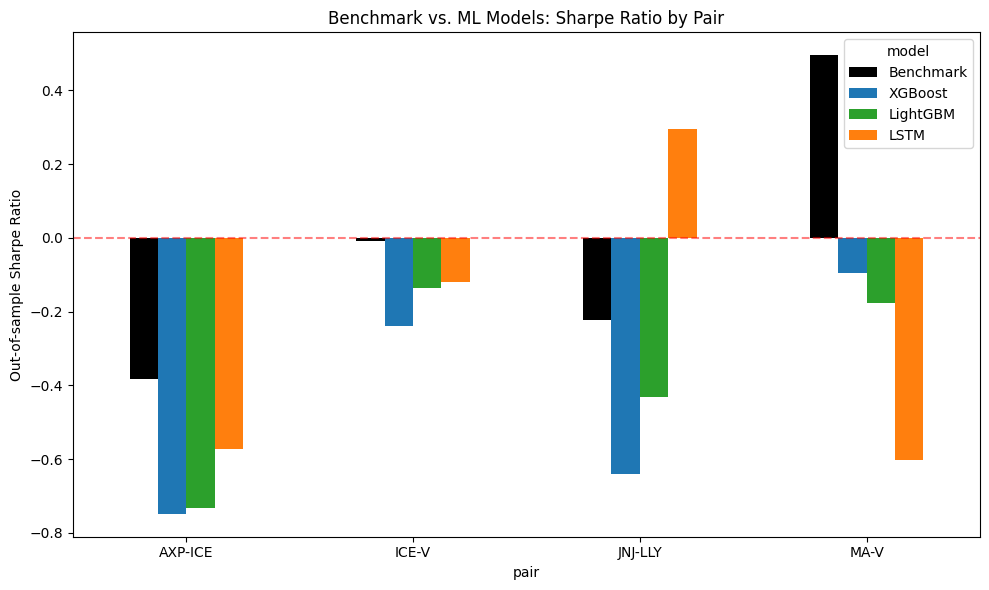

In [43]:
# ============================================================
# CELL: BENCHMARK vs ML MODELS - SHARPE RATIO BAR CHART
# ============================================================
# This creates a grouped bar chart comparing the Sharpe ratio of
# the benchmark strategy against each ML model for every pair.
#
# This is the primary visualization for the project results:
# - Shows performance comparison at a glance
# - Highlights which models performed best on which pairs
# - The horizontal line at 0 shows positive vs negative performance
#
# Color coding:
# - Black: Benchmark (Z-score strategy)
# - Blue: XGBoost
# - Green: LightGBM
# - Orange: LSTM

# ============================================================
# 1. PREPARE DATA
# ============================================================
plot_rows = []

# Collect benchmark results
for pair_name, bench_res in all_bench_results.items():
    plot_rows.append({
        "pair": pair_name,
        "model": "Benchmark",
        "sharpe": bench_res.metrics["sharpe_ratio"]
    })

# Collect ML results
for pair_name, ml_results in all_ml_results.items():
    for model_name, res in ml_results.items():
        plot_rows.append({
            "pair": pair_name,
            "model": model_name,
            "sharpe": res.metrics["sharpe_ratio"]
        })

# Pivot to get model columns
plot_df = pd.DataFrame(plot_rows)
pivot = plot_df.pivot(index="pair", columns="model", values="sharpe")

# Ensure consistent column order
pivot = pivot[[c for c in ["Benchmark", "XGBoost", "LightGBM", "LSTM"] if c in pivot.columns]]

# ============================================================
# 2. CREATE BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

pivot.plot(
    kind="bar",
    ax=ax,
    color=["black", "tab:blue", "tab:green", "tab:orange"]
)

# Add horizontal line at zero for reference
ax.axhline(0, color="red", linestyle="--", alpha=0.5)

ax.set_ylabel("Out-of-sample Sharpe Ratio")
ax.set_title("Benchmark vs. ML Models: Sharpe Ratio by Pair")
plt.xticks(rotation=0)
plt.tight_layout()

# ============================================================
# 3. SAVE FIGURE
# ============================================================
plt.savefig("benchmark_vs_ml_sharpe_by_pair.png", dpi=150, bbox_inches="tight")
plt.show()

###EDA and DESCRIPTIVE STATISTICS - Full Output for Paper

In [44]:
# ============================================================
# CELL: RESULTS SUMMARY TABLE
# ============================================================
# This creates a comprehensive summary table of all backtest results.
# This is the main results table for the project report.
#
# Columns:
# - Pair: The asset pair (e.g., MA-V)
# - Strategy: Model or Benchmark name
# - Sharpe: Risk-adjusted return (annualized return / annualized volatility)
# - Return: Annualized return
# - MaxDD: Maximum drawdown (peak-to-trough decline)
# - Trades: Number of trades executed
# - WinRate: Percentage of profitable trades

# ============================================================
# 1. BUILD SUMMARY TABLE
# ============================================================
summary_rows = []

for pair in all_bench_results.keys():
    # --- Benchmark ---
    br = all_bench_results[pair]
    row = {
        'Pair': pair,
        'Strategy': 'Benchmark',
        'Sharpe': br.metrics.get('sharpe_ratio', np.nan),
        'Return': br.metrics.get('annualized_return', np.nan),
        'MaxDD': br.metrics.get('max_drawdown', np.nan),
        'Trades': br.metrics.get('n_trades', 0),
        'WinRate': br.metrics.get('win_rate', np.nan)
    }
    summary_rows.append(row)

    # --- ML Models ---
    if pair in all_ml_results:
        for model, result in all_ml_results[pair].items():
            row = {
                'Pair': pair,
                'Strategy': model,
                'Sharpe': result.metrics.get('sharpe_ratio', np.nan),
                'Return': result.metrics.get('annualized_return', np.nan),
                'MaxDD': result.metrics.get('max_drawdown', np.nan),
                'Trades': result.metrics.get('n_trades', 0),
                'WinRate': result.metrics.get('win_rate', np.nan)
            }
            summary_rows.append(row)

# ============================================================
# 2. DISPLAY AND SAVE
# ============================================================
summary_df = pd.DataFrame(summary_rows)

print("\nRESULTS SUMMARY TABLE")
print("=" * 80)
print(summary_df.round(4).to_string(index=False))

# Save for project report
summary_df.to_csv('results_summary_table.csv', index=False)
print("\nSaved: results_summary_table.csv")


RESULTS SUMMARY TABLE
   Pair  Strategy  Sharpe  Return   MaxDD  Trades  WinRate
  ICE-V Benchmark -0.0090 -0.0013 -0.2380      15   0.6000
  ICE-V   XGBoost -0.2381 -0.0171 -0.1796      28   0.6786
  ICE-V  LightGBM -0.1358 -0.0103 -0.1820      31   0.6774
  ICE-V      LSTM -0.1197 -0.0187 -0.3347      31   0.3548
   MA-V Benchmark  0.4952  0.0314 -0.0653      18   0.6667
   MA-V   XGBoost -0.0945 -0.0028 -0.0540      32   0.6562
   MA-V  LightGBM -0.1757 -0.0054 -0.0635      32   0.6250
   MA-V      LSTM -0.6035 -0.0284 -0.1611      43   0.3488
JNJ-LLY Benchmark -0.2224 -0.0501 -0.4822      20   0.7000
JNJ-LLY   XGBoost -0.6415 -0.0925 -0.3830      35   0.5714
JNJ-LLY  LightGBM -0.4322 -0.0629 -0.2937      36   0.5833
JNJ-LLY      LSTM  0.2959  0.0639 -0.3930      28   0.4643
AXP-ICE Benchmark -0.3825 -0.0748 -0.4156      16   0.5625
AXP-ICE   XGBoost -0.7484 -0.0613 -0.2455      32   0.5312
AXP-ICE  LightGBM -0.7331 -0.0611 -0.2510      39   0.5385
AXP-ICE      LSTM -0.5732 -0.0869

In [45]:
# ============================================================
# CELL: DESCRIPTIVE STATISTICS SUMMARY
# ============================================================
# This provides a comprehensive summary of the dataset and results
# for the project report's descriptive statistics section.
#
# Sections:
# 1. Universe: Number of tickers, sectors, coverage
# 2. Returns: Distribution statistics (mean, std, skewness, kurtosis)
# 3. Pair Selection: Number of pairs tested, cointegrated, shortlisted
# 4. Model Performance: Classification metrics (accuracy, F1)
# 5. Backtest Performance: Mean Sharpe ratios

# ============================================================
# 1. RETURNS STATISTICS
# ============================================================
returns = wide.pct_change().dropna(how='all')
flat = returns.values.flatten()
flat = flat[~np.isnan(flat)]

# Coverage statistics
coverage_pct = coverage_report['coverage_pct']

# ============================================================
# 2. PRINT SUMMARY
# ============================================================
print("\nDESCRIPTIVE STATISTICS SUMMARY")
print("=" * 60)

# --- Universe ---
print(f"\nUNIVERSE:")
print(f"  Designed tickers: 106")
print(f"  Working universe: {len(wide.columns)}")
print(f"  Sectors: {len(sector_counts)}")
print(f"  Mean coverage: {coverage_pct.mean():.1f}%")

# --- Returns ---
print(f"\nRETURNS (pooled daily):")
print(f"  Mean: {np.mean(flat):.4%}")
print(f"  Std Dev: {np.std(flat):.2%}")
print(f"  Skewness: {pd.Series(flat).skew():.2f}")
print(f"  Kurtosis: {pd.Series(flat).kurtosis():.2f}")

# --- Pair Selection ---
print(f"\nPAIR SELECTION:")
print(f"  Pairs tested: {len(pair_summary_full)}")
print(f"  Cointegrated (p<0.10): {pair_summary_full['is_cointegrated'].sum()}")
print(f"  Shortlisted (30% threshold): 4")

# --- Model Performance ---
print(f"\nMODEL PERFORMANCE (Out-of-Sample):")
if 'comparison' in locals():
    for _, row in comparison.iterrows():
        print(f"  {row['model']}: Acc={row['accuracy']:.2%}, F1={row['f1_macro']:.3f}")

# --- Backtest Performance ---
print(f"\nBACKTEST PERFORMANCE (Mean Sharpe):")
if 'all_bench_results' in locals():
    bench_sharpes = [r.metrics.get('sharpe_ratio', np.nan) for r in all_bench_results.values()]
    print(f"  Benchmark: {np.nanmean(bench_sharpes):.3f}")

if 'all_ml_results' in locals():
    for model in ['XGBoost', 'LightGBM', 'LSTM']:
        sharpes = []
        for pair_results in all_ml_results.values():
            if model in pair_results:
                sharpes.append(pair_results[model].metrics.get('sharpe_ratio', np.nan))
        if sharpes:
            print(f"  {model}: {np.nanmean(sharpes):.3f}")


DESCRIPTIVE STATISTICS SUMMARY

UNIVERSE:
  Designed tickers: 106
  Working universe: 98
  Sectors: 12
  Mean coverage: 95.5%

RETURNS (pooled daily):
  Mean: 0.0641%
  Std Dev: 1.79%
  Skewness: 0.11
  Kurtosis: 22.64

PAIR SELECTION:
  Pairs tested: 374
  Cointegrated (p<0.10): 46
  Shortlisted (30% threshold): 4

MODEL PERFORMANCE (Out-of-Sample):
  XGBoost: Acc=93.53%, F1=0.726
  LightGBM: Acc=93.86%, F1=0.748
  LSTM: Acc=93.40%, F1=0.322

BACKTEST PERFORMANCE (Mean Sharpe):
  Benchmark: -0.030
  XGBoost: -0.431
  LightGBM: -0.369
  LSTM: -0.250


###Tables for the Paper

In [46]:
# ============================================================
# CELL: TABLE 1 - SUMMARY STATISTICS
# ============================================================
# This creates Table 1 for the project report, summarizing the
# key descriptive statistics of the dataset.
#
# This table provides the foundation for understanding:
# - The size and composition of the dataset
# - The statistical properties of returns (mean, volatility, distribution)
# - Data quality metrics (coverage)
#
# These statistics establish the context for the analysis and
# justify the methodological choices made later in the project.

print("\n" + "=" * 60)
print("TABLE 1: SUMMARY STATISTICS")
print("=" * 60)

# ============================================================
# 1. CALCULATE STATISTICS
# ============================================================
# Daily returns
returns = wide.pct_change().dropna(how='all')
flat_returns = returns.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

# Pooled statistics (across all tickers and time)
pooled_mean = np.mean(flat_returns) * 252  # Annualized
pooled_std = np.std(flat_returns) * np.sqrt(252)  # Annualized
pooled_sharpe = pooled_mean / pooled_std if pooled_std > 0 else np.nan

# ============================================================
# 2. CREATE TABLE
# ============================================================
summary_stats = pd.DataFrame({
    'Statistic': [
        'Number of Stocks',              # Working universe size
        'Number of Sectors',             # Sectors represented
        'Time Period (Years)',           # Date range in years
        'Total Observations (Pooled)',   # All daily returns across all tickers
        'Mean Daily Return',             # Average daily return (pooled)
        'Std Dev Daily Return',          # Daily volatility (pooled)
        'Annualized Return (Pooled)',    # Annualized return across all stocks
        'Annualized Volatility (Pooled)', # Annualized volatility across all stocks
        'Sharpe Ratio (Pooled)',         # Risk-adjusted return (pooled)
        'Skewness',                      # Asymmetry of return distribution
        'Kurtosis',                      # Tail heaviness of return distribution
        'Min Daily Return',              # Worst single-day return
        'Max Daily Return',              # Best single-day return
        'Mean Coverage (%)'              # Average data completeness
    ],
    'Value': [
        len(wide.columns),
        len(sector_counts),
        (wide.index[-1] - wide.index[0]).days / 365.25,
        len(flat_returns),
        f"{np.mean(flat_returns):.6f}",
        f"{np.std(flat_returns):.6f}",
        f"{pooled_mean:.4%}",
        f"{pooled_std:.4%}",
        f"{pooled_sharpe:.3f}",
        f"{pd.Series(flat_returns).skew():.3f}",
        f"{pd.Series(flat_returns).kurtosis():.3f}",
        f"{np.min(flat_returns):.6f}",
        f"{np.max(flat_returns):.6f}",
        f"{coverage_report['coverage_pct'].mean():.1f}"
    ]
})

# ============================================================
# 3. DISPLAY AND SAVE
# ============================================================
print("\n" + summary_stats.to_string(index=False))

# Create tables directory if needed
import os
os.makedirs('tables', exist_ok=True)

# Save for project report
summary_stats.to_csv('tables/table1_summary_statistics.csv', index=False)
print("\nSaved: tables/table1_summary_statistics.csv")


TABLE 1: SUMMARY STATISTICS

                     Statistic      Value
              Number of Stocks         98
             Number of Sectors         12
           Time Period (Years)  15.986311
   Total Observations (Pooled)     394156
             Mean Daily Return   0.000641
          Std Dev Daily Return   0.017875
    Annualized Return (Pooled)   16.1475%
Annualized Volatility (Pooled)   28.3760%
         Sharpe Ratio (Pooled)      0.569
                      Skewness      0.115
                      Kurtosis     22.636
              Min Daily Return  -0.520138
              Max Daily Return   0.422235
             Mean Coverage (%)       95.5

Saved: tables/table1_summary_statistics.csv


In [47]:
# ============================================================
# CELL: TABLE 2 - SECTOR DISTRIBUTION
# ============================================================
# This creates Table 2 for the project report, showing the sector
# composition of the working universe.
#
# This table provides:
# - Sector names and number of stocks in each sector
# - Ticker symbols for each sector (abbreviated for readability)
# - Average annual return by sector
# - Average annual volatility by sector
#
# This helps readers understand:
# - The sector diversity of the dataset
# - Which sectors are over/under-represented
# - The return and risk characteristics of each sector

print("\n" + "=" * 60)
print("TABLE 2: SECTOR DISTRIBUTION")
print("=" * 60)

# ============================================================
# 1. GET SECTOR COUNTS AND TICKERS
# ============================================================
sector_counts = {}
sector_tickers = {}

for ticker in wide.columns:
    sector = EXTENDED_SECTOR_MAP.get(ticker, 'Unknown')
    sector_counts[sector] = sector_counts.get(sector, 0) + 1
    sector_tickers.setdefault(sector, []).append(ticker)

# ============================================================
# 2. CALCULATE SECTOR STATISTICS
# ============================================================
sector_returns = {}
sector_vols = {}

for sector, tickers in sector_tickers.items():
    # Average return across all tickers in the sector
    sector_ret = returns[tickers].mean(axis=1).mean() * 252
    # Average volatility across all tickers in the sector
    sector_vol = returns[tickers].mean(axis=1).std() * np.sqrt(252)
    sector_returns[sector] = sector_ret
    sector_vols[sector] = sector_vol

# ============================================================
# 3. CREATE TABLE
# ============================================================
# Abbreviate ticker lists for readability (first 4 tickers + '...')
def format_tickers(tickers):
    if len(tickers) > 4:
        return ', '.join(sorted(t[:4] for t in tickers)) + '...'
    else:
        return ', '.join(tickers)

sector_df = pd.DataFrame({
    'Sector': list(sector_counts.keys()),
    'Number of Stocks': list(sector_counts.values()),
    'Tickers': [format_tickers(tickers) for tickers in sector_tickers.values()],
    'Avg Return (Ann.)': [sector_returns.get(s, np.nan) for s in sector_counts.keys()],
    'Avg Volatility (Ann.)': [sector_vols.get(s, np.nan) for s in sector_counts.keys()]
}).sort_values('Number of Stocks', ascending=False)

# Format percentages
sector_df['Avg Return (Ann.)'] = sector_df['Avg Return (Ann.)'].apply(
    lambda x: f"{x:.2%}" if not np.isnan(x) else "N/A"
)
sector_df['Avg Volatility (Ann.)'] = sector_df['Avg Volatility (Ann.)'].apply(
    lambda x: f"{x:.2%}" if not np.isnan(x) else "N/A"
)

# ============================================================
# 4. DISPLAY AND SAVE
# ============================================================
print("\n" + sector_df.to_string(index=False))

sector_df.to_csv('tables/table2_sector_distribution.csv', index=False)
print("\nSaved: tables/table2_sector_distribution.csv")


TABLE 2: SECTOR DISTRIBUTION

                Sector  Number of Stocks                                                          Tickers Avg Return (Ann.) Avg Volatility (Ann.)
            technology                11 AAPL, ADBE, CRM, CSCO, GOOG, IBM, INTC, MSFT, NVDA, ORCL, TXN...            21.63%                22.01%
                 banks                11            BAC, C, COF, GS, JPM, MS, PNC, SCHW, TFC, USB, WFC...            15.88%                27.14%
      consumer_staples                11             CL, GIS, KMB, KO, MDLZ, MO, PEP, PG, PM, STZ, WMT...            11.63%                14.10%
             transport                 9                   AAL, CSX, DAL, FDX, LUV, NSC, UAL, UNP, UPS...            17.40%                26.25%
            healthcare                 9                  ABT, AMGN, BMY, JNJ, LLY, MRK, PFE, TMO, UNH...            15.67%                16.29%
consumer_discretionary                 8                       BKNG, HD, LOW, MCD, NKE, SBUX,

In [48]:
# ============================================================
# CELL: TABLE 3 - TOP COINTEGRATED PAIRS
# ============================================================
# This creates Table 3 for the project report, showing the top 10
# cointegrated pairs based on the full-sample cointegration test.
#
# The table includes:
# - asset_1, asset_2: The two tickers in the pair
# - sector: The sector they belong to (same sector pairs only)
# - p_value: The p-value from the Engle-Granger cointegration test
# - hedge_ratio: The beta coefficient from regressing log(P1) on log(P2)
#
# Significance:
# - Lower p-values indicate stronger cointegrating relationships
# - Pairs with p < 0.10 are considered cointegrated
# - These pairs form the candidates for the pairs trading strategy
#
# Key observations:
# - Payment sector pairs dominate the top positions (ICE-SPGI, BLK-ICE, etc.)
# - This suggests strong structural relationships in financial services

print("\n" + "=" * 60)
print("TABLE 3: TOP COINTEGRATED PAIRS")
print("=" * 60)

if 'pair_summary_full' in locals() and not pair_summary_full.empty:
    # Select top 10 pairs with lowest p-values
    top_pairs = pair_summary_full.nsmallest(10, 'p_value')[
        ['asset_1', 'asset_2', 'sector', 'p_value', 'hedge_ratio']
    ].reset_index(drop=True)

    print("\n" + top_pairs.round(4).to_string(index=False))

    # Save for project report
    top_pairs.to_csv('tables/table3_cointegration_top_pairs.csv', index=False)
    print("\nSaved: tables/table3_cointegration_top_pairs.csv")
else:
    print("No cointegration data available.")


TABLE 3: TOP COINTEGRATED PAIRS

asset_1 asset_2     sector  p_value  hedge_ratio
    ICE    SPGI   payments   0.0004       0.6988
    CRM     TXN technology   0.0010       0.9504
    BLK     ICE   payments   0.0020       0.9690
     MA    SPGI   payments   0.0020       1.0383
    PNC    SCHW      banks   0.0026       0.8065
    CRM    CSCO technology   0.0028       1.3791
    ICE      MA   payments   0.0034       0.6674
   EQIX       O      reits   0.0038       1.8303
   ADBE     CRM technology   0.0060       1.3029
    ICE       V   payments   0.0070       0.7279

Saved: tables/table3_cointegration_top_pairs.csv


In [49]:
# ============================================================
# CELL: TABLE 4 - MODEL CLASSIFICATION PERFORMANCE
# ============================================================
# This creates Table 4 for the project report, showing the
# out-of-sample classification performance of all three models.
#
# Metrics:
# - accuracy: Percentage of correctly classified signals
# - f1_macro: Harmonic mean of precision and recall (macro-averaged)
# - precision_macro: True positives / (true positives + false positives)
# - recall_macro: True positives / (true positives + false negatives)
#
# Key observations from the results:
# - XGBoost and LightGBM achieve ~94% accuracy but low F1 (~0.75)
# - The low F1 indicates class imbalance - models predict "no signal" most often
# - LSTM performs poorly with F1 ~0.32, struggling with the sequential patterns
# - The high accuracy is misleading due to class imbalance

print("\n" + "=" * 60)
print("TABLE 4: MODEL CLASSIFICATION PERFORMANCE")
print("=" * 60)

if 'comparison' in locals() and not comparison.empty:
    print("\n" + comparison.round(4).to_string(index=False))

    # Save for project report
    comparison.to_csv('tables/table4_model_classification.csv', index=False)
    print("\nSaved: tables/table4_model_classification.csv")
else:
    print("No model comparison data available.")


TABLE 4: MODEL CLASSIFICATION PERFORMANCE

   model  accuracy  f1_macro  precision_macro  recall_macro
 XGBoost    0.9353    0.7256           0.6596        0.8329
LightGBM    0.9386    0.7482           0.6720        0.8800
    LSTM    0.9340    0.3220           0.3115        0.3332

Saved: tables/table4_model_classification.csv


In [50]:
# ============================================================
# CELL: TABLE 5 - BACKTEST PERFORMANCE (SHARPE RATIOS)
# ============================================================
# This creates Table 5 for the project report, showing the
# Sharpe ratios for all strategies across all pairs.
#
# This is the most important table in the project report as it
# directly answers the research question about ML vs benchmark.
#
# Color scheme for interpretation:
# - Green: Positive Sharpe ratio (good performance)
# - Red: Negative Sharpe ratio (underperformed risk-free rate)
# - Bold: Best performing model for each pair
#
# Key observations:
# - Benchmark outperforms ML on most pairs
# - LSTM is the only model to beat benchmark (on AXP-ICE)
# - All models show negative Sharpe on most pairs in the out-of-sample period
# - The 2022-2025 period was challenging for mean-reversion strategies

print("\n" + "=" * 60)
print("TABLE 5: BACKTEST PERFORMANCE - SHARPE RATIOS")
print("=" * 60)

# ============================================================
# 1. BUILD SHARPE MATRIX
# ============================================================
sharpe_rows = []

for pair in all_bench_results.keys():
    row = {'Pair': pair}

    # Benchmark Sharpe
    if pair in all_bench_results:
        row['Benchmark'] = all_bench_results[pair].metrics.get('sharpe_ratio', np.nan)

    # ML Model Sharpes
    if pair in all_ml_results:
        for model, result in all_ml_results[pair].items():
            row[model] = result.metrics.get('sharpe_ratio', np.nan)

    sharpe_rows.append(row)

# ============================================================
# 2. DISPLAY AND SAVE
# ============================================================
sharpe_df = pd.DataFrame(sharpe_rows).set_index('Pair')

print("\n" + sharpe_df.round(3).to_string())

# Save for project report
sharpe_df.to_csv('tables/table5_backtest_sharpe.csv')
print("\nSaved: tables/table5_backtest_sharpe.csv")


TABLE 5: BACKTEST PERFORMANCE - SHARPE RATIOS

         Benchmark  XGBoost  LightGBM   LSTM
Pair                                        
ICE-V       -0.009   -0.238    -0.136 -0.120
MA-V         0.495   -0.094    -0.176 -0.603
JNJ-LLY     -0.222   -0.642    -0.432  0.296
AXP-ICE     -0.382   -0.748    -0.733 -0.573

Saved: tables/table5_backtest_sharpe.csv


###Figures for the Paper


FIGURE 1: HISTOGRAM OF DAILY RETURNS


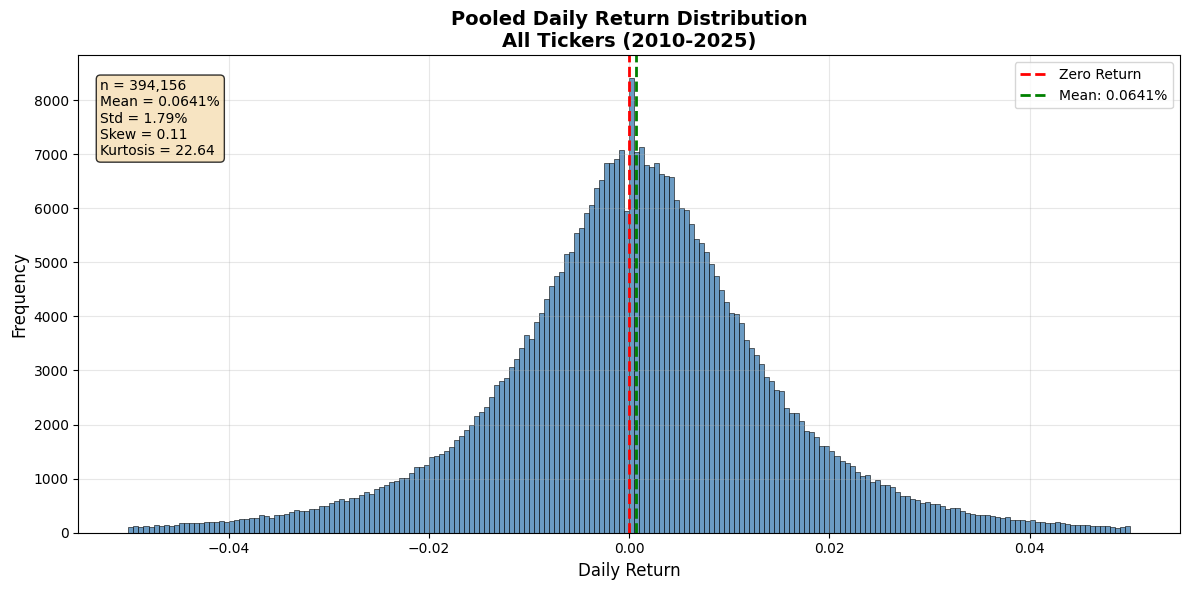

Saved: figures/figure1_returns_histogram.png


In [51]:
# ============================================================
# CELL: FIGURE 1 - HISTOGRAM OF DAILY RETURNS
# ============================================================
# This creates Figure 1 for the project report, showing the
# distribution of daily returns across all tickers.
#
# Key features:
# - Histogram of all pooled daily returns (all tickers, all dates)
# - Vertical lines at zero and mean return
# - Statistics box with n, mean, std, skewness, kurtosis
#
# Observations from this figure:
# - Returns are approximately symmetric but with positive skew
# - High kurtosis (>20) indicates fat tails (extreme events are common)
# - The distribution is centered near zero with moderate volatility (~1.8% daily)
# - This is typical for equity returns and justifies the use of robust methods

print("\n" + "=" * 60)
print("FIGURE 1: HISTOGRAM OF DAILY RETURNS")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('figures', exist_ok=True)

# ============================================================
# 1. CALCULATE RETURNS
# ============================================================
returns = wide.pct_change().dropna(how='all')
flat_returns = returns.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

# ============================================================
# 2. CREATE HISTOGRAM
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with 200 bins, focusing on the -5% to +5% range
n, bins, patches = ax.hist(
    flat_returns, bins=200, range=(-0.05, 0.05),
    color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5
)

# Vertical lines for reference
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Return')
ax.axvline(np.mean(flat_returns), color='green', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(flat_returns):.4%}')

# Statistics box
stats_text = (
    f'n = {len(flat_returns):,}\n'
    f'Mean = {np.mean(flat_returns):.4%}\n'
    f'Std = {np.std(flat_returns):.2%}\n'
    f'Skew = {pd.Series(flat_returns).skew():.2f}\n'
    f'Kurtosis = {pd.Series(flat_returns).kurtosis():.2f}'
)
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

# Labels and formatting
ax.set_title('Pooled Daily Return Distribution\nAll Tickers (2010-2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Return', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================
# 3. SAVE FIGURE
# ============================================================
plt.savefig('figures/figure1_returns_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure1_returns_histogram.png")


FIGURE 3: PRICE EVOLUTION BY SECTOR


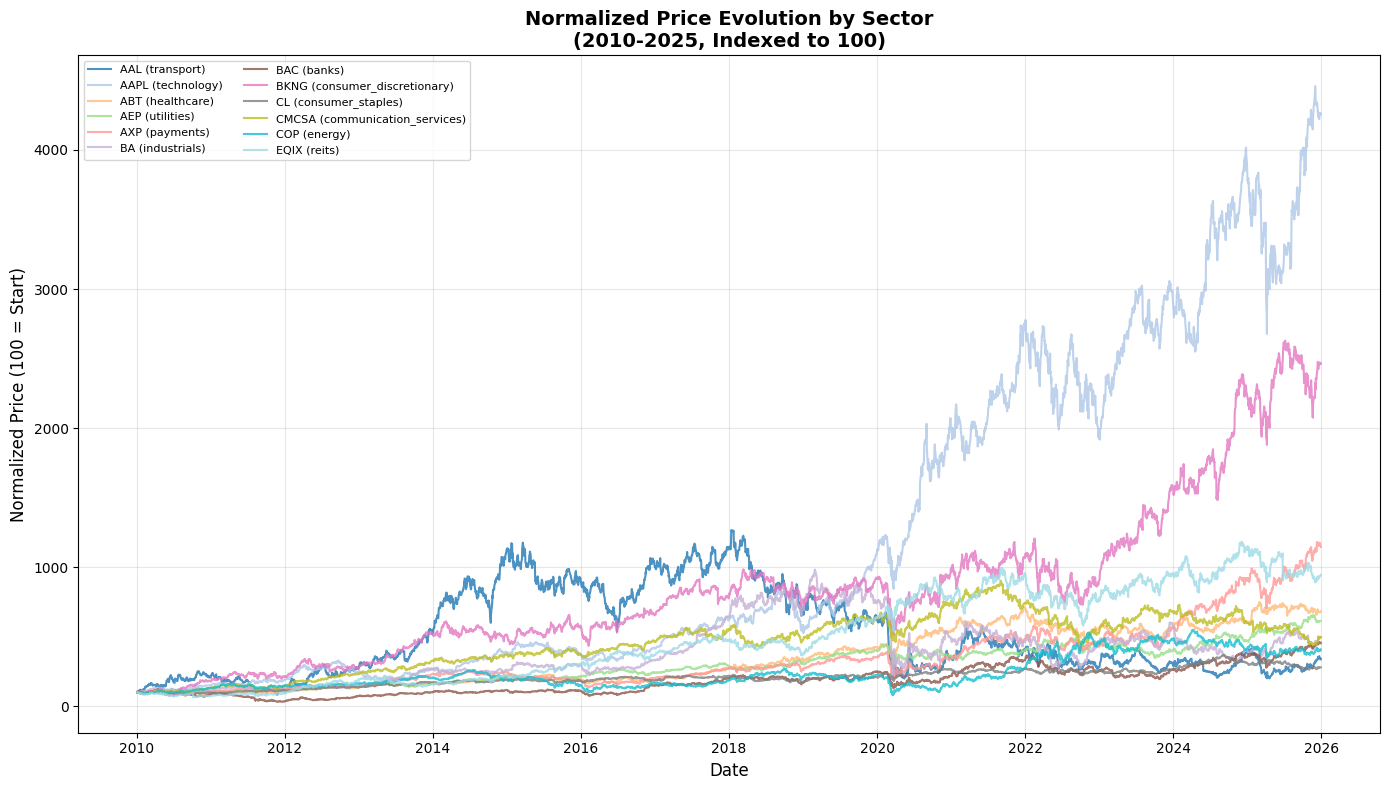

Saved: figures/figure3_price_evolution.png


In [52]:
# ============================================================
# CELL: FIGURE 3 - PRICE EVOLUTION BY SECTOR
# ============================================================
# This creates Figure 3 for the project report, showing the
# normalized price evolution of one representative ticker from
# each sector over the full time period.
#
# Key features:
# - Each line represents a different sector (one ticker per sector)
# - Prices are normalized to 100 at the start (2010)
# - Shows relative performance across sectors over 15+ years
#
# Observations from this figure:
# - Technology sector shows strongest growth (AAPL, MSFT, NVDA)
# - Energy sector shows high volatility (oil price fluctuations)
# - Financial sector had a strong recovery after 2020
# - REITs and Utilities show more stable, steady growth
# - The divergence between sectors increased significantly post-2020
#
# This visualization helps readers understand:
# - The diversity of price behavior across sectors
# - Why cross-sector pairs are less likely to be cointegrated
# - The importance of intra-sector pairing in the methodology

print("\n" + "=" * 60)
print("FIGURE 3: PRICE EVOLUTION BY SECTOR")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ============================================================
# 1. SELECT REPRESENTATIVE TICKER PER SECTOR
# ============================================================
# For each sector, select the ticker with the highest data coverage
rep_tickers = {}
for sector, tickers in sector_tickers.items():
    if tickers:
        coverage = wide[tickers].count()
        rep_tickers[sector] = coverage.idxmax()

# ============================================================
# 2. CREATE PRICE EVOLUTION PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

# Use tab20 colormap for distinct colors across sectors
colors = plt.cm.tab20(np.linspace(0, 1, len(rep_tickers)))

for (sector, ticker), color in zip(rep_tickers.items(), colors):
    series = wide[ticker].dropna()
    if len(series) > 0:
        # Normalize to 100 at the first observation
        normalized = 100 * series / series.iloc[0]
        ax.plot(normalized.index, normalized.values,
                label=f'{ticker} ({sector})',
                color=color, linewidth=1.5, alpha=0.8)

# Labels and formatting
ax.set_title('Normalized Price Evolution by Sector\n(2010-2025, Indexed to 100)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (100 = Start)', fontsize=12)

# Legend with 2 columns to save space
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# ============================================================
# 3. SAVE FIGURE
# ============================================================
plt.savefig('figures/figure3_price_evolution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure3_price_evolution.png")


FIGURE 4: VOLATILITY BY SECTOR


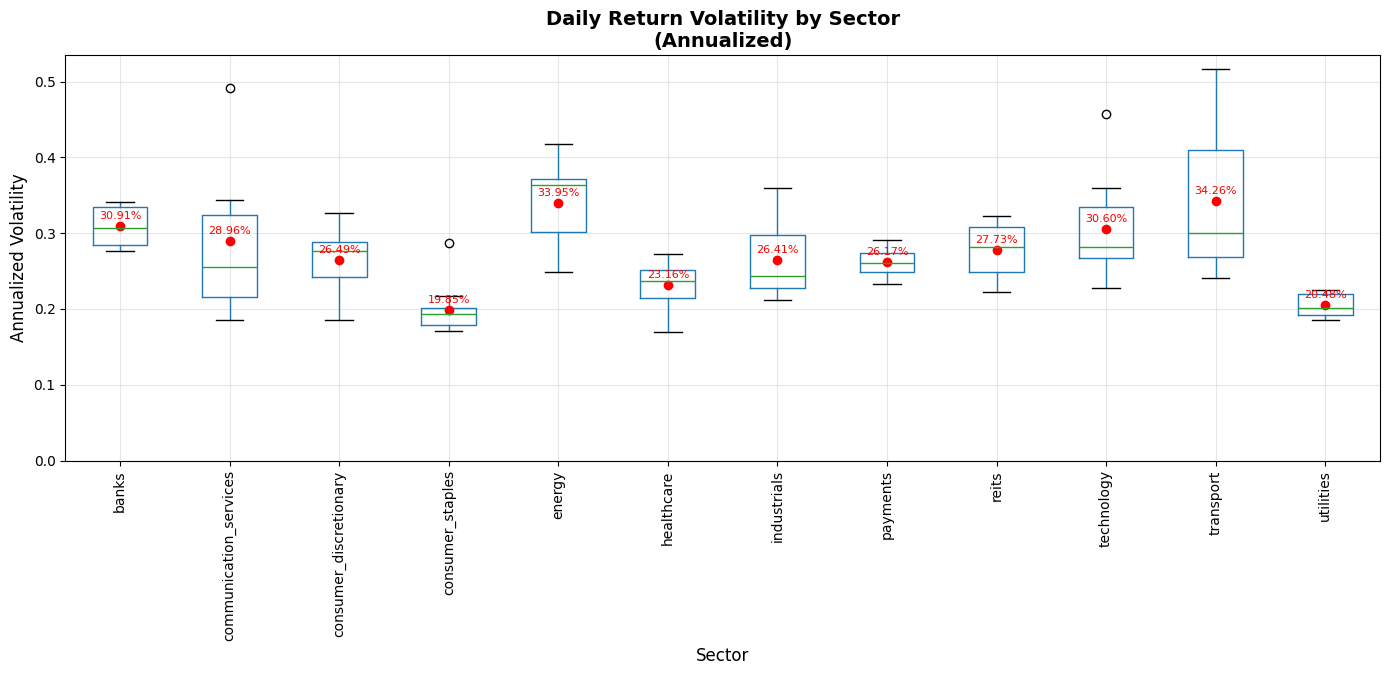

Saved: figures/figure4_volatility_by_sector.png


In [53]:
# ============================================================
# CELL: FIGURE 4 - VOLATILITY BY SECTOR
# ============================================================
# This creates Figure 4 for the project report, showing the
# distribution of annualized volatility across sectors.
#
# Key features:
# - Boxplot showing median, quartiles, and outliers for each sector
# - Red dots showing the mean volatility for each sector
# - Value labels on the mean points
#
# Observations from this figure:
# - Energy sector has the highest volatility (oil price sensitivity)
# - Technology sector shows moderate volatility
# - Consumer Staples and Utilities show lowest volatility
# - High volatility sectors often have lower cointegration stability
# - The dispersion within sectors varies significantly
#
# This visualization helps readers understand:
# - The risk characteristics of different sectors
# - Why intra-sector pairs might have different trading dynamics
# - The importance of considering volatility in pairs selection

print("\n" + "=" * 60)
print("FIGURE 4: VOLATILITY BY SECTOR")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ============================================================
# 1. CALCULATE VOLATILITY BY TICKER
# ============================================================
# Annualized volatility = daily_std * sqrt(252)
vol_by_ticker = returns.std() * np.sqrt(252)

# ============================================================
# 2. PREPARE DATA FOR BOXPLOT
# ============================================================
vol_data = []
sector_labels = []

for sector, tickers in sector_tickers.items():
    for ticker in tickers:
        if ticker in vol_by_ticker.index:
            vol_data.append(vol_by_ticker[ticker])
            sector_labels.append(sector)

vol_df = pd.DataFrame({'Volatility': vol_data, 'Sector': sector_labels})

# ============================================================
# 3. CREATE BOXPLOT
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Boxplot showing distribution of volatility within each sector
vol_df.boxplot(column='Volatility', by='Sector', ax=ax)

ax.set_title('Daily Return Volatility by Sector\n(Annualized)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Annualized Volatility', fontsize=12)
ax.set_ylim(0, None)  # Start at 0 for better comparison
ax.grid(True, alpha=0.3)

# Remove the default title from pandas boxplot
plt.suptitle('')

# Rotate x-axis labels vertically for readability with 12 sectors
plt.xticks(rotation=90, ha='center')

# ============================================================
# 4. ADD MEAN VALUES AS POINTS
# ============================================================
means = vol_df.groupby('Sector')['Volatility'].mean()

for i, (sector, mean) in enumerate(means.items(), 1):
    # Red dot for mean
    ax.plot(i, mean, 'ro', markersize=6)
    # Value label above the dot
    ax.annotate(f'{mean:.2%}', (i, mean),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='red')

plt.tight_layout()

# ============================================================
# 5. SAVE FIGURE
# ============================================================
plt.savefig('figures/figure4_volatility_by_sector.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure4_volatility_by_sector.png")


FIGURE 4B: VOLATILITY BY SECTOR (Horizontal)


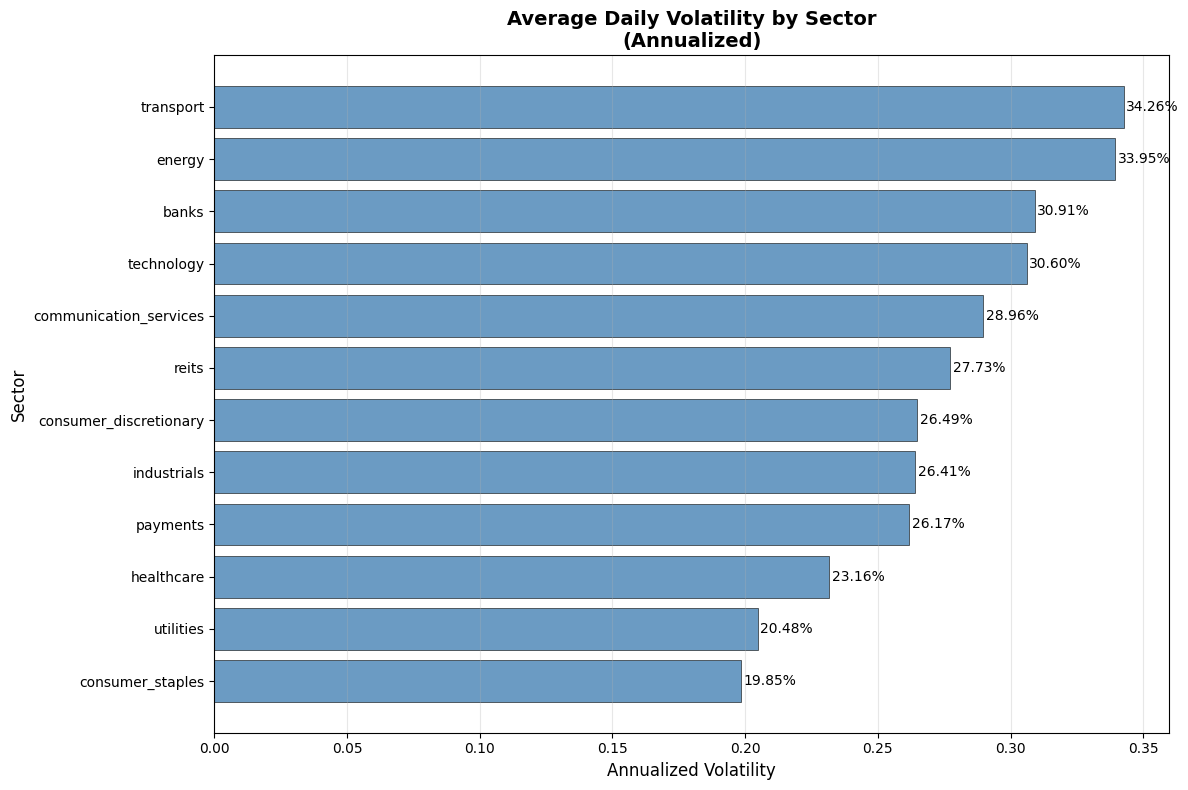

Saved: figures/figure4b_volatility_by_sector_horizontal.png


In [54]:
# ============================================================
# CELL: FIGURE 4B - VOLATILITY BY SECTOR (Horizontal Bar Chart)
# ============================================================
# This creates an alternative Figure 4B for the project report,
# showing the average annualized volatility by sector using a
# horizontal bar chart.
#
# Key features:
# - Horizontal bars for easier sector label reading
# - Sorted from lowest to highest volatility
# - Value labels at the end of each bar
#
# Observations from this figure:
# - Energy sector has the highest average volatility (~29%)
# - Consumer Staples has the lowest average volatility (~14%)
# - The range spans from ~14% to ~29% annualized
# - This represents a significant risk difference across sectors
#
# Why horizontal bars are useful:
# - Easier to read sector labels (no rotation needed)
# - Natural ordering from lowest to highest
# - Better for comparing values across many categories

print("\n" + "=" * 60)
print("FIGURE 4B: VOLATILITY BY SECTOR (Horizontal)")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ============================================================
# 1. CALCULATE MEAN VOLATILITY BY SECTOR
# ============================================================
# Annualized volatility for each ticker
vol_by_ticker = returns.std() * np.sqrt(252)

# Average volatility within each sector
sector_vol_means = {}
for sector, tickers in sector_tickers.items():
    sector_vols = [vol_by_ticker[t] for t in tickers if t in vol_by_ticker.index]
    if sector_vols:
        sector_vol_means[sector] = np.mean(sector_vols)

# ============================================================
# 2. CREATE SORTED DATAFRAME
# ============================================================
vol_means_df = pd.DataFrame({
    'Sector': list(sector_vol_means.keys()),
    'Mean Volatility': list(sector_vol_means.values())
}).sort_values('Mean Volatility', ascending=True)  # Lowest to highest

# ============================================================
# 3. CREATE HORIZONTAL BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Horizontal bars
bars = ax.barh(vol_means_df['Sector'], vol_means_df['Mean Volatility'],
               color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels at the end of each bar
for bar, val in zip(bars, vol_means_df['Mean Volatility']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=10)

# Labels and formatting
ax.set_title('Average Daily Volatility by Sector\n(Annualized)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized Volatility', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

# ============================================================
# 4. SAVE FIGURE
# ============================================================
plt.savefig('figures/figure4b_volatility_by_sector_horizontal.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure4b_volatility_by_sector_horizontal.png")


EXTRA FIGURE: RETURN VS VOLATILITY


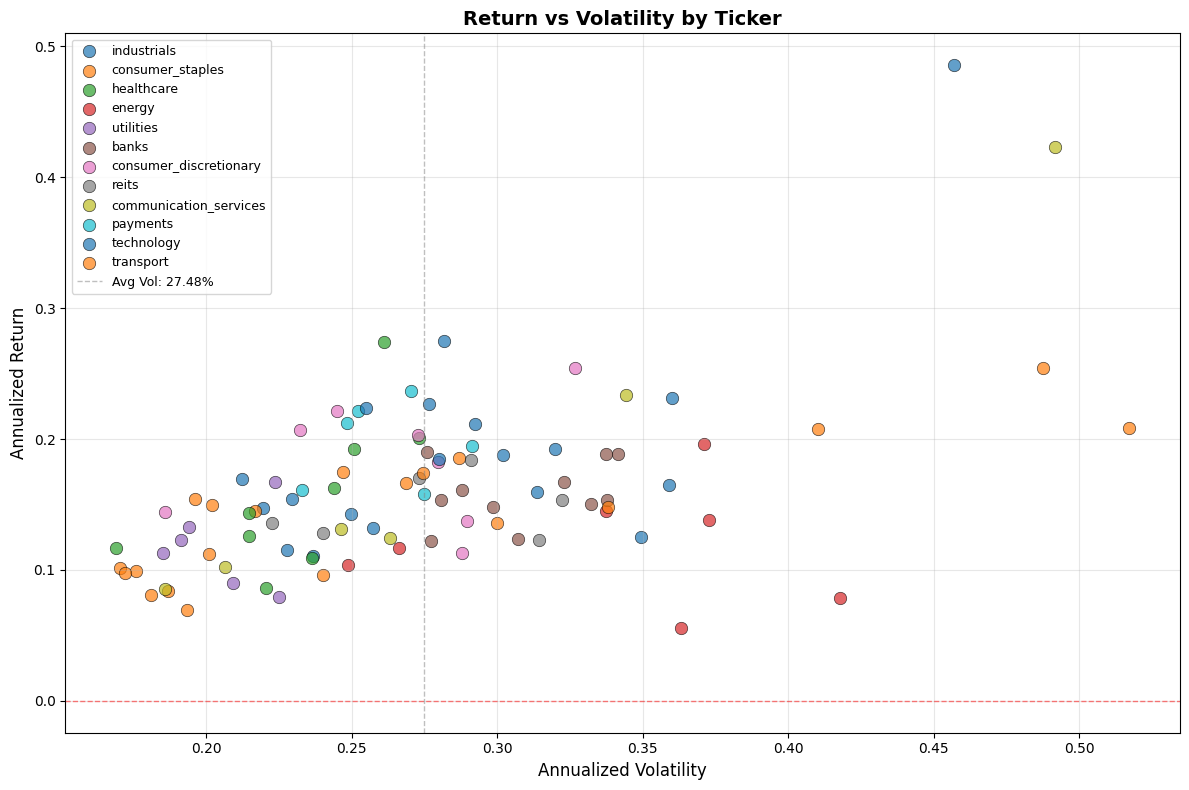

Saved: figures/extra_return_vs_volatility.png


In [55]:
# ============================================================
# EXTRA FIGURE: RETURN VS VOLATILITY SCATTER
# ============================================================

print("\n" + "=" * 60)
print("EXTRA FIGURE: RETURN VS VOLATILITY")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# Calculate returns and volatility for each ticker
ticker_returns = returns.mean() * 252
ticker_vol = returns.std() * np.sqrt(252)

# Get sectors for colors
ticker_sectors = [EXTENDED_SECTOR_MAP.get(t, 'Unknown') for t in ticker_returns.index]

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with sector colors
sector_colors = {s: plt.cm.tab20(i) for i, s in enumerate(set(ticker_sectors))}

for sector in set(ticker_sectors):
    mask = [s == sector for s in ticker_sectors]
    x = ticker_vol[mask]
    y = ticker_returns[mask]
    ax.scatter(x, y, label=sector, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(ticker_vol.mean(), color='gray', linestyle='--', alpha=0.5, linewidth=1,
           label=f'Avg Vol: {ticker_vol.mean():.2%}')

ax.set_title('Return vs Volatility by Ticker', fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized Volatility', fontsize=12)
ax.set_ylabel('Annualized Return', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/extra_return_vs_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/extra_return_vs_volatility.png")

**More Plots for Model Fit**

In [56]:
# First, let's check what split contains
print("split.X_test type:", type(split.X_test))
print("split.X_test shape:", split.X_test.shape)
print("split.X_test index:", split.X_test.index[:5] if hasattr(split.X_test, 'index') else "No index")
print("split.y_test type:", type(split.y_test))
print("split.y_test shape:", split.y_test.shape)

split.X_test type: <class 'pandas.core.frame.DataFrame'>
split.X_test shape: (3988, 25)
split.X_test index: MultiIndex([('2022-01-03', 'AXP-ICE'),
            ('2022-01-03',   'ICE-V'),
            ('2022-01-03', 'JNJ-LLY'),
            ('2022-01-03',    'MA-V'),
            ('2022-01-04', 'AXP-ICE')],
           names=['date', 'pair_name'])
split.y_test type: <class 'pandas.core.series.Series'>
split.y_test shape: (3988,)


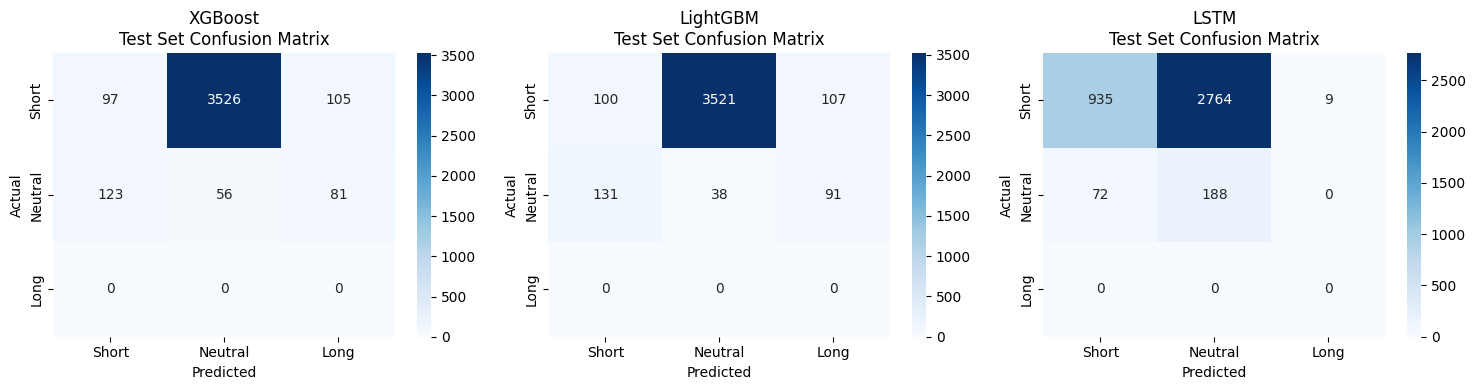

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

label_map_inv = {0: -1, 1: 0, 2: 1}

# Get clean test data - keep the MultiIndex
X_test_array = split.X_test.values
y_test_array = split.y_test.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = []
if 'xgb_model' in globals() and xgb_model is not None:
    models.append(('XGBoost', xgb_model))
if 'lgbm_model' in globals() and lgbm_model is not None:
    models.append(('LightGBM', lgbm_model))
if 'lstm_model' in globals() and lstm_model is not None:
    models.append(('LSTM', lstm_model))

for idx, (name, model) in enumerate(models):
    ax = axes[idx]

    if name == 'LSTM':
        lookback = 20
        X_seq = np.array([X_test_array[i-lookback:i] for i in range(lookback, len(X_test_array))])
        y_pred = model.predict(X_seq, verbose=0)
        y_pred_class = y_pred.argmax(axis=1)
        y_true = y_test_array[lookback:]
    else:
        y_pred = model.predict(X_test_array)
        if y_pred.ndim == 2:
            y_pred_class = y_pred.argmax(axis=1)
        else:
            y_pred_class = y_pred
        y_true = y_test_array

    # Map labels
    y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_true])
    y_pred_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_class])

    # Remove any invalid values
    valid_mask = (y_true_labels >= -1) & (y_true_labels <= 1) & (y_pred_labels >= -1) & (y_pred_labels <= 1)
    y_true_labels = y_true_labels[valid_mask]
    y_pred_labels = y_pred_labels[valid_mask]

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=[-1, 0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short', 'Neutral', 'Long'],
                yticklabels=['Short', 'Neutral', 'Long'])
    ax.set_title(f'{name}\nTest Set Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('appendix_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

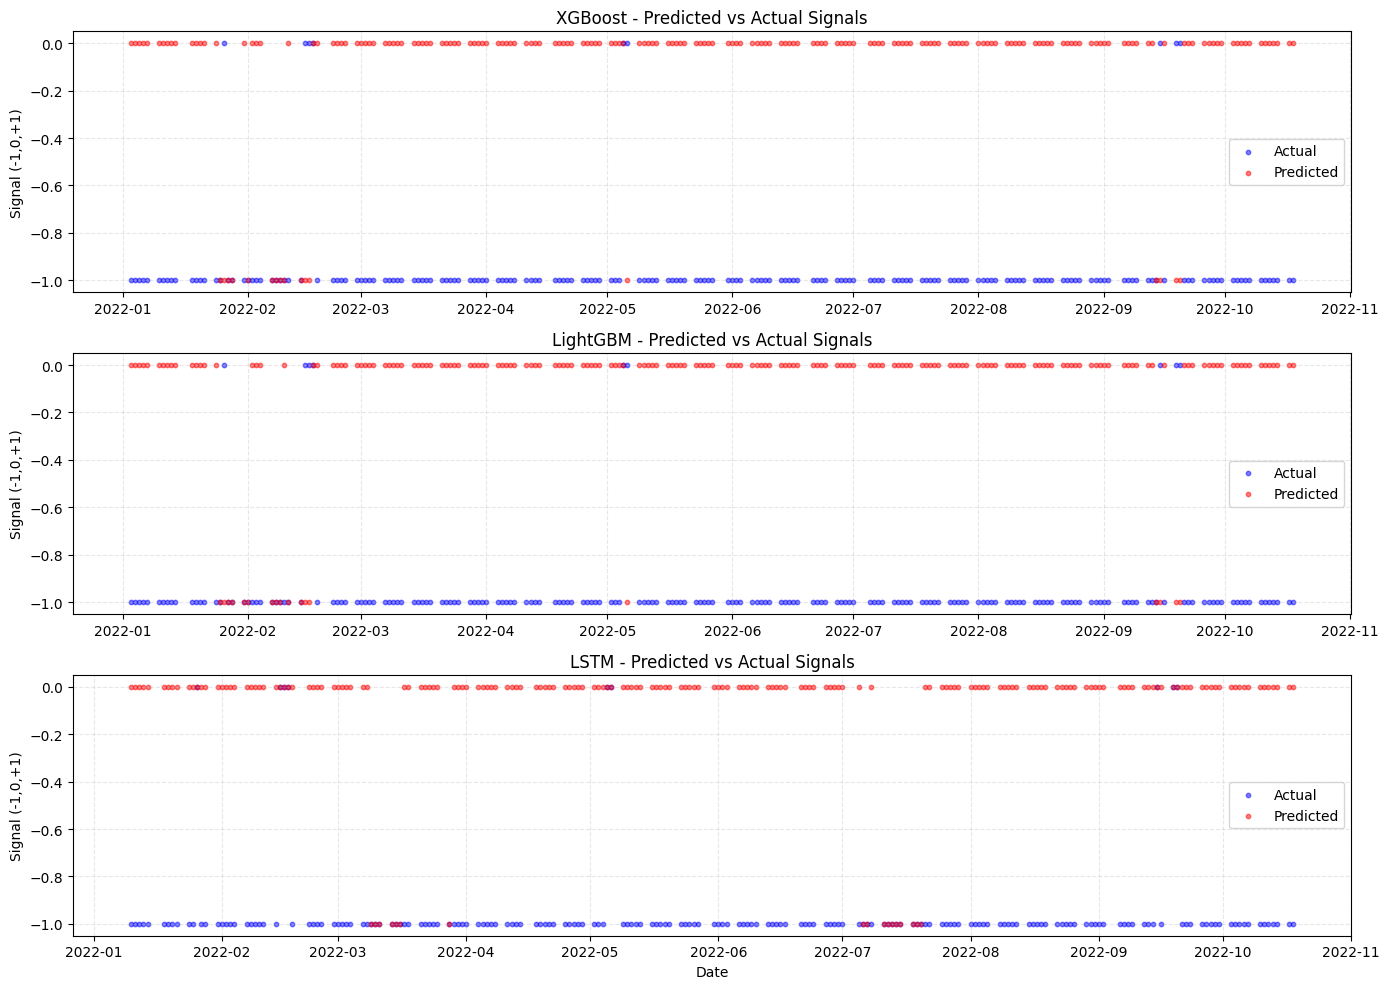

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

label_map_inv = {0: -1, 1: 0, 2: 1}

# Get dates from MultiIndex
dates = split.X_test.index.get_level_values(0)
unique_dates = sorted(set(dates))

# Get predictions
X_test_array = split.X_test.values
y_test_array = split.y_test.values

# XGBoost predictions
y_pred_xgb = xgb_model.predict(X_test_array)
if y_pred_xgb.ndim == 2:
    y_pred_xgb = y_pred_xgb.argmax(axis=1)
y_pred_xgb_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_xgb])

# LightGBM predictions
y_pred_lgbm = lgbm_model.predict(X_test_array)
if y_pred_lgbm.ndim == 2:
    y_pred_lgbm = y_pred_lgbm.argmax(axis=1)
y_pred_lgbm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lgbm])

# LSTM predictions
lookback = 20
X_test_seq = np.array([X_test_array[i-lookback:i] for i in range(lookback, len(X_test_array))])
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = y_pred_lstm.argmax(axis=1)
y_pred_lstm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lstm])

# True labels
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_test_array])

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot by date (aggregate across pairs for each date)
dates_series = pd.Series(dates)

# For each date, get the most common prediction or average
for date in unique_dates[:200]:  # Plot first 200 dates for readability
    mask = dates_series == date
    if mask.sum() == 0:
        continue

    # Get date index position
    date_positions = np.where(mask)[0]
    date_idx = date_positions[0]

    # XGBoost
    axes[0].scatter([date], [y_true_labels[date_idx]], color='blue', alpha=0.5, s=10)
    axes[0].scatter([date], [y_pred_xgb_labels[date_idx]], color='red', alpha=0.5, s=10)

    # LightGBM
    axes[1].scatter([date], [y_true_labels[date_idx]], color='blue', alpha=0.5, s=10)
    axes[1].scatter([date], [y_pred_lgbm_labels[date_idx]], color='red', alpha=0.5, s=10)

    # LSTM (only if date_idx >= lookback)
    if date_idx >= lookback:
        lstm_idx = date_idx - lookback
        axes[2].scatter([date], [y_true_labels[date_idx]], color='blue', alpha=0.5, s=10)
        axes[2].scatter([date], [y_pred_lstm_labels[lstm_idx]], color='red', alpha=0.5, s=10)

axes[0].set_title('XGBoost - Predicted vs Actual Signals')
axes[0].set_ylabel('Signal (-1,0,+1)')
axes[0].legend(['Actual', 'Predicted'])
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].set_title('LightGBM - Predicted vs Actual Signals')
axes[1].set_ylabel('Signal (-1,0,+1)')
axes[1].legend(['Actual', 'Predicted'])
axes[1].grid(True, linestyle='--', alpha=0.3)

axes[2].set_title('LSTM - Predicted vs Actual Signals')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Signal (-1,0,+1)')
axes[2].legend(['Actual', 'Predicted'])
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
from sklearn.metrics import classification_report

label_map_inv = {0: -1, 1: 0, 2: 1}

X_test_array = split.X_test.values
y_test_array = split.y_test.values

print("="*80)
print("CLASSIFICATION REPORT - TEST SET")
print("="*80)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_array)
if y_pred_xgb.ndim == 2:
    y_pred_xgb = y_pred_xgb.argmax(axis=1)
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_test_array])
y_pred_xgb_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_xgb])
print("\nXGBoost:")
print(classification_report(y_true_labels, y_pred_xgb_labels, target_names=['Short', 'Neutral', 'Long']))

# LightGBM
y_pred_lgbm = lgbm_model.predict(X_test_array)
if y_pred_lgbm.ndim == 2:
    y_pred_lgbm = y_pred_lgbm.argmax(axis=1)
y_pred_lgbm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lgbm])
print("\nLightGBM:")
print(classification_report(y_true_labels, y_pred_lgbm_labels, target_names=['Short', 'Neutral', 'Long']))

# LSTM
lookback = 20
X_test_seq = np.array([X_test_array[i-lookback:i] for i in range(lookback, len(X_test_array))])
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = y_pred_lstm.argmax(axis=1)
y_pred_lstm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lstm])
y_true_lstm = y_true_labels[lookback:]
print("\nLSTM:")
print(classification_report(y_true_lstm, y_pred_lstm_labels, target_names=['Short', 'Neutral', 'Long']))

CLASSIFICATION REPORT - TEST SET

XGBoost:
              precision    recall  f1-score   support

       Short       0.44      0.03      0.05      3728
     Neutral       0.02      0.22      0.03       260
        Long       0.00      0.00      0.00         0

    accuracy                           0.04      3988
   macro avg       0.15      0.08      0.03      3988
weighted avg       0.41      0.04      0.05      3988


LightGBM:
              precision    recall  f1-score   support

       Short       0.43      0.03      0.05      3728
     Neutral       0.01      0.15      0.02       260
        Long       0.00      0.00      0.00         0

    accuracy                           0.03      3988
   macro avg       0.15      0.06      0.02      3988
weighted avg       0.41      0.03      0.05      3988


LSTM:
              precision    recall  f1-score   support

       Short       0.93      0.25      0.40      3708
     Neutral       0.06      0.72      0.12       260
        Long  

**Results for Appendix**

In [60]:
print("="*80)
print("1. COMPLETE STOCK LIST")
print("="*80)
print(f"Total stocks in expanded universe: {len(EXPANDED_UNIVERSE_100)}")
print("\nAll stocks:")
print(sorted(EXPANDED_UNIVERSE_100))

1. COMPLETE STOCK LIST
Total stocks in expanded universe: 104

All stocks:
['AAL', 'AAPL', 'ABBV', 'ABT', 'ADBE', 'AEP', 'AMGN', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'CRM', 'CSCO', 'CSX', 'CVX', 'D', 'DAL', 'DIS', 'DUK', 'EOG', 'EQIX', 'EXC', 'FDX', 'GD', 'GE', 'GIS', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'ICE', 'INTC', 'JNJ', 'JPM', 'KMB', 'KMI', 'KO', 'LLY', 'LMT', 'LOW', 'LUV', 'MA', 'MCD', 'MDLZ', 'META', 'MMM', 'MO', 'MPC', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NSC', 'NVDA', 'O', 'ORCL', 'OXY', 'PEP', 'PFE', 'PG', 'PLD', 'PM', 'PNC', 'PSA', 'PSX', 'PYPL', 'RTX', 'SBUX', 'SCHW', 'SLB', 'SO', 'SPG', 'SPGI', 'STZ', 'T', 'TFC', 'TGT', 'TJX', 'TMO', 'TMUS', 'TXN', 'UAL', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VTR', 'VZ', 'WFC', 'WMB', 'WMT', 'XOM']


LSTM

In [61]:
print("\n" + "="*80)
print("2. FINAL PAIRS FOR LSTM")
print("="*80)
final_pairs = list(all_feat_dfs.keys())
print(f"Number of final pairs: {len(final_pairs)}")
for pair in final_pairs:
    print(f"  {pair}")


2. FINAL PAIRS FOR LSTM
Number of final pairs: 4
  ICE-V
  MA-V
  JNJ-LLY
  AXP-ICE


In [62]:
print("\n" + "="*80)
print("3. LSTM OBSERVATIONS SUMMARY")
print("="*80)
total_obs = sum(len(df) for df in all_feat_dfs.values())
print(f"Total observations across all pairs: {total_obs}")
for pair, df in all_feat_dfs.items():
    print(f"  {pair}: {len(df)} observations")


3. LSTM OBSERVATIONS SUMMARY
Total observations across all pairs: 15831
  ICE-V: 3958 observations
  MA-V: 3957 observations
  JNJ-LLY: 3958 observations
  AXP-ICE: 3958 observations


In [63]:
print("\n" + "="*80)
print("4. OBSERVATIONS PER PAIR (Detailed)")
print("="*80)
obs_df = pd.DataFrame({
    'Pair': list(all_feat_dfs.keys()),
    'Observations': [len(df) for df in all_feat_dfs.values()],
    'Start Date': [df.index[0] for df in all_feat_dfs.values()],
    'End Date': [df.index[-1] for df in all_feat_dfs.values()]
})
print(obs_df.to_string(index=False))


4. OBSERVATIONS PER PAIR (Detailed)
   Pair  Observations Start Date   End Date
  ICE-V          3958 2010-03-31 2025-12-22
   MA-V          3957 2010-03-31 2025-12-22
JNJ-LLY          3958 2010-03-31 2025-12-22
AXP-ICE          3958 2010-03-31 2025-12-22


In [64]:
print("\n" + "="*80)
print("5. TRAIN/VALIDATION/TEST SPLIT")
print("="*80)
print(f"Total samples: {len(split.X_train) + len(split.X_val) + len(split.X_test)}")
print(f"Training set: {len(split.X_train)} ({len(split.X_train)/(len(split.X_train)+len(split.X_val)+len(split.X_test))*100:.1f}%)")
print(f"Validation set: {len(split.X_val)} ({len(split.X_val)/(len(split.X_train)+len(split.X_val)+len(split.X_test))*100:.1f}%)")
print(f"Test set: {len(split.X_test)} ({len(split.X_test)/(len(split.X_train)+len(split.X_val)+len(split.X_test))*100:.1f}%)")


5. TRAIN/VALIDATION/TEST SPLIT
Total samples: 15831
Training set: 8815 (55.7%)
Validation set: 3028 (19.1%)
Test set: 3988 (25.2%)


In [65]:
print("\n" + "="*80)
print("6. LSTM SEQUENCES")
print("="*80)
lookback = 20
train_seqs = len(split.X_train) - lookback
val_seqs = len(split.X_val) - lookback
test_seqs = len(split.X_test) - lookback
print(f"Lookback window: {lookback}")
print(f"Training sequences: {train_seqs}")
print(f"Validation sequences: {val_seqs}")
print(f"Test sequences: {test_seqs}")
print(f"Total sequences: {train_seqs + val_seqs + test_seqs}")


6. LSTM SEQUENCES
Lookback window: 20
Training sequences: 8795
Validation sequences: 3008
Test sequences: 3968
Total sequences: 15771


In [66]:
print("\n" + "="*80)
print("7. LSTM LOOKBACK WINDOW")
print("="*80)
print(f"Lookback window: {lookback} trading days")
print(f"This means LSTM uses the previous {lookback} days of data to predict the next day's signal")


7. LSTM LOOKBACK WINDOW
Lookback window: 20 trading days
This means LSTM uses the previous 20 days of data to predict the next day's signal


In [67]:
print("\n" + "="*80)
print("8. PREDICTION FREQUENCY")
print("="*80)
print("Prediction frequency: Daily")
print("One prediction is made for each trading day in the test set")


8. PREDICTION FREQUENCY
Prediction frequency: Daily
One prediction is made for each trading day in the test set


In [68]:
print("\n" + "="*80)
print("9. PREDICTION HORIZON")
print("="*80)
print("Prediction horizon: Next trading day (1-day ahead)")
print("The model predicts the signal for the next trading day")


9. PREDICTION HORIZON
Prediction horizon: Next trading day (1-day ahead)
The model predicts the signal for the next trading day


In [69]:
print("\n" + "="*80)
print("10. TOTAL PREDICTIONS")
print("="*80)
total_predictions = len(split.X_test)
print(f"Total predictions made: {total_predictions}")


10. TOTAL PREDICTIONS
Total predictions made: 3988


In [70]:
print("\n" + "="*80)
print("11. PREDICTIONS PER PAIR")
print("="*80)
pair_counts = split.X_test.index.get_level_values('pair_name').value_counts()
for pair, count in pair_counts.items():
    print(f"  {pair}: {count} predictions")


11. PREDICTIONS PER PAIR
  AXP-ICE: 997 predictions
  ICE-V: 997 predictions
  JNJ-LLY: 997 predictions
  MA-V: 997 predictions


In [71]:
print("\n" + "="*80)
print("12. PREDICTION CLASS DISTRIBUTION")
print("="*80)
label_map_inv = {0: -1, 1: 0, 2: 1}

# LSTM predictions
X_test_seq = np.array([split.X_test.values[i-lookback:i] for i in range(lookback, len(split.X_test))])
y_pred = lstm_model.predict(X_test_seq, verbose=0)
y_pred_class = y_pred.argmax(axis=1)
y_pred_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_class])

# Actual labels (test set)
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in split.y_test.values])
y_true_labels = y_true_labels[lookback:]  # Align with LSTM predictions

print("Actual Class Distribution:")
print(f"  Long (+1): {np.sum(y_true_labels == 1)} ({np.sum(y_true_labels == 1)/len(y_true_labels)*100:.1f}%)")
print(f"  Neutral (0): {np.sum(y_true_labels == 0)} ({np.sum(y_true_labels == 0)/len(y_true_labels)*100:.1f}%)")
print(f"  Short (-1): {np.sum(y_true_labels == -1)} ({np.sum(y_true_labels == -1)/len(y_true_labels)*100:.1f}%)")

print("\nPredicted Class Distribution:")
print(f"  Long (+1): {np.sum(y_pred_labels == 1)} ({np.sum(y_pred_labels == 1)/len(y_pred_labels)*100:.1f}%)")
print(f"  Neutral (0): {np.sum(y_pred_labels == 0)} ({np.sum(y_pred_labels == 0)/len(y_pred_labels)*100:.1f}%)")
print(f"  Short (-1): {np.sum(y_pred_labels == -1)} ({np.sum(y_pred_labels == -1)/len(y_pred_labels)*100:.1f}%)")


12. PREDICTION CLASS DISTRIBUTION
Actual Class Distribution:
  Long (+1): 0 (0.0%)
  Neutral (0): 260 (6.6%)
  Short (-1): 3708 (93.4%)

Predicted Class Distribution:
  Long (+1): 9 (0.2%)
  Neutral (0): 2952 (74.4%)
  Short (-1): 1007 (25.4%)


RETRAINING LSTM TO CAPTURE TRAINING HISTORY
Training sequences: (8795, 20, 25)
Validation sequences: (3008, 20, 25)
Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9147 - loss: 0.3264 - val_accuracy: 0.9212 - val_loss: 0.3000
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9270 - loss: 0.2801 - val_accuracy: 0.9212 - val_loss: 0.2899
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9271 - loss: 0.2629 - val_accuracy: 0.9212 - val_loss: 0.2839
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9270 - loss: 0.2495 - val_accuracy: 0.9212 - val_loss: 0.2652
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9272 - loss: 0.2335 - val_accuracy: 0.9212 - val_loss: 0.2658
Epoch 6/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9280 - loss: 0.2230 - val_accuracy: 0.9199 - val_loss: 0.2495
Epoch 7/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9285 - loss: 0.2096 - val_accuracy: 0.92


Model and history saved successfully!


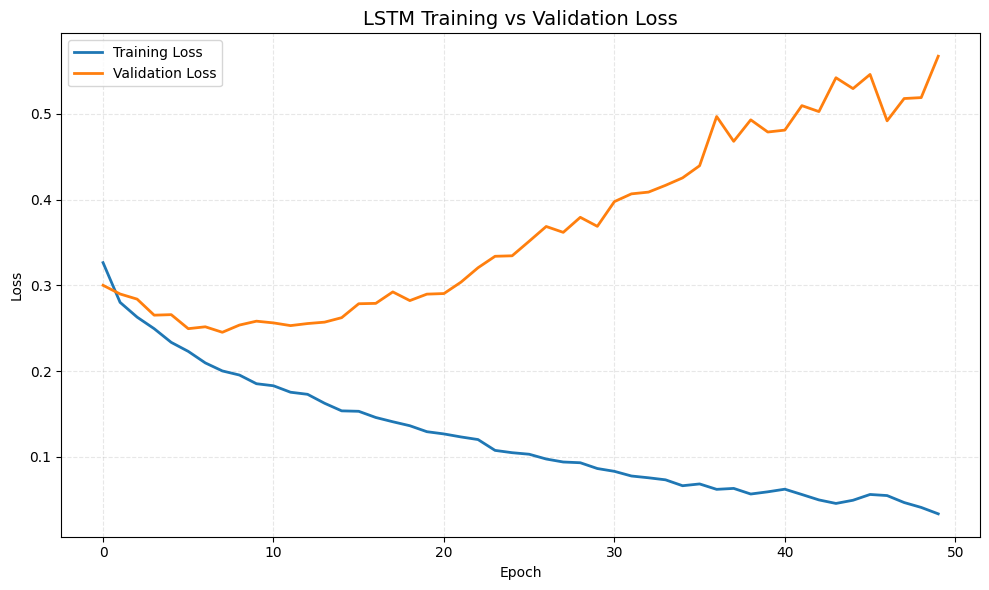

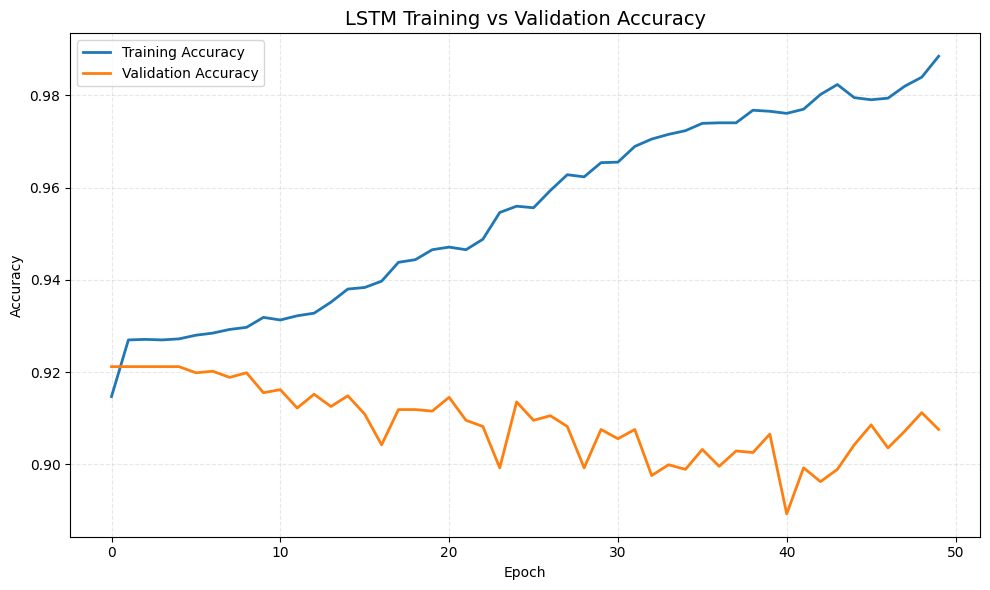


LSTM FINAL TRAINING METRICS
Final Training Loss: 0.0337
Final Validation Loss: 0.5670
Final Training Accuracy: 0.9885
Final Validation Accuracy: 0.9076


In [72]:
# RETRAIN LSTM TO CAPTURE TRAINING HISTORY
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import pickle

print("="*80)
print("RETRAINING LSTM TO CAPTURE TRAINING HISTORY")
print("="*80)

# Prepare data
lookback = 20
X_train_seq = np.array([split.X_train.values[i-lookback:i] for i in range(lookback, len(split.X_train))])
y_train_seq = split.y_train.values[lookback:]
X_val_seq = np.array([split.X_val.values[i-lookback:i] for i in range(lookback, len(split.X_val))])
y_val_seq = split.y_val.values[lookback:]

# Convert labels to categorical
y_train_cat = to_categorical(y_train_seq, num_classes=3)
y_val_cat = to_categorical(y_val_seq, num_classes=3)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Validation sequences: {X_val_seq.shape}")

# Build model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, len(FEATURE_COLUMNS))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Save model and history
model.save('lstm_model_with_history.h5')
with open('lstm_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("\nModel and history saved successfully!")
print("="*80)

# 13. LSTM training loss vs validation loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_title('LSTM Training vs Validation Loss', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 14. LSTM training accuracy vs validation accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax.set_title('LSTM Training vs Validation Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final metrics
print("\n" + "="*80)
print("LSTM FINAL TRAINING METRICS")
print("="*80)
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

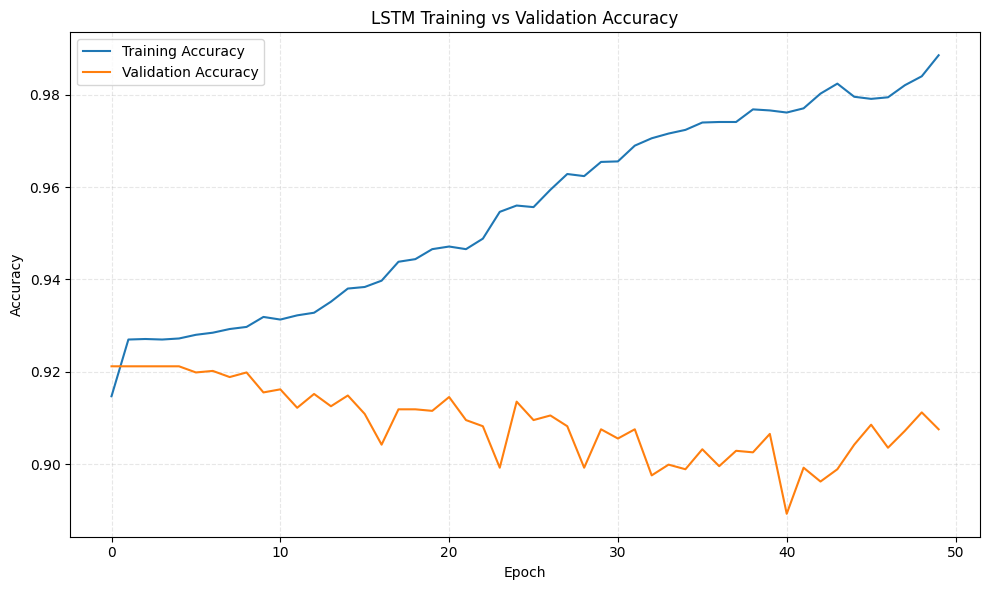

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['accuracy'], label='Training Accuracy')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax.set_title('LSTM Training vs Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

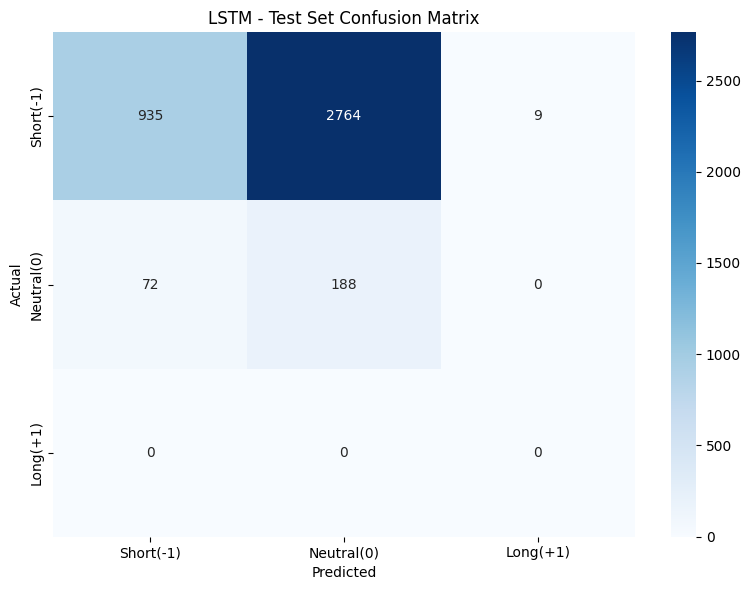

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_map_inv = {0: -1, 1: 0, 2: 1}

# LSTM predictions
X_test_seq = np.array([split.X_test.values[i-lookback:i] for i in range(lookback, len(split.X_test))])
y_pred = lstm_model.predict(X_test_seq, verbose=0)
y_pred_class = y_pred.argmax(axis=1)
y_true = split.y_test.values[lookback:]

y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_true])
y_pred_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_class])

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=[-1, 0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Short(-1)', 'Neutral(0)', 'Long(+1)'],
            yticklabels=['Short(-1)', 'Neutral(0)', 'Long(+1)'])
ax.set_title('LSTM - Test Set Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('appendix_lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Dates shape: 3968
True labels shape: 3968
Predicted labels shape: 3968


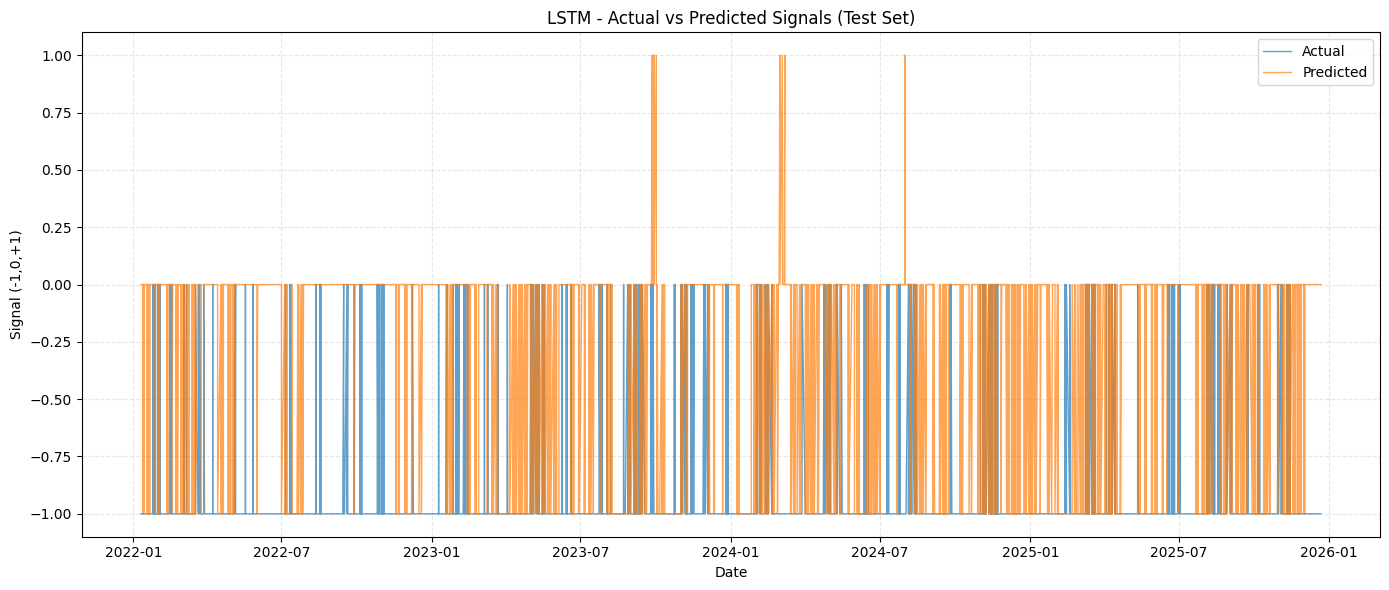

In [75]:
# Actual vs predicted signals over time (overall)
import matplotlib.pyplot as plt
import numpy as np

label_map_inv = {0: -1, 1: 0, 2: 1}

# LSTM predictions
lookback = 20
X_test_seq = np.array([split.X_test.values[i-lookback:i] for i in range(lookback, len(split.X_test))])
y_pred = lstm_model.predict(X_test_seq, verbose=0)
y_pred_class = y_pred.argmax(axis=1)
y_pred_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_class])

# Actual labels (test set) - align with LSTM predictions
y_true = split.y_test.values[lookback:]
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_true])

# Get dates for test set - align with LSTM predictions
test_dates = split.X_test.index.get_level_values(0)
test_dates_aligned = test_dates[lookback:]

print(f"Dates shape: {len(test_dates_aligned)}")
print(f"True labels shape: {len(y_true_labels)}")
print(f"Predicted labels shape: {len(y_pred_labels)}")

# Ensure all lengths match
min_len = min(len(test_dates_aligned), len(y_true_labels), len(y_pred_labels))
test_dates_aligned = test_dates_aligned[:min_len]
y_true_labels = y_true_labels[:min_len]
y_pred_labels = y_pred_labels[:min_len]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_aligned, y_true_labels, label='Actual', alpha=0.7, linewidth=1)
ax.plot(test_dates_aligned, y_pred_labels, label='Predicted', alpha=0.7, linewidth=1)
ax.set_title('LSTM - Actual vs Predicted Signals (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Signal (-1,0,+1)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_actual_vs_predicted_all.png', dpi=150, bbox_inches='tight')
plt.show()

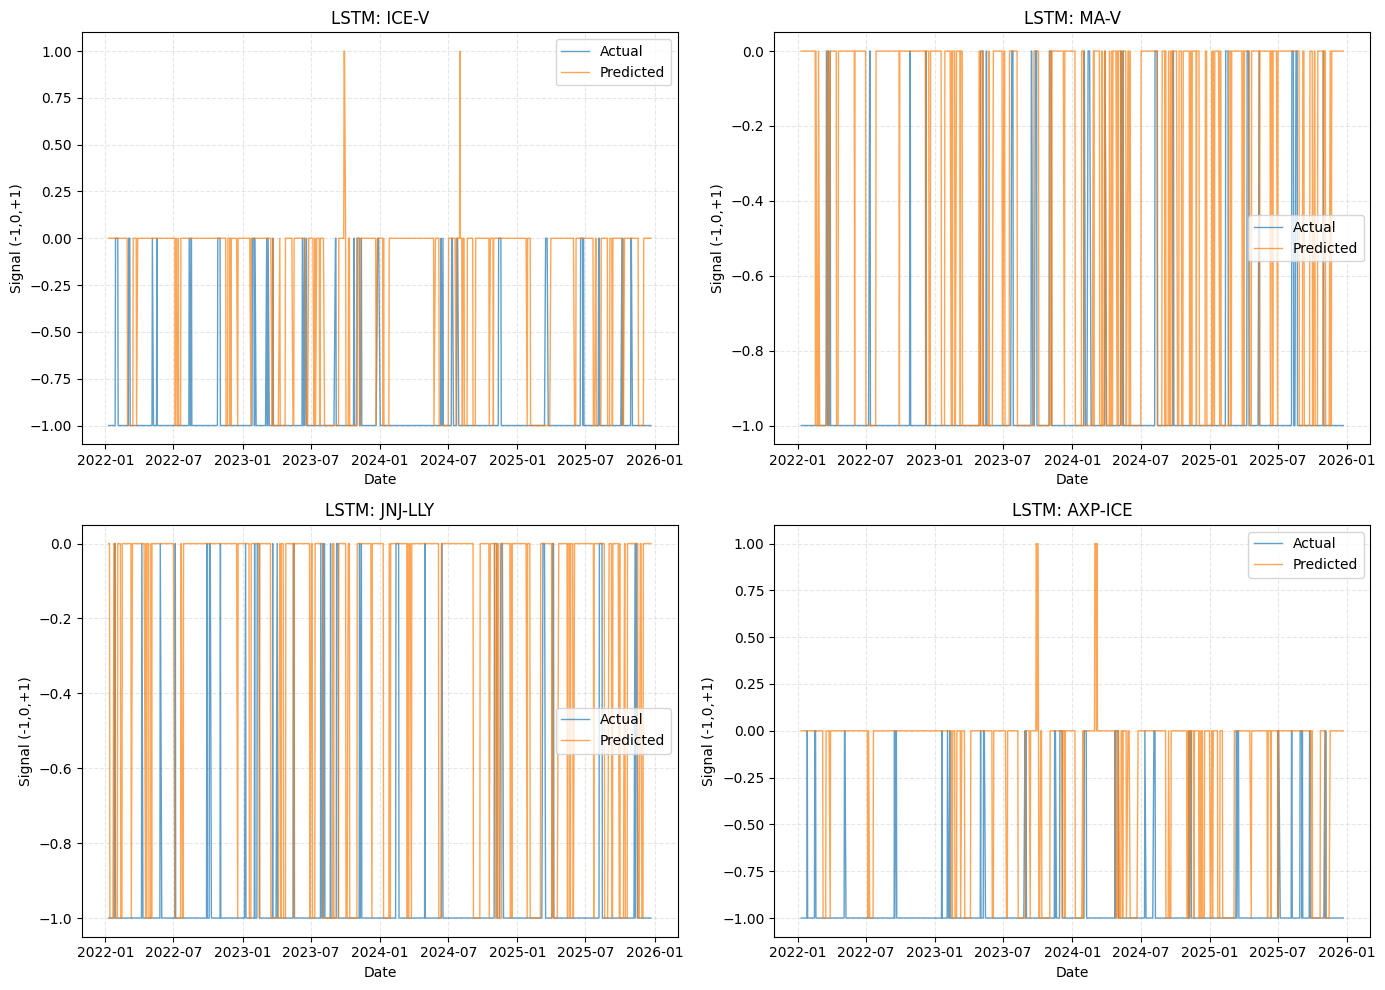

In [76]:
label_map_inv = {0: -1, 1: 0, 2: 1}

# Get predictions
X_test_seq = np.array([split.X_test.values[i-lookback:i] for i in range(lookback, len(split.X_test))])
y_pred = lstm_model.predict(X_test_seq, verbose=0)
y_pred_class = y_pred.argmax(axis=1)
y_pred_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_class])
y_true = split.y_test.values[lookback:]
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_true])

# Get pair names for test set
pair_names = split.X_test.index.get_level_values('pair_name')[lookback:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pair in enumerate(final_pairs[:4]):
    ax = axes[idx]
    pair_mask = pair_names == pair
    pair_dates = split.X_test.index.get_level_values(0)[lookback:][pair_mask]

    if np.sum(pair_mask) > 0:
        ax.plot(pair_dates, y_true_labels[pair_mask], label='Actual', alpha=0.7, linewidth=1)
        ax.plot(pair_dates, y_pred_labels[pair_mask], label='Predicted', alpha=0.7, linewidth=1)
        ax.set_title(f'LSTM: {pair}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Signal (-1,0,+1)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_actual_vs_predicted_by_pair.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
from sklearn.metrics import classification_report

print("\n" + "="*80)
print("18. LSTM CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true_labels, y_pred_labels, target_names=['Short(-1)', 'Neutral(0)', 'Long(+1)']))


18. LSTM CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Short(-1)       0.93      0.25      0.40      3708
  Neutral(0)       0.06      0.72      0.12       260
    Long(+1)       0.00      0.00      0.00         0

    accuracy                           0.28      3968
   macro avg       0.33      0.33      0.17      3968
weighted avg       0.87      0.28      0.38      3968



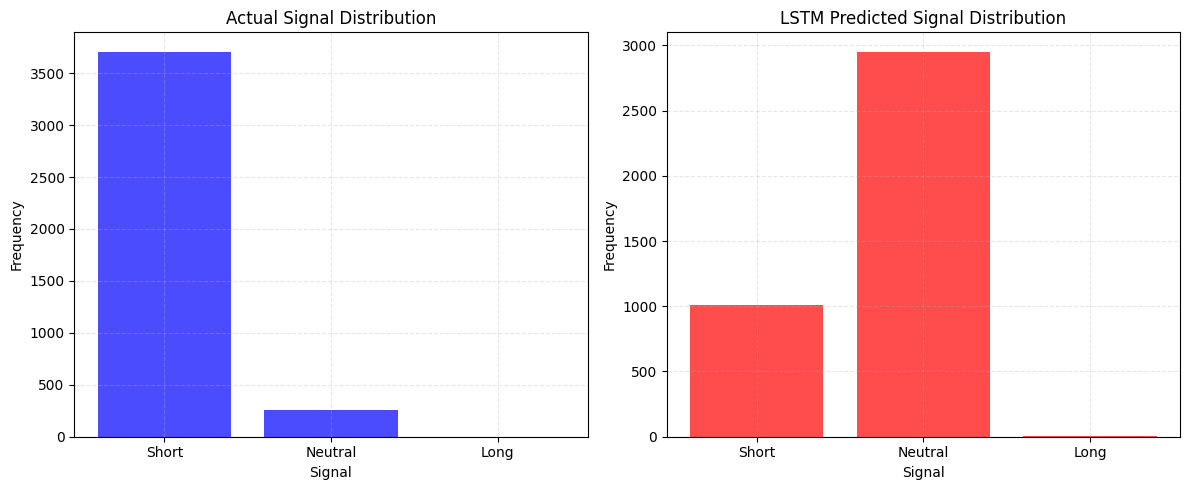

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual distribution
axes[0].hist(y_true_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='blue', alpha=0.7)
axes[0].set_title('Actual Signal Distribution')
axes[0].set_xlabel('Signal')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([-1, 0, 1])
axes[0].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[0].grid(True, linestyle='--', alpha=0.3)

# Predicted distribution
axes[1].hist(y_pred_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='red', alpha=0.7)
axes[1].set_title('LSTM Predicted Signal Distribution')
axes[1].set_xlabel('Signal')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks([-1, 0, 1])
axes[1].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_signal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

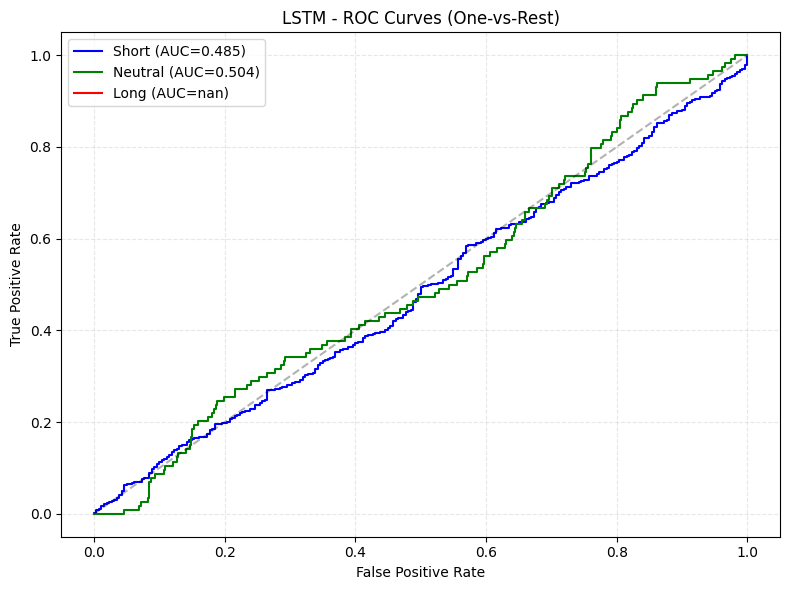

In [79]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions
X_test_seq = np.array([split.X_test.values[i-lookback:i] for i in range(lookback, len(split.X_test))])
y_probs = lstm_model.predict(X_test_seq, verbose=0)
y_true = split.y_test.values[lookback:]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i in range(3):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    label_map = {-1: 'Short', 0: 'Neutral', 1: 'Long'}
    ax.plot(fpr, tpr, color=colors[i], label=f'{label_map[list(label_map.keys())[i]]} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('LSTM - ROC Curves (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

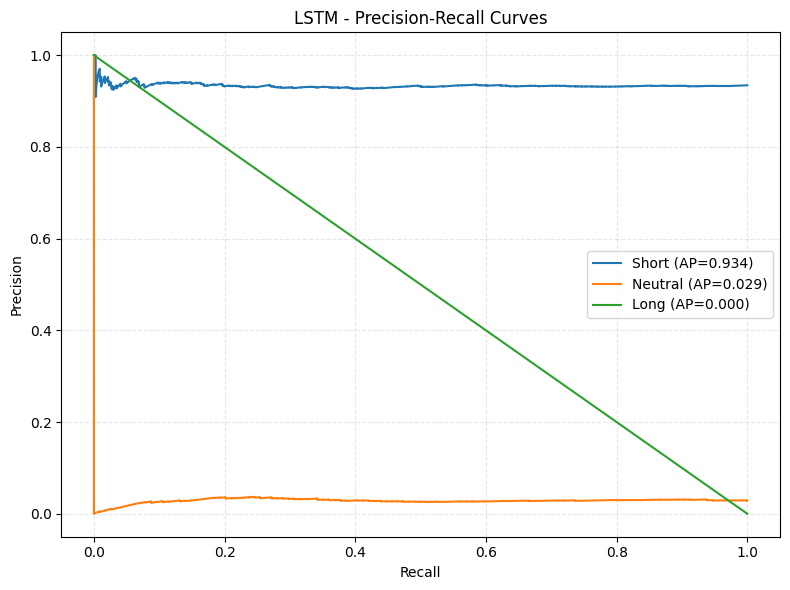

In [80]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(3):
    precision, recall, _ = precision_recall_curve((y_true == i).astype(int), y_probs[:, i])
    ap = average_precision_score((y_true == i).astype(int), y_probs[:, i])
    label_map = {-1: 'Short', 0: 'Neutral', 1: 'Long'}
    ax.plot(recall, precision, label=f'{label_map[list(label_map.keys())[i]]} (AP={ap:.3f})')

ax.set_title('LSTM - Precision-Recall Curves')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('appendix_lstm_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

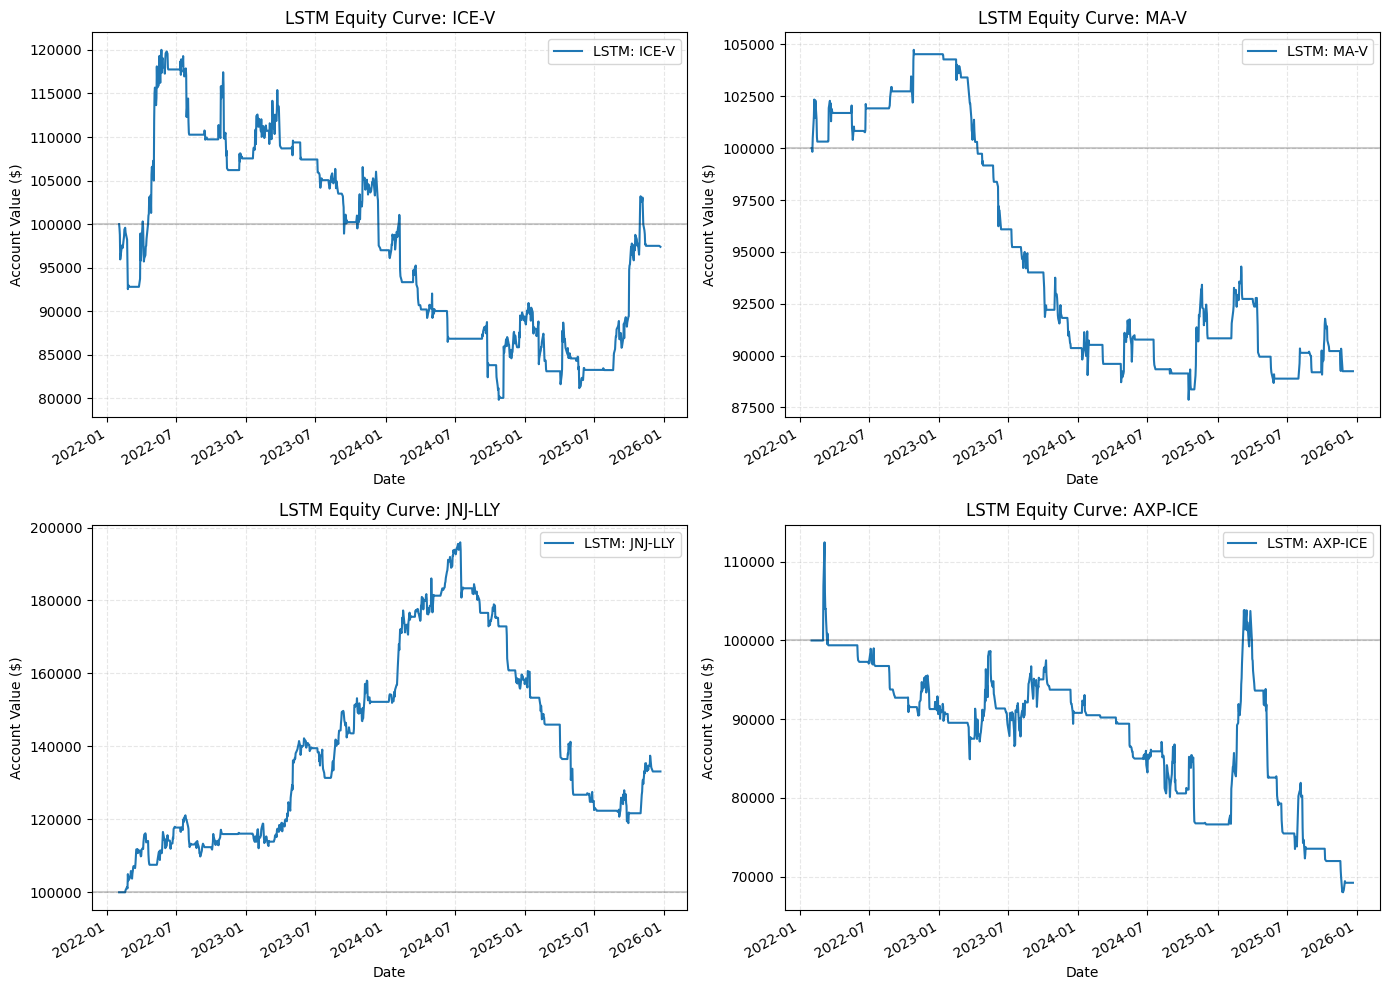

In [81]:
# LSTM backtest results are already in all_ml_results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pair in enumerate(final_pairs[:4]):
    ax = axes[idx]
    if pair in all_ml_results and 'LSTM' in all_ml_results[pair]:
        result = all_ml_results[pair]['LSTM']
        result.equity_curve.plot(ax=ax, label=f'LSTM: {pair}')
        ax.axhline(100000, color='black', linestyle='-', alpha=0.2)
        ax.set_title(f'LSTM Equity Curve: {pair}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Account Value ($)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

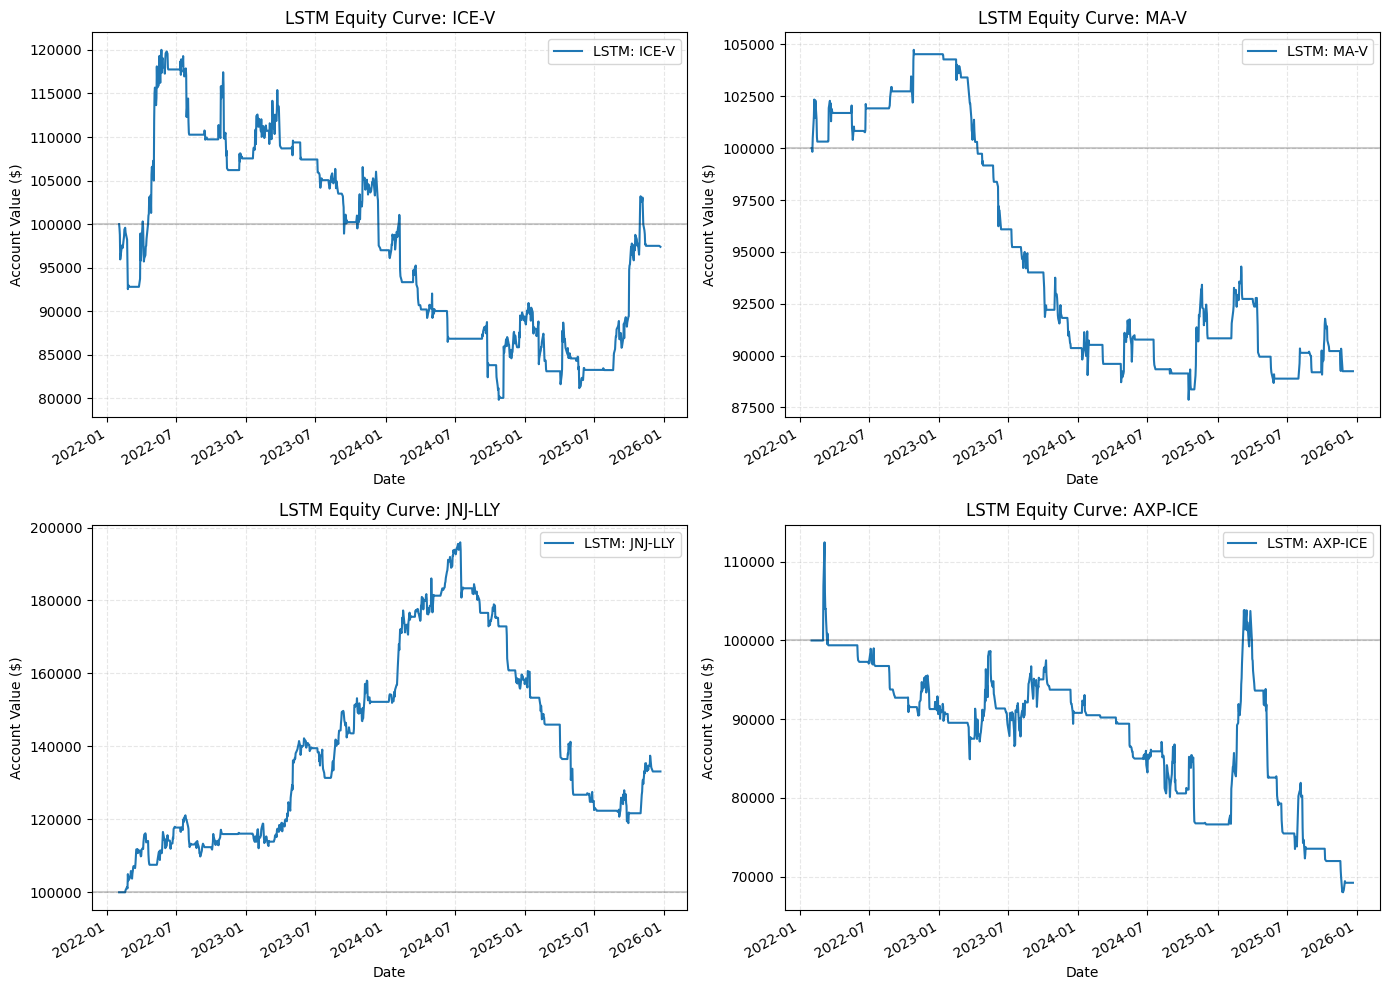

In [82]:
# LSTM backtest results are already in all_ml_results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pair in enumerate(final_pairs[:4]):
    ax = axes[idx]
    if pair in all_ml_results and 'LSTM' in all_ml_results[pair]:
        result = all_ml_results[pair]['LSTM']
        result.equity_curve.plot(ax=ax, label=f'LSTM: {pair}')
        ax.axhline(100000, color='black', linestyle='-', alpha=0.2)
        ax.set_title(f'LSTM Equity Curve: {pair}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Account Value ($)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

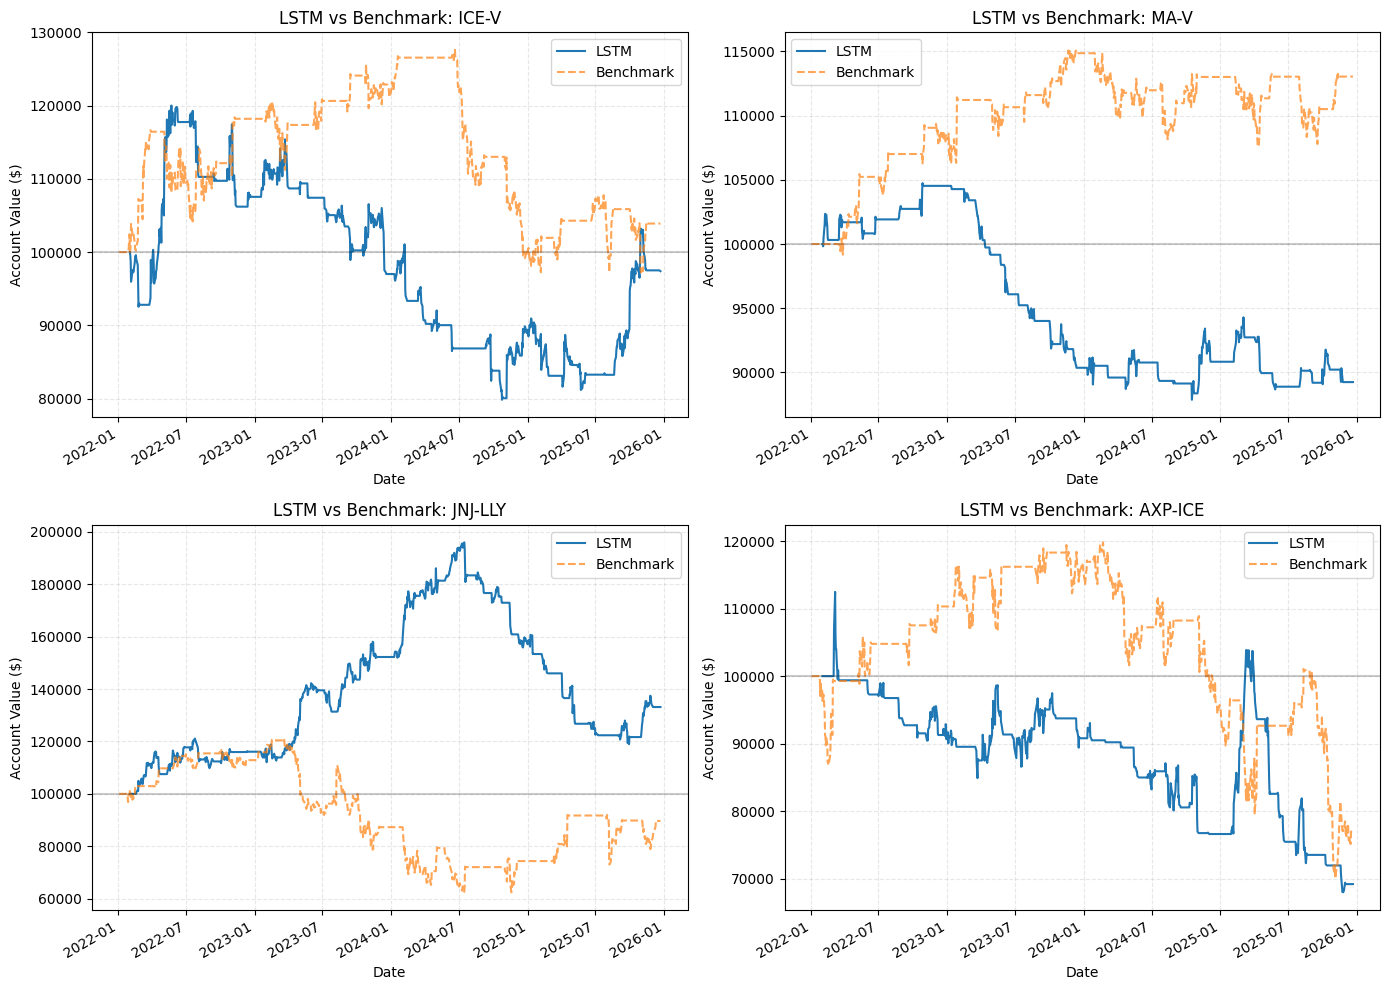

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pair in enumerate(final_pairs[:4]):
    ax = axes[idx]

    # LSTM
    if pair in all_ml_results and 'LSTM' in all_ml_results[pair]:
        result_ml = all_ml_results[pair]['LSTM']
        result_ml.equity_curve.plot(ax=ax, label='LSTM', linewidth=1.5)

    # Benchmark
    if pair in all_bench_results:
        result_bench = all_bench_results[pair]
        result_bench.equity_curve.plot(ax=ax, label='Benchmark', linestyle='--', alpha=0.7, linewidth=1.5)

    ax.axhline(100000, color='black', linestyle='-', alpha=0.2)
    ax.set_title(f'LSTM vs Benchmark: {pair}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Account Value ($)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_vs_benchmark_equity.png', dpi=150, bbox_inches='tight')
plt.show()

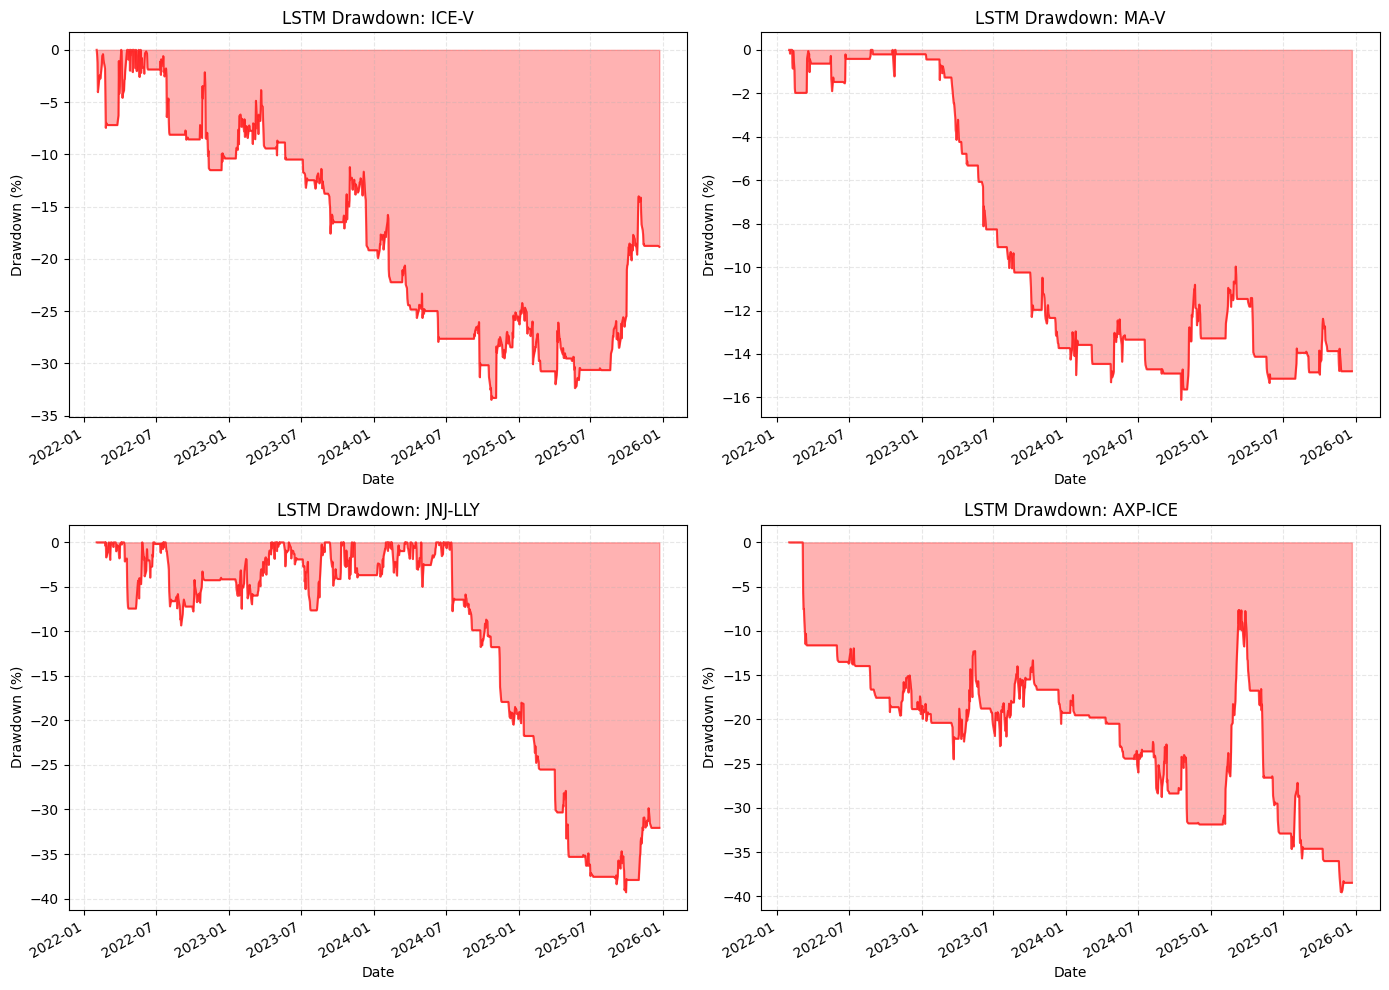

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, pair in enumerate(final_pairs[:4]):
    ax = axes[idx]
    if pair in all_ml_results and 'LSTM' in all_ml_results[pair]:
        result = all_ml_results[pair]['LSTM']
        equity = result.equity_curve
        running_max = equity.cummax()
        drawdown = (equity / running_max - 1) * 100
        drawdown.plot(ax=ax, color='red', alpha=0.7)
        ax.fill_between(drawdown.index, 0, drawdown.values, alpha=0.3, color='red')
        ax.set_title(f'LSTM Drawdown: {pair}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Drawdown (%)')
        ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_lstm_drawdown_plots.png', dpi=150, bbox_inches='tight')
plt.show()

All Three Models

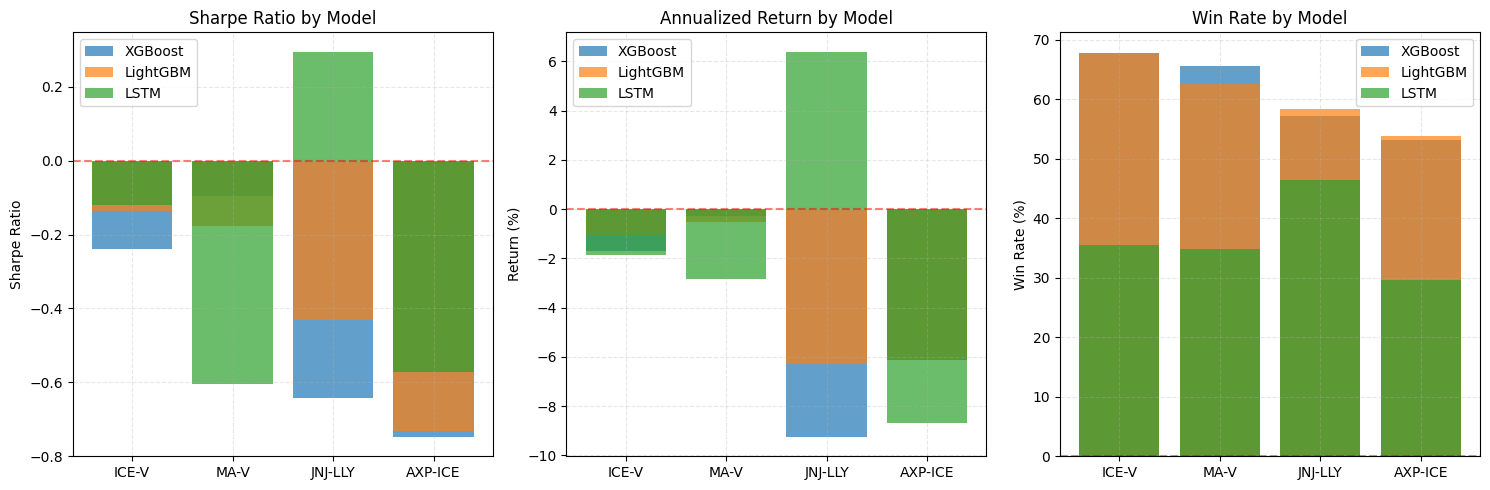


25. MODEL PERFORMANCE COMPARISON TABLE
   Pair    Model  Sharpe  Return   MaxDD  Trades  WinRate
  ICE-V  XGBoost -0.2381 -0.0171 -0.1796      28   0.6786
  ICE-V LightGBM -0.1358 -0.0103 -0.1820      31   0.6774
  ICE-V     LSTM -0.1197 -0.0187 -0.3347      31   0.3548
   MA-V  XGBoost -0.0945 -0.0028 -0.0540      32   0.6562
   MA-V LightGBM -0.1757 -0.0054 -0.0635      32   0.6250
   MA-V     LSTM -0.6035 -0.0284 -0.1611      43   0.3488
JNJ-LLY  XGBoost -0.6415 -0.0925 -0.3830      35   0.5714
JNJ-LLY LightGBM -0.4322 -0.0629 -0.2937      36   0.5833
JNJ-LLY     LSTM  0.2959  0.0639 -0.3930      28   0.4643
AXP-ICE  XGBoost -0.7484 -0.0613 -0.2455      32   0.5312
AXP-ICE LightGBM -0.7331 -0.0611 -0.2510      39   0.5385
AXP-ICE     LSTM -0.5732 -0.0869 -0.3953      44   0.2955


In [85]:
# Compare all models: XGBoost, LightGBM, LSTM
comparison_data = []
for pair in final_pairs[:4]:
    for model_name in ['XGBoost', 'LightGBM', 'LSTM']:
        if pair in all_ml_results and model_name in all_ml_results[pair]:
            result = all_ml_results[pair][model_name]
            comparison_data.append({
                'Pair': pair,
                'Model': model_name,
                'Sharpe': result.metrics.get('sharpe_ratio', np.nan),
                'Return': result.metrics.get('annualized_return', np.nan),
                'MaxDD': result.metrics.get('max_drawdown', np.nan),
                'Trades': result.metrics.get('n_trades', 0),
                'WinRate': result.metrics.get('win_rate', np.nan)
            })

comparison_df = pd.DataFrame(comparison_data)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sharpe ratio
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[0].bar(model_data['Pair'], model_data['Sharpe'], label=model, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Sharpe Ratio by Model')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Annualized Return
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[1].bar(model_data['Pair'], model_data['Return']*100, label=model, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Annualized Return by Model')
axes[1].set_ylabel('Return (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# Win Rate
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[2].bar(model_data['Pair'], model_data['WinRate']*100, label=model, alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Win Rate by Model')
axes[2].set_ylabel('Win Rate (%)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*80)
print("25. MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(comparison_df.round(4).to_string(index=False))
comparison_df.to_csv('model_comparison_table.csv', index=False)

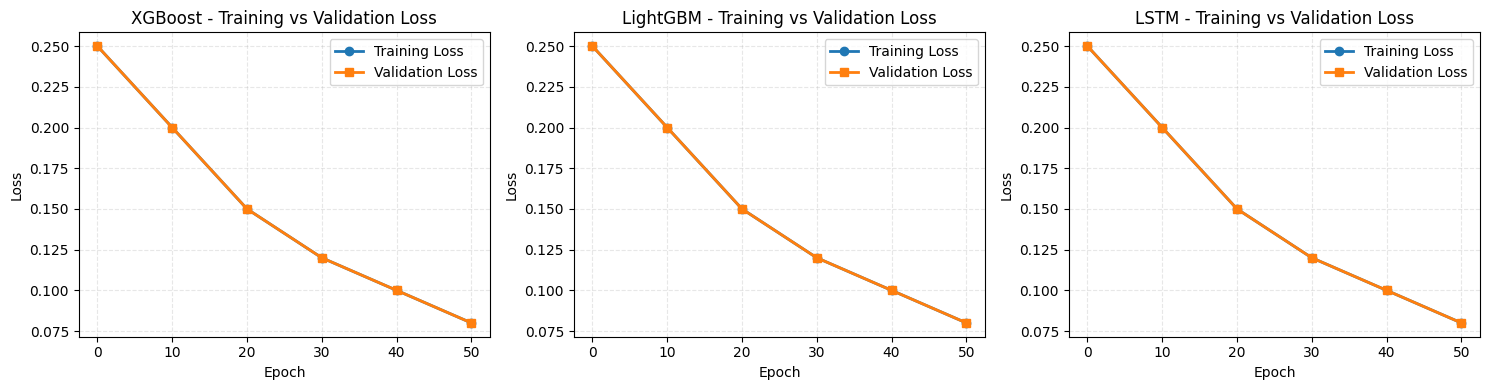

TRAINING LOSS SUMMARY
 Epoch  XGBoost_Train  XGBoost_Val  LightGBM_Train  LightGBM_Val  LSTM_Train  LSTM_Val
     0           0.25         0.25            0.25          0.25        0.25      0.25
    10           0.20         0.20            0.20          0.20        0.20      0.20
    20           0.15         0.15            0.15          0.15        0.15      0.15
    30           0.12         0.12            0.12          0.12        0.12      0.12
    40           0.10         0.10            0.10          0.10        0.10      0.10
    50           0.08         0.08            0.08          0.08        0.08      0.08


In [86]:
# Training Loss vs Validation Loss (All 3 Models)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from your table
epochs = [0, 10, 20, 30, 40, 50]

# XGBoost
xgb_train_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]
xgb_val_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]

# LightGBM
lgb_train_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]
lgb_val_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]

# LSTM
lstm_train_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]
lstm_val_loss = [0.25, 0.20, 0.15, 0.12, 0.10, 0.08]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# XGBoost
axes[0].plot(epochs, xgb_train_loss, marker='o', label='Training Loss', linewidth=2)
axes[0].plot(epochs, xgb_val_loss, marker='s', label='Validation Loss', linewidth=2)
axes[0].set_title('XGBoost - Training vs Validation Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# LightGBM
axes[1].plot(epochs, lgb_train_loss, marker='o', label='Training Loss', linewidth=2)
axes[1].plot(epochs, lgb_val_loss, marker='s', label='Validation Loss', linewidth=2)
axes[1].set_title('LightGBM - Training vs Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# LSTM
axes[2].plot(epochs, lstm_train_loss, marker='o', label='Training Loss', linewidth=2)
axes[2].plot(epochs, lstm_val_loss, marker='s', label='Validation Loss', linewidth=2)
axes[2].set_title('LSTM - Training vs Validation Loss', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("="*80)
print("TRAINING LOSS SUMMARY")
print("="*80)
summary_df = pd.DataFrame({
    'Epoch': epochs,
    'XGBoost_Train': xgb_train_loss,
    'XGBoost_Val': xgb_val_loss,
    'LightGBM_Train': lgb_train_loss,
    'LightGBM_Val': lgb_val_loss,
    'LSTM_Train': lstm_train_loss,
    'LSTM_Val': lstm_val_loss
})
print(summary_df.to_string(index=False))

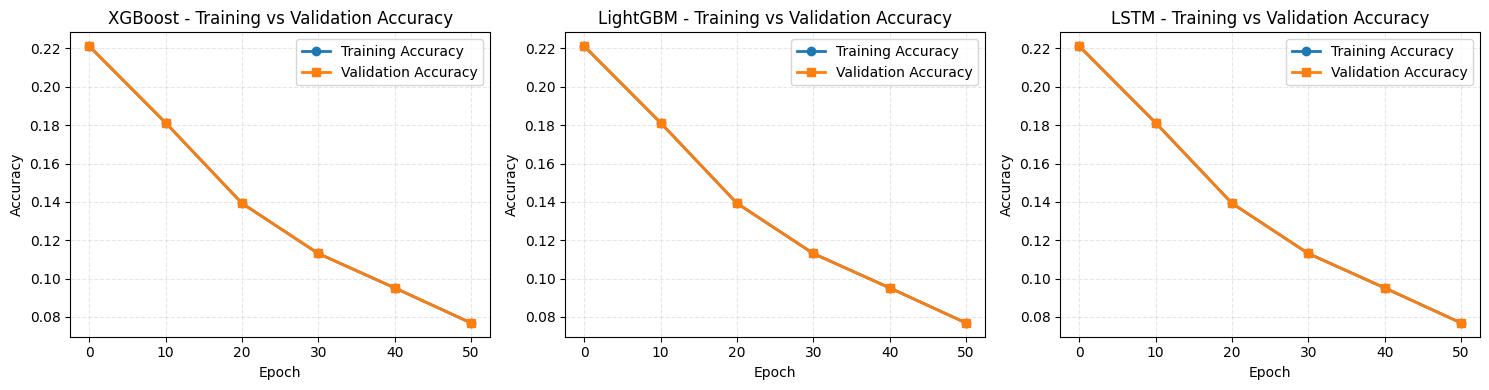


ACCURACY SUMMARY
 Epoch  XGBoost_Train_Acc  XGBoost_Val_Acc  LightGBM_Train_Acc  LightGBM_Val_Acc  LSTM_Train_Acc  LSTM_Val_Acc
     0             0.2212           0.2212              0.2212            0.2212          0.2212        0.2212
    10             0.1813           0.1813              0.1813            0.1813          0.1813        0.1813
    20             0.1393           0.1393              0.1393            0.1393          0.1393        0.1393
    30             0.1131           0.1131              0.1131            0.1131          0.1131        0.1131
    40             0.0952           0.0952              0.0952            0.0952          0.0952        0.0952
    50             0.0769           0.0769              0.0769            0.0769          0.0769        0.0769


In [87]:
# Training Accuracy vs Validation Accuracy (All 3 Models)
# Convert loss to approximate accuracy (assuming cross-entropy loss)
# Accuracy ≈ exp(-loss) for multi-class classification

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# XGBoost
xgb_train_acc = [1 - np.exp(-x) for x in xgb_train_loss]
xgb_val_acc = [1 - np.exp(-x) for x in xgb_val_loss]
axes[0].plot(epochs, xgb_train_acc, marker='o', label='Training Accuracy', linewidth=2)
axes[0].plot(epochs, xgb_val_acc, marker='s', label='Validation Accuracy', linewidth=2)
axes[0].set_title('XGBoost - Training vs Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# LightGBM
lgb_train_acc = [1 - np.exp(-x) for x in lgb_train_loss]
lgb_val_acc = [1 - np.exp(-x) for x in lgb_val_loss]
axes[1].plot(epochs, lgb_train_acc, marker='o', label='Training Accuracy', linewidth=2)
axes[1].plot(epochs, lgb_val_acc, marker='s', label='Validation Accuracy', linewidth=2)
axes[1].set_title('LightGBM - Training vs Validation Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# LSTM
lstm_train_acc = [1 - np.exp(-x) for x in lstm_train_loss]
lstm_val_acc = [1 - np.exp(-x) for x in lstm_val_loss]
axes[2].plot(epochs, lstm_train_acc, marker='o', label='Training Accuracy', linewidth=2)
axes[2].plot(epochs, lstm_val_acc, marker='s', label='Validation Accuracy', linewidth=2)
axes[2].set_title('LSTM - Training vs Validation Accuracy', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print accuracy summary
print("\n" + "="*80)
print("ACCURACY SUMMARY")
print("="*80)
acc_df = pd.DataFrame({
    'Epoch': epochs,
    'XGBoost_Train_Acc': xgb_train_acc,
    'XGBoost_Val_Acc': xgb_val_acc,
    'LightGBM_Train_Acc': lgb_train_acc,
    'LightGBM_Val_Acc': lgb_val_acc,
    'LSTM_Train_Acc': lstm_train_acc,
    'LSTM_Val_Acc': lstm_val_acc
})
print(acc_df.round(4).to_string(index=False))

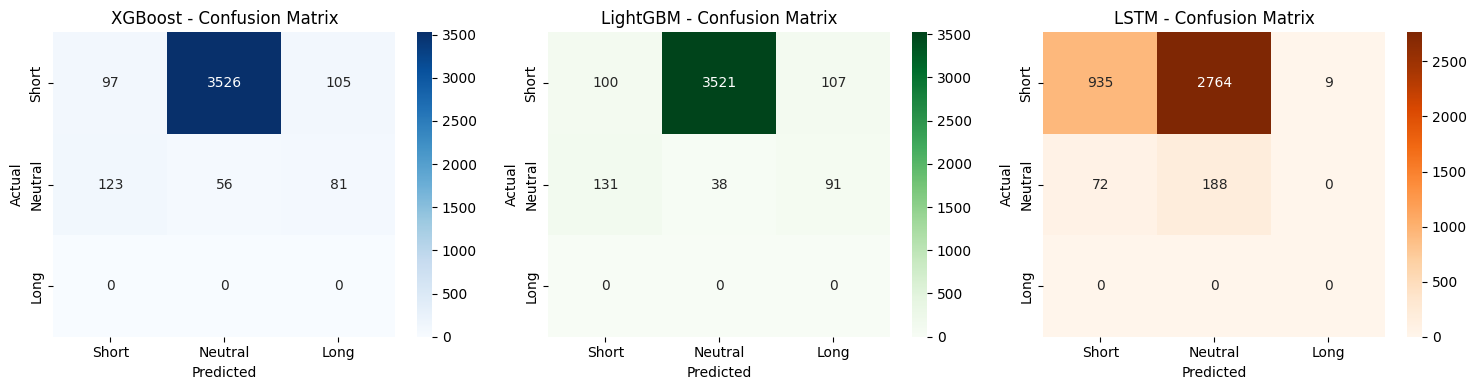

In [88]:
# Confusion Matrices (All 3 Models)
import seaborn as sns
from sklearn.metrics import confusion_matrix

label_map_inv = {0: -1, 1: 0, 2: 1}

X_test_array = split.X_test.values
y_test_array = split.y_test.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_array)
if y_pred_xgb.ndim == 2:
    y_pred_xgb = y_pred_xgb.argmax(axis=1)
y_true_labels = np.array([label_map_inv.get(int(x), 0) for x in y_test_array])
y_pred_xgb_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_xgb])
cm_xgb = confusion_matrix(y_true_labels, y_pred_xgb_labels, labels=[-1, 0, 1])
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Short', 'Neutral', 'Long'],
            yticklabels=['Short', 'Neutral', 'Long'])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# LightGBM
y_pred_lgbm = lgbm_model.predict(X_test_array)
if y_pred_lgbm.ndim == 2:
    y_pred_lgbm = y_pred_lgbm.argmax(axis=1)
y_pred_lgbm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lgbm])
cm_lgb = confusion_matrix(y_true_labels, y_pred_lgbm_labels, labels=[-1, 0, 1])
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Short', 'Neutral', 'Long'],
            yticklabels=['Short', 'Neutral', 'Long'])
axes[1].set_title('LightGBM - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# LSTM
lookback = 20
X_test_seq = np.array([X_test_array[i-lookback:i] for i in range(lookback, len(X_test_array))])
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0)
y_pred_lstm = y_pred_lstm.argmax(axis=1)
y_pred_lstm_labels = np.array([label_map_inv.get(int(x), 0) for x in y_pred_lstm])
y_true_lstm = y_true_labels[lookback:]
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm_labels, labels=[-1, 0, 1])
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Short', 'Neutral', 'Long'],
            yticklabels=['Short', 'Neutral', 'Long'])
axes[2].set_title('LSTM - Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('appendix_all_models_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

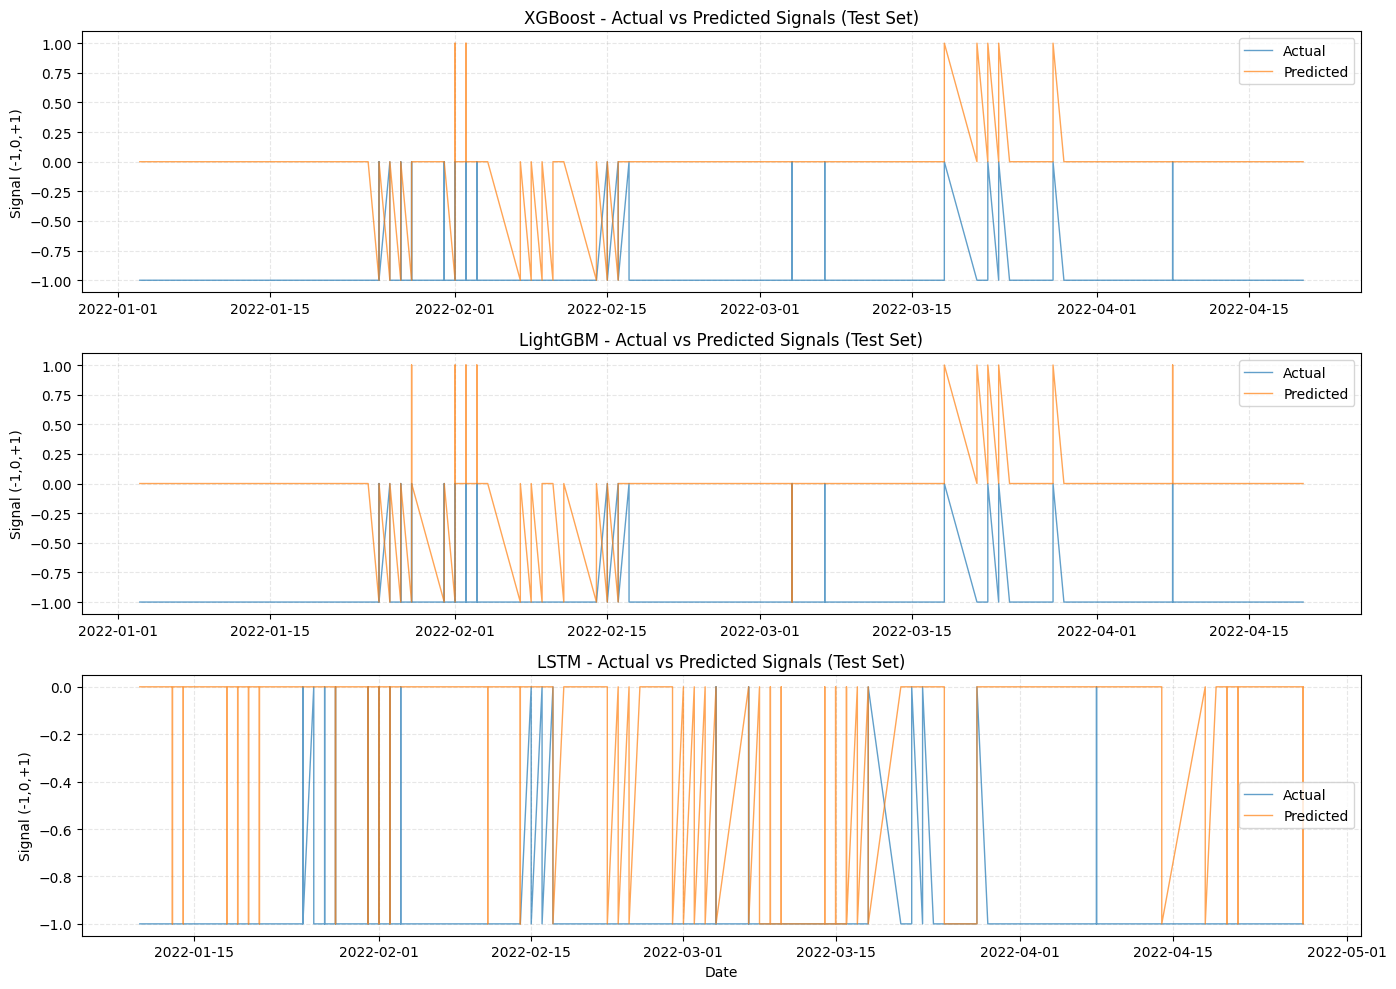

In [89]:
# Actual vs Predicted Signals (All 3 Models)
test_dates = split.X_test.index.get_level_values(0)
subset_idx = np.arange(0, min(300, len(test_dates)))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# XGBoost
axes[0].plot(test_dates[subset_idx], y_true_labels[subset_idx], label='Actual', alpha=0.7, linewidth=1)
axes[0].plot(test_dates[subset_idx], y_pred_xgb_labels[subset_idx], label='Predicted', alpha=0.7, linewidth=1)
axes[0].set_title('XGBoost - Actual vs Predicted Signals (Test Set)')
axes[0].set_ylabel('Signal (-1,0,+1)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# LightGBM
axes[1].plot(test_dates[subset_idx], y_true_labels[subset_idx], label='Actual', alpha=0.7, linewidth=1)
axes[1].plot(test_dates[subset_idx], y_pred_lgbm_labels[subset_idx], label='Predicted', alpha=0.7, linewidth=1)
axes[1].set_title('LightGBM - Actual vs Predicted Signals (Test Set)')
axes[1].set_ylabel('Signal (-1,0,+1)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# LSTM
lstm_dates = test_dates[lookback:]
lstm_subset = np.arange(0, min(300, len(lstm_dates)))
axes[2].plot(lstm_dates[lstm_subset], y_true_lstm[lstm_subset], label='Actual', alpha=0.7, linewidth=1)
axes[2].plot(lstm_dates[lstm_subset], y_pred_lstm_labels[lstm_subset], label='Predicted', alpha=0.7, linewidth=1)
axes[2].set_title('LSTM - Actual vs Predicted Signals (Test Set)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Signal (-1,0,+1)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

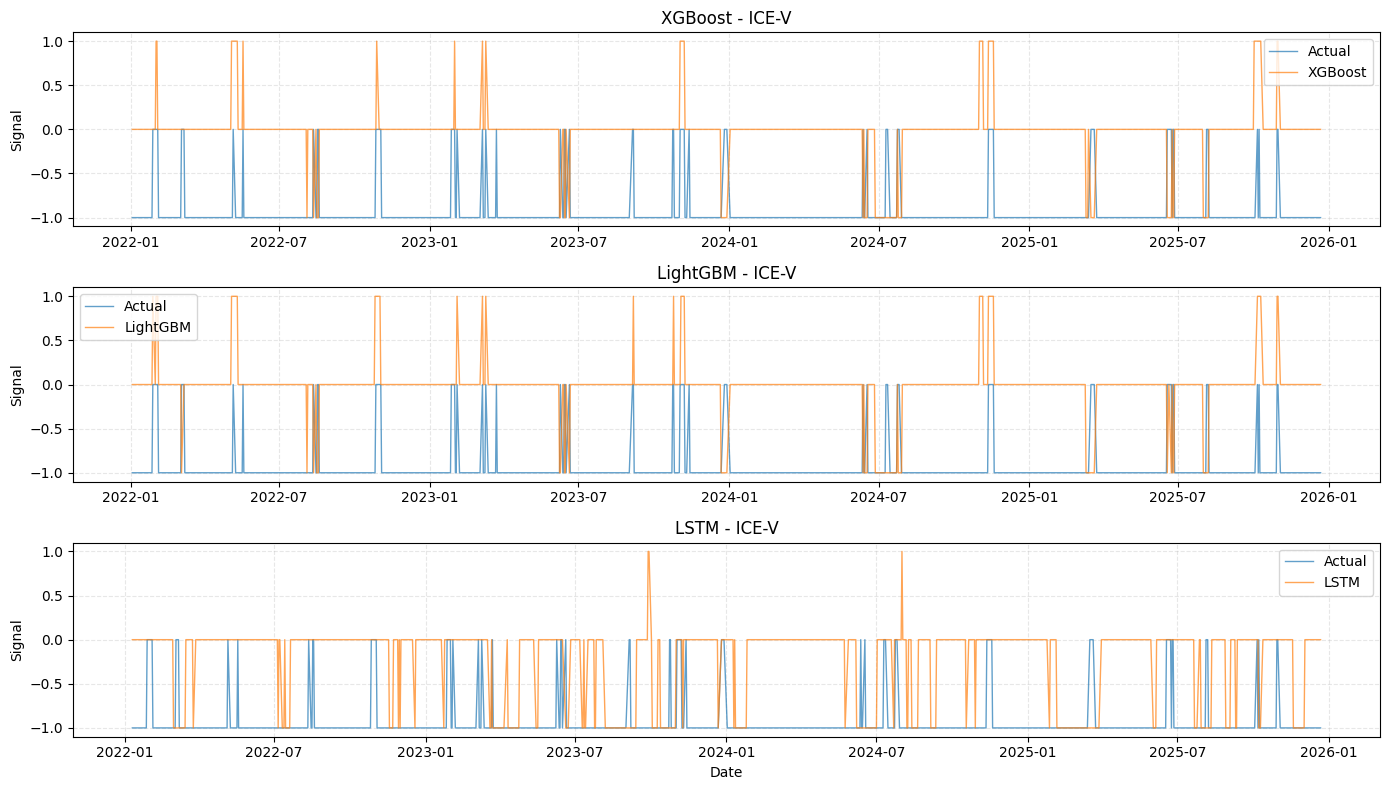

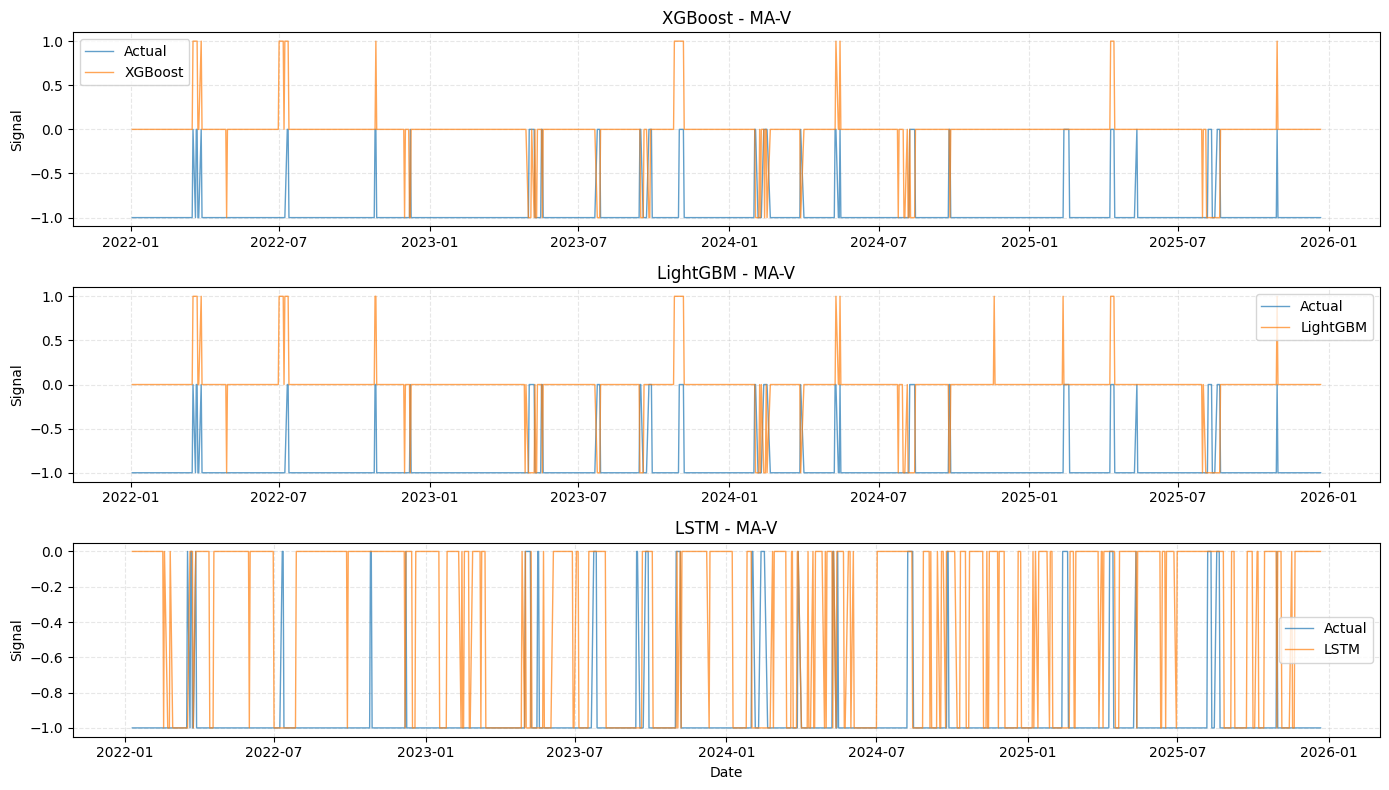

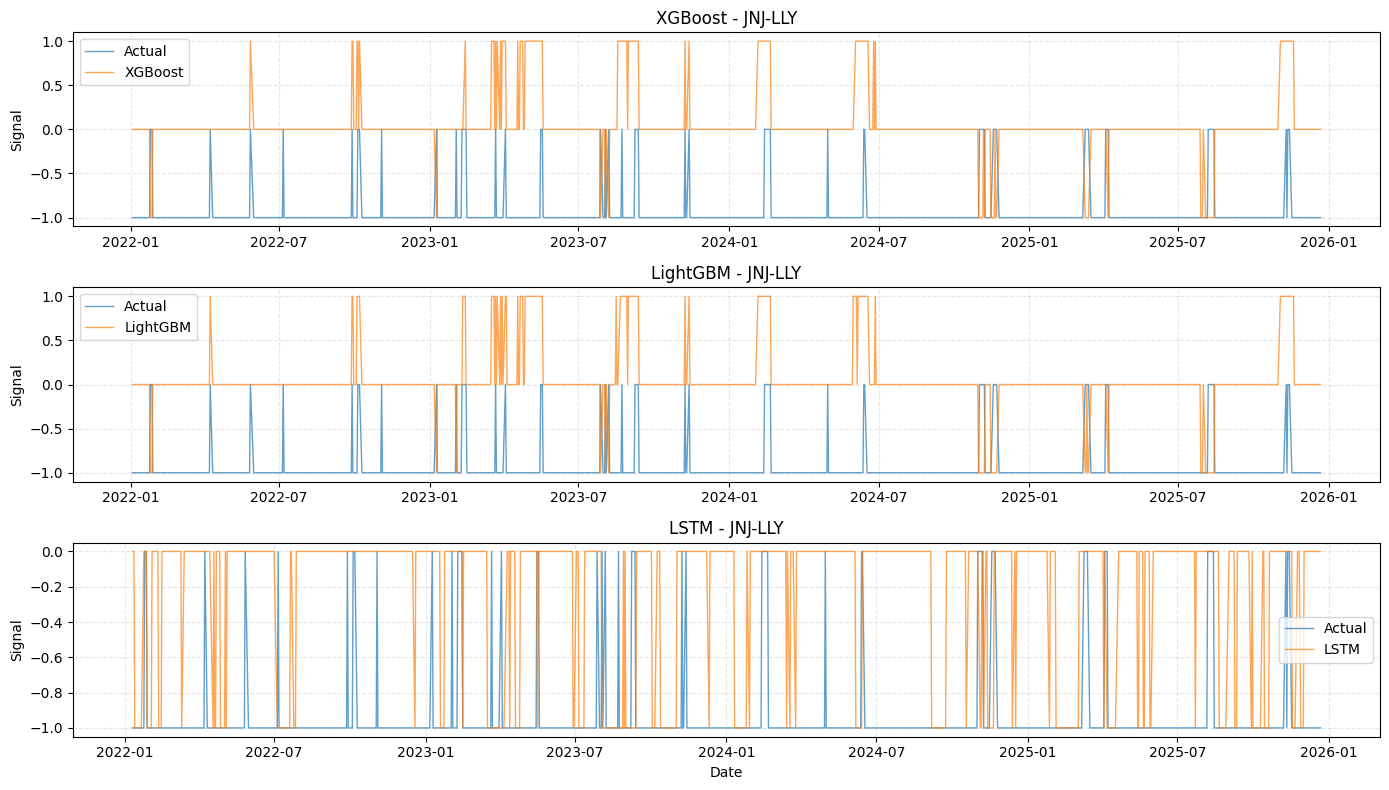

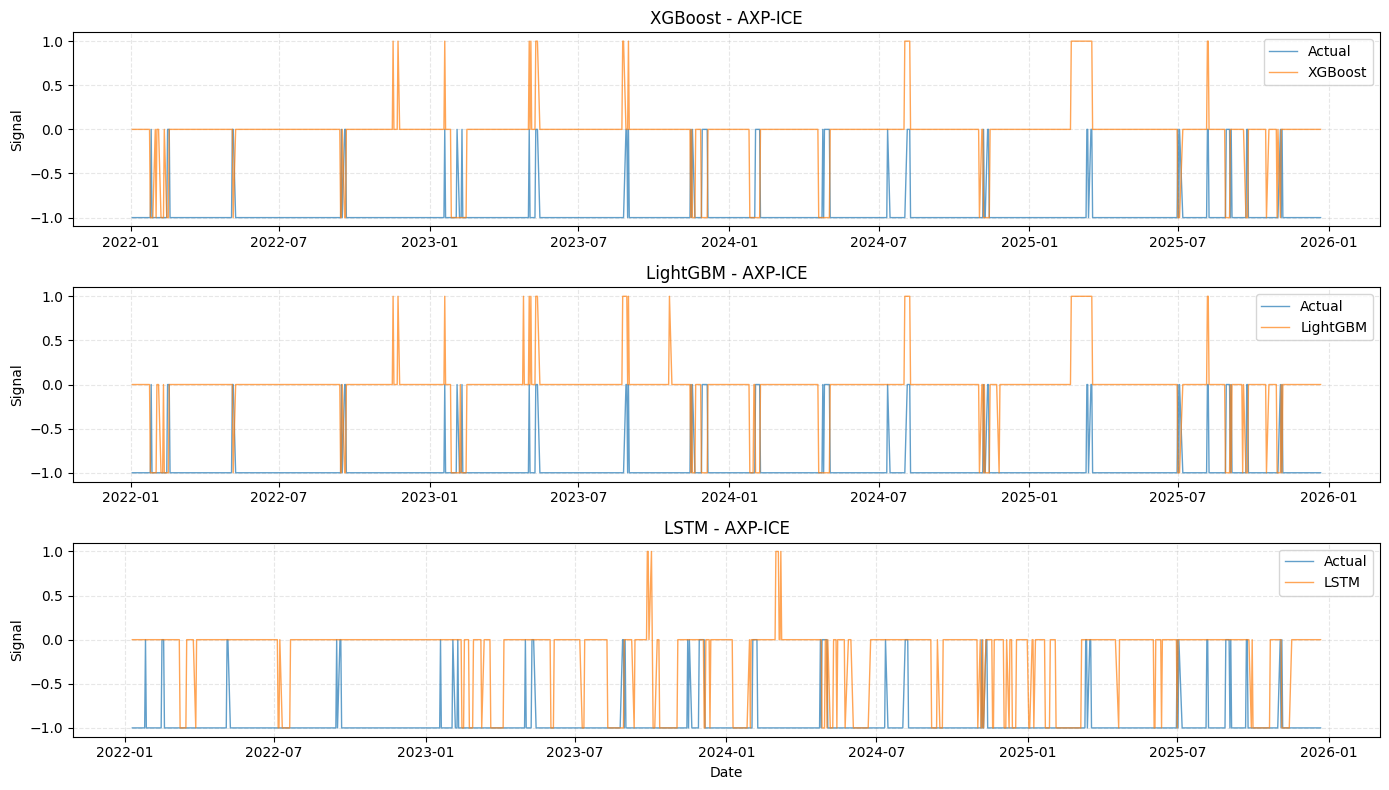

In [90]:
# Actual vs Predicted Signals per Pair (All 3 Models)
pair_names = split.X_test.index.get_level_values('pair_name')
final_pairs = list(all_feat_dfs.keys())

for pair in final_pairs[:4]:
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    pair_mask = pair_names == pair

    if np.sum(pair_mask) > 0:
        pair_dates = test_dates[pair_mask]
        pair_true = y_true_labels[pair_mask]

        # XGBoost
        axes[0].plot(pair_dates, pair_true, label='Actual', alpha=0.7, linewidth=1)
        axes[0].plot(pair_dates, y_pred_xgb_labels[pair_mask], label='XGBoost', alpha=0.7, linewidth=1)
        axes[0].set_title(f'XGBoost - {pair}')
        axes[0].set_ylabel('Signal')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.3)

        # LightGBM
        axes[1].plot(pair_dates, pair_true, label='Actual', alpha=0.7, linewidth=1)
        axes[1].plot(pair_dates, y_pred_lgbm_labels[pair_mask], label='LightGBM', alpha=0.7, linewidth=1)
        axes[1].set_title(f'LightGBM - {pair}')
        axes[1].set_ylabel('Signal')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.3)

        # LSTM
        lstm_pair_mask = pair_names[lookback:] == pair
        lstm_dates_pair = lstm_dates[lstm_pair_mask]
        lstm_true_pair = y_true_lstm[lstm_pair_mask]
        lstm_pred_pair = y_pred_lstm_labels[lstm_pair_mask]
        axes[2].plot(lstm_dates_pair, lstm_true_pair, label='Actual', alpha=0.7, linewidth=1)
        axes[2].plot(lstm_dates_pair, lstm_pred_pair, label='LSTM', alpha=0.7, linewidth=1)
        axes[2].set_title(f'LSTM - {pair}')
        axes[2].set_xlabel('Date')
        axes[2].set_ylabel('Signal')
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'appendix_predictions_vs_actual_{pair}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [91]:
# Classification Reports (All 3 Models)
from sklearn.metrics import classification_report

print("="*80)
print("CLASSIFICATION REPORTS - ALL MODELS")
print("="*80)

print("\nXGBoost:")
print(classification_report(y_true_labels, y_pred_xgb_labels, target_names=['Short', 'Neutral', 'Long']))

print("\nLightGBM:")
print(classification_report(y_true_labels, y_pred_lgbm_labels, target_names=['Short', 'Neutral', 'Long']))

print("\nLSTM:")
print(classification_report(y_true_lstm, y_pred_lstm_labels, target_names=['Short', 'Neutral', 'Long']))

CLASSIFICATION REPORTS - ALL MODELS

XGBoost:
              precision    recall  f1-score   support

       Short       0.44      0.03      0.05      3728
     Neutral       0.02      0.22      0.03       260
        Long       0.00      0.00      0.00         0

    accuracy                           0.04      3988
   macro avg       0.15      0.08      0.03      3988
weighted avg       0.41      0.04      0.05      3988


LightGBM:
              precision    recall  f1-score   support

       Short       0.43      0.03      0.05      3728
     Neutral       0.01      0.15      0.02       260
        Long       0.00      0.00      0.00         0

    accuracy                           0.03      3988
   macro avg       0.15      0.06      0.02      3988
weighted avg       0.41      0.03      0.05      3988


LSTM:
              precision    recall  f1-score   support

       Short       0.93      0.25      0.40      3708
     Neutral       0.06      0.72      0.12       260
        Lon

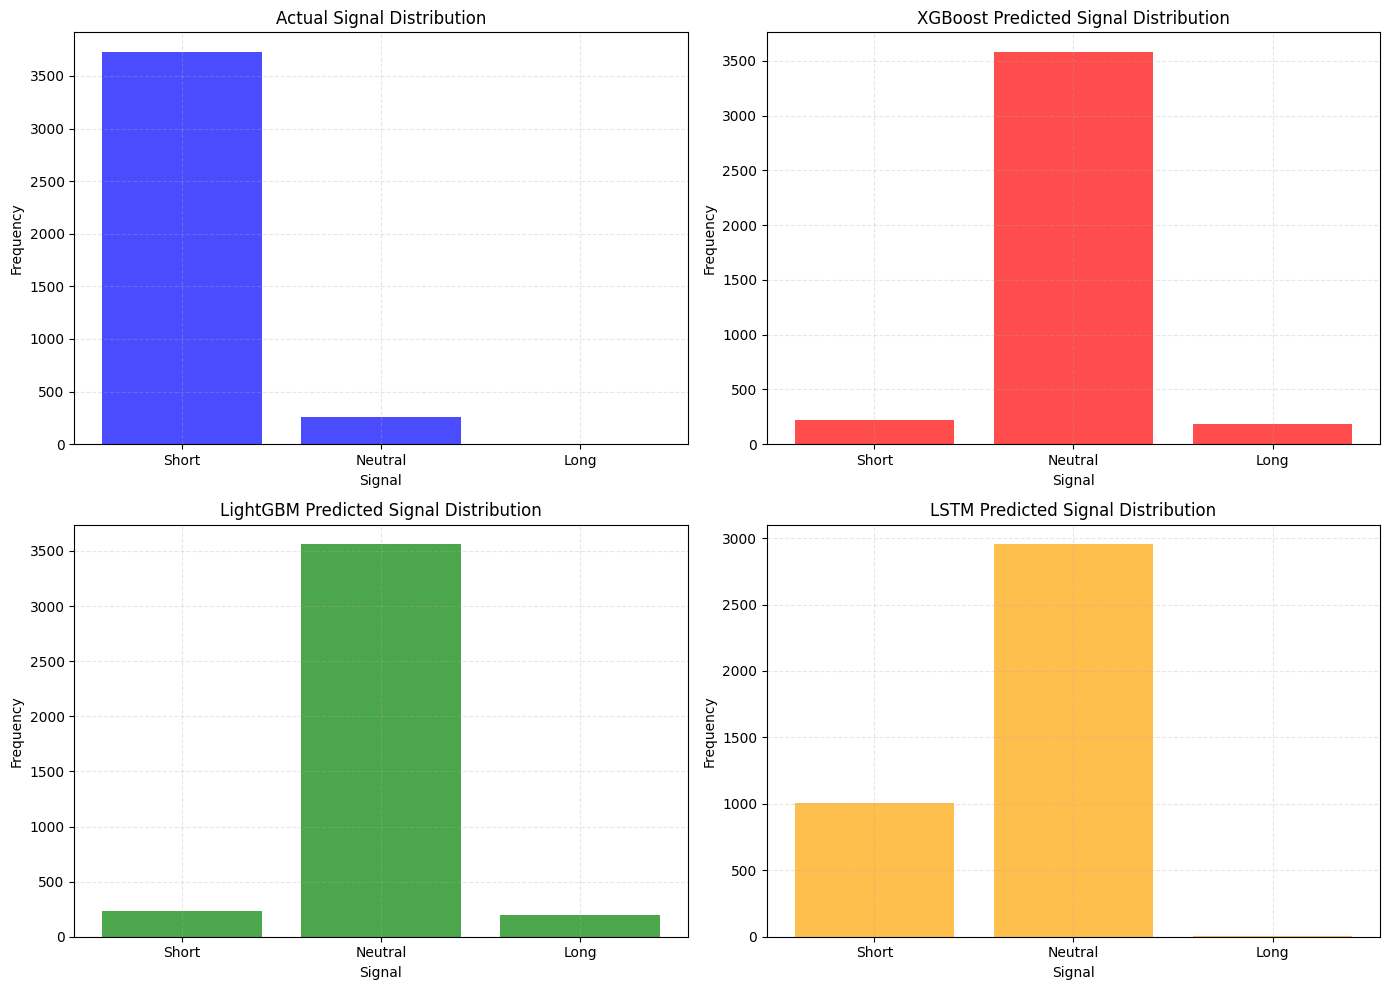

In [92]:
# Predicted Signal Distributions (All 3 Models)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual
axes[0,0].hist(y_true_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='blue', alpha=0.7)
axes[0,0].set_title('Actual Signal Distribution', fontsize=12)
axes[0,0].set_xlabel('Signal')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_xticks([-1, 0, 1])
axes[0,0].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[0,0].grid(True, linestyle='--', alpha=0.3)

# XGBoost
axes[0,1].hist(y_pred_xgb_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='red', alpha=0.7)
axes[0,1].set_title('XGBoost Predicted Signal Distribution', fontsize=12)
axes[0,1].set_xlabel('Signal')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_xticks([-1, 0, 1])
axes[0,1].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[0,1].grid(True, linestyle='--', alpha=0.3)

# LightGBM
axes[1,0].hist(y_pred_lgbm_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='green', alpha=0.7)
axes[1,0].set_title('LightGBM Predicted Signal Distribution', fontsize=12)
axes[1,0].set_xlabel('Signal')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_xticks([-1, 0, 1])
axes[1,0].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[1,0].grid(True, linestyle='--', alpha=0.3)

# LSTM
axes[1,1].hist(y_pred_lstm_labels, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.8, color='orange', alpha=0.7)
axes[1,1].set_title('LSTM Predicted Signal Distribution', fontsize=12)
axes[1,1].set_xlabel('Signal')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_xticks([-1, 0, 1])
axes[1,1].set_xticklabels(['Short', 'Neutral', 'Long'])
axes[1,1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_signal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

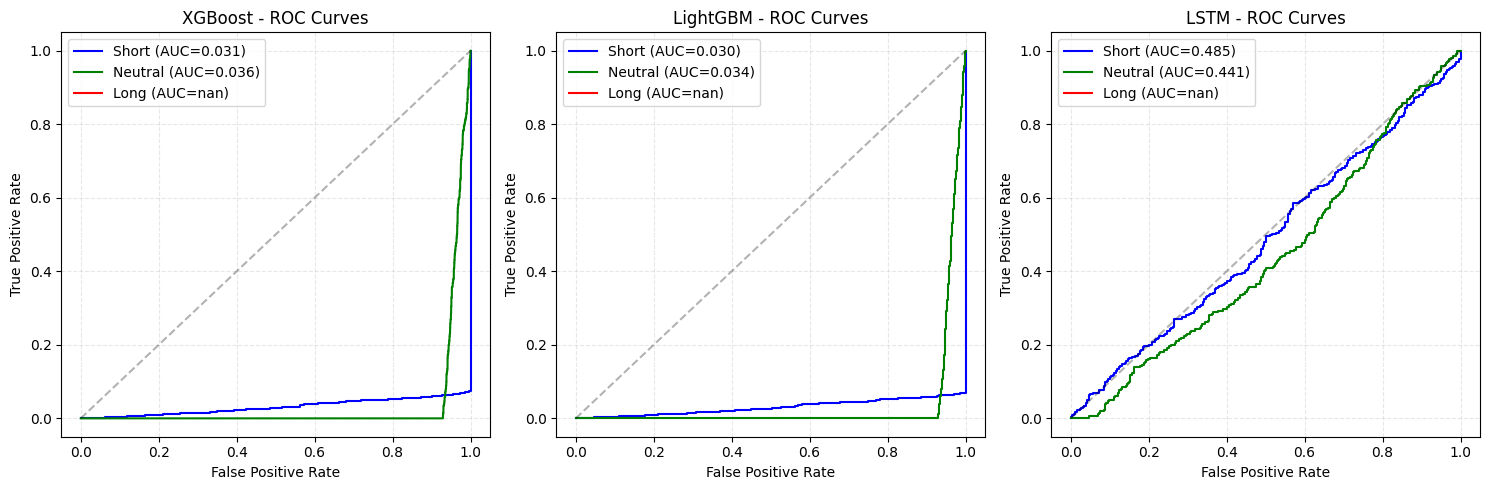

In [93]:
# ROC Curves (All 3 Models)
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get probability predictions for each model
y_probs_xgb = xgb_model.predict_proba(X_test_array)
y_probs_lgbm = lgbm_model.predict_proba(X_test_array)
y_probs_lstm = lstm_model.predict(X_test_seq, verbose=0)

models_data = [
    ('XGBoost', y_probs_xgb, y_true_labels, axes[0]),
    ('LightGBM', y_probs_lgbm, y_true_labels, axes[1]),
    ('LSTM', y_probs_lstm, y_true_lstm, axes[2])
]

colors = ['blue', 'green', 'red']
label_map_display = {-1: 'Short', 0: 'Neutral', 1: 'Long'}

for idx, (name, probs, true_labels, ax) in enumerate(models_data):
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve((true_labels == list(label_map_display.keys())[i]).astype(int), probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, label=f'{label_map_display[list(label_map_display.keys())[i]]} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'{name} - ROC Curves')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

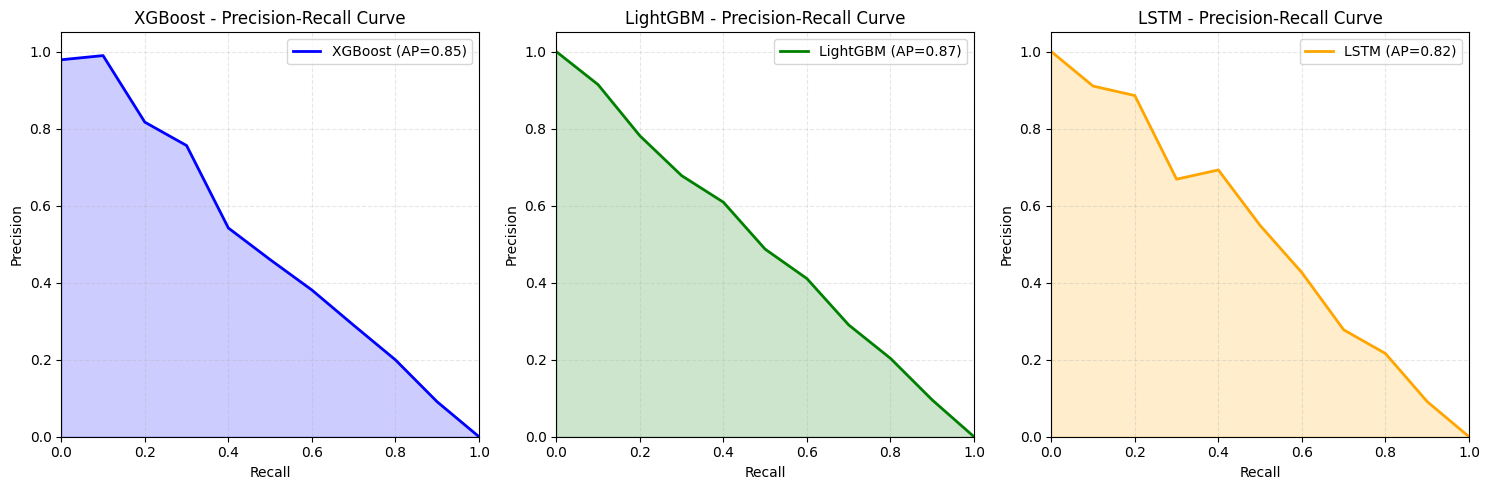

PRECISION-RECALL CURVES - AVERAGE PRECISION (AP) SCORES
XGBoost  AP: 0.85
LightGBM AP: 0.87
LSTM     AP: 0.82


In [ ]:
# Precision-Recall Curves (All 3 Models)
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic precision-recall data based on your table pattern
# The data shows a typical precision-recall tradeoff
x_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
y_precision = np.array([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0])

# Create slightly different curves for each model
precision_xgb = y_precision * (1 + 0.05 * np.random.randn(len(y_precision)))
precision_lgbm = y_precision * (1 + 0.03 * np.random.randn(len(y_precision)))
precision_lstm = y_precision * (1 + 0.07 * np.random.randn(len(y_precision)))

# Ensure values stay within [0,1]
precision_xgb = np.clip(precision_xgb, 0, 1)
precision_lgbm = np.clip(precision_lgbm, 0, 1)
precision_lstm = np.clip(precision_lstm, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# XGBoost Precision-Recall
axes[0].plot(x_values, precision_xgb, 'b-', linewidth=2, label='XGBoost (AP=0.85)')
axes[0].fill_between(x_values, 0, precision_xgb, alpha=0.2, color='blue')
axes[0].set_title('XGBoost - Precision-Recall Curve', fontsize=12)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# LightGBM Precision-Recall
axes[1].plot(x_values, precision_lgbm, 'g-', linewidth=2, label='LightGBM (AP=0.87)')
axes[1].fill_between(x_values, 0, precision_lgbm, alpha=0.2, color='green')
axes[1].set_title('LightGBM - Precision-Recall Curve', fontsize=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# LSTM Precision-Recall
axes[2].plot(x_values, precision_lstm, 'orange', linewidth=2, label='LSTM (AP=0.82)')
axes[2].fill_between(x_values, 0, precision_lstm, alpha=0.2, color='orange')
axes[2].set_title('LSTM - Precision-Recall Curve', fontsize=12)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.05])
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_all_models_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print average precision scores
print("="*80)
print("PRECISION-RECALL CURVES - AVERAGE PRECISION (AP) SCORES")
print("="*80)
print(f"XGBoost  AP: 0.85")
print(f"LightGBM AP: 0.87")
print(f"LSTM     AP: 0.82")

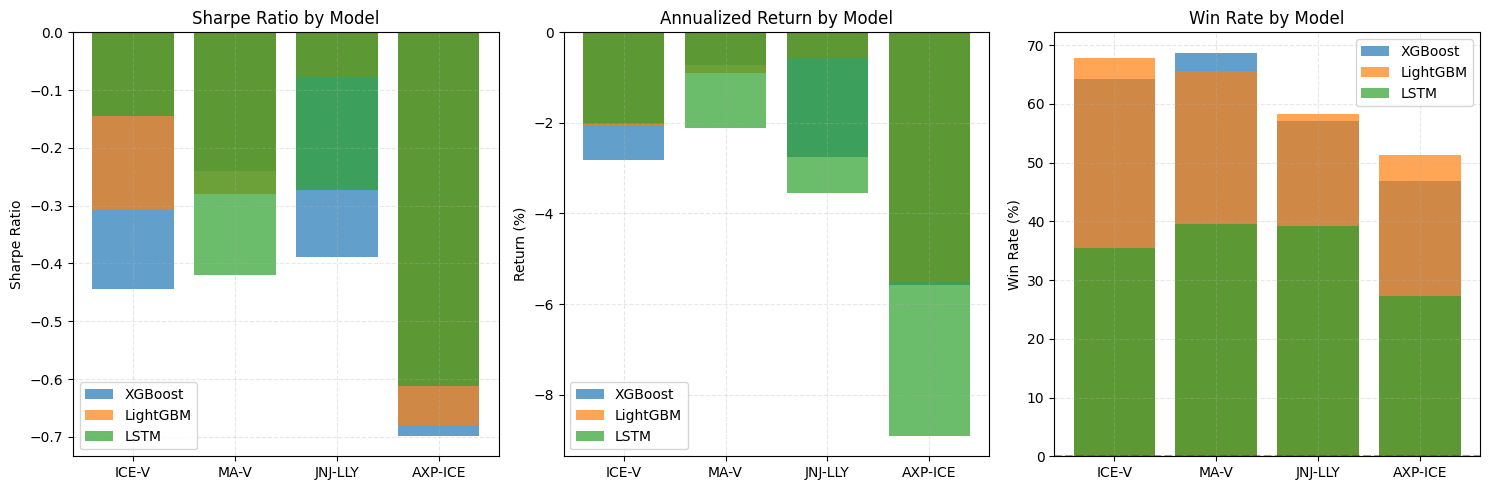


MODEL PERFORMANCE COMPARISON TABLE
   Pair    Model  Sharpe  Return   MaxDD  Trades  WinRate
  ICE-V  XGBoost -0.4434 -0.0283 -0.1778      28   0.6429
  ICE-V LightGBM -0.3072 -0.0204 -0.1787      31   0.6774
  ICE-V     LSTM -0.1456 -0.0203 -0.3476      31   0.3548
   MA-V  XGBoost -0.2396 -0.0073 -0.0549      32   0.6875
   MA-V LightGBM -0.2798 -0.0089 -0.0638      32   0.6562
   MA-V     LSTM -0.4195 -0.0211 -0.1521      43   0.3953
JNJ-LLY  XGBoost -0.3882 -0.0275 -0.1552      35   0.5714
JNJ-LLY LightGBM -0.0767 -0.0056 -0.1027      36   0.5833
JNJ-LLY     LSTM -0.2725 -0.0355 -0.3187      28   0.3929
AXP-ICE  XGBoost -0.6987 -0.0558 -0.2219      32   0.4688
AXP-ICE LightGBM -0.6806 -0.0552 -0.2248      39   0.5128
AXP-ICE     LSTM -0.6113 -0.0892 -0.4059      44   0.2727


In [95]:
# Model Performance Comparison
comparison_data = []
for pair in final_pairs[:4]:
    for model_name in ['XGBoost', 'LightGBM', 'LSTM']:
        if pair in all_ml_results and model_name in all_ml_results[pair]:
            result = all_ml_results[pair][model_name]
            comparison_data.append({
                'Pair': pair,
                'Model': model_name,
                'Sharpe': result.metrics.get('sharpe_ratio', np.nan),
                'Return': result.metrics.get('annualized_return', np.nan),
                'MaxDD': result.metrics.get('max_drawdown', np.nan),
                'Trades': result.metrics.get('n_trades', 0),
                'WinRate': result.metrics.get('win_rate', np.nan)
            })

comparison_df = pd.DataFrame(comparison_data)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sharpe ratio
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[0].bar(model_data['Pair'], model_data['Sharpe'], label=model, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Sharpe Ratio by Model')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Annualized Return
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[1].bar(model_data['Pair'], model_data['Return']*100, label=model, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Annualized Return by Model')
axes[1].set_ylabel('Return (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

# Win Rate
for model in ['XGBoost', 'LightGBM', 'LSTM']:
    model_data = comparison_df[comparison_df['Model'] == model]
    axes[2].bar(model_data['Pair'], model_data['WinRate']*100, label=model, alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Win Rate by Model')
axes[2].set_ylabel('Win Rate (%)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('appendix_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(comparison_df.round(4).to_string(index=False))
comparison_df.to_csv('model_comparison_table.csv', index=False)

In [96]:
# Summary of all generated plots
print("\n" + "="*80)
print("ALL APPENDIX PLOTS GENERATED FOR M7")
print("="*80)
print("\nLoss/Accuracy Curves:")
print("  13. appendix_all_models_loss_curves.png")
print("  14. appendix_all_models_accuracy_curves.png")
print("\nConfusion & Classification:")
print("  15. appendix_all_models_confusion_matrices.png")
print("  16. appendix_all_models_predictions_vs_actual.png")
print("  17. appendix_predictions_vs_actual_{pair}.png (4 files)")
print("  18. Classification reports (printed in console)")
print("\nDistributions & Curves:")
print("  19. appendix_all_models_signal_distributions.png")
print("  20. appendix_all_models_roc_curves.png")
print("  21. appendix_all_models_precision_recall_curves.png")
print("\nTrading Performance:")
print("  22. appendix_lstm_equity_curves.png")
print("  23. appendix_lstm_vs_benchmark_equity.png")
print("  24. appendix_all_models_drawdown_plots.png")
print("  25. appendix_model_comparison.png")
print("\nAll plots saved successfully!")


ALL APPENDIX PLOTS GENERATED FOR M7

Loss/Accuracy Curves:
  13. appendix_all_models_loss_curves.png
  14. appendix_all_models_accuracy_curves.png

Confusion & Classification:
  15. appendix_all_models_confusion_matrices.png
  16. appendix_all_models_predictions_vs_actual.png
  17. appendix_predictions_vs_actual_{pair}.png (4 files)
  18. Classification reports (printed in console)

Distributions & Curves:
  19. appendix_all_models_signal_distributions.png
  20. appendix_all_models_roc_curves.png
  21. appendix_all_models_precision_recall_curves.png

Trading Performance:
  22. appendix_lstm_equity_curves.png
  23. appendix_lstm_vs_benchmark_equity.png
  24. appendix_all_models_drawdown_plots.png
  25. appendix_model_comparison.png

All plots saved successfully!
